# 02 Build aligned segment variables

This notebook reads the filtered segment table from `01_rebuild_graph_and_segments`, uses the exact GraphML recorded in the pipeline manifest, rebuilds graph and land-use caches under a new output root, and writes `segment_model_table.csv.gz`.

The key guard is the path-key and GraphML alignment check after variable construction. If `path_edge_keys` no longer match the GraphML, the notebook stops before modeling.


In [4]:
# =========================================================
# 0. Imports and controls
#    Python 3.8 compatible
# =========================================================
import ast
import json
import math
import os
import pickle
import re
from collections import Counter, OrderedDict, defaultdict
from pathlib import Path

import geopandas as gpd
import networkx as nx
import numpy as np
import pandas as pd
import pyproj
from shapely import wkt
from shapely.geometry import LineString, MultiLineString, Point, box
from shapely.ops import linemerge, unary_union
from shapely.strtree import STRtree
from tqdm import tqdm

try:
    import osmnx as ox
except Exception as exc:
    ox = None
    print("Warning: osmnx import failed:", exc)

# -------------------------
# Resume controls
# -------------------------
RESUME_FROM_EXISTING = False

# Keep expensive stages unless they are missing.
FORCE_REBUILD_RAW_EVENTS = True
FORCE_REBUILD_RIDER_FEATURES = True
FORCE_REBUILD_GRAPH_CORE = True
FORCE_REFRESH_ROAD_CLASS = True
FORCE_REBUILD_LANDUSE_FEATURES = True
FORCE_REBUILD_SEGMENT_FEATURES = True
FORCE_REBUILD_VIF = True

# Centrality controls. If previous centrality columns exist in cache, they are reused.
COMPUTE_BETWEENNESS_IF_MISSING = True
COMPUTE_CLOSENESS_IF_MISSING = True
# Rebuild graph core if you want to recompute approximate centrality from scratch.
BETWEENNESS_K = 300
BETWEENNESS_BATCH_SIZE = 20
FARNESS_SAMPLE_SOURCES = 200

# Output controls.
WRITE_CSV_COPY = True
WRITE_GPKG = True
WRITE_SHP = False

# Modeling controls.
# Land-use/POI buffers are intentionally smaller than the local road-network radius.
NETWORK_RADIUS_M = 300
LANDUSE_BUFFER_M = 30
SERVICE_TIME_DEDUCTION_SEC = 180
ADJUSTED_SPEED_COL = "speed_kmh_minus_service_time"
ADJUSTED_TRAVEL_TIME_COL = "travel_time_minus_service_sec"
OVERSPEED_THRESHOLD_KMH = 20.0
LONG_SEGMENT_THRESHOLD_M = 2000.0
TZ_SHIFT_HOURS = 8
RANDOM_SEED = 42

# VIF controls.
VIF_MAX_ROWS = 200000
VIF_MIN_NON_NULL_SHARE = 0.80
VIF_CORR_DROP_THRESHOLD = 0.995

np.random.seed(RANDOM_SEED)
os.environ.setdefault("SHAPE_RESTORE_SHX", "YES")


'YES'

In [5]:
# =========================================================
# 1. Paths
# =========================================================
try:
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    BASE_DIR = Path.cwd()

PIPELINE_ROOT = BASE_DIR / "outputs_pipeline_aligned"
MANIFEST_PATH = PIPELINE_ROOT / "pipeline_manifest.json"
PIPELINE_MANIFEST = json.loads(MANIFEST_PATH.read_text(encoding="utf-8")) if MANIFEST_PATH.exists() else {}
OUTPUT_ROOT = Path(PIPELINE_MANIFEST.get("variable_root", PIPELINE_ROOT / "02_variables"))
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

SEGMENT_CSV_CANDIDATES = [
    Path(PIPELINE_MANIFEST.get("filtered_segment_csv", PIPELINE_ROOT / "01_raw_segments" / "courier_final_distances_filtered.csv")),
]
GRAPHML_CANDIDATES = [
    Path(PIPELINE_MANIFEST.get("graph_file", PIPELINE_ROOT / "00_graph" / "baoding_aligned.graphml")),
]

WAYBILL_CSV = BASE_DIR / "dataset" / "all_waybill_info.csv"
WAVE_CSV = BASE_DIR / "dataset" / "courier_wave_info.csv"

# POI candidates. Add your own POI table here if the auto search misses it.
POI_INPUT_CANDIDATES = [
    Path(PIPELINE_MANIFEST.get("poi_input")) if PIPELINE_MANIFEST.get("poi_input") else BASE_DIR / "__missing_poi__.shp",
    BASE_DIR / "baoding" / "保定数据" / "POI_保定.shp",
    BASE_DIR / "POI_保定.shp",
    BASE_DIR / "poi.shp",
    BASE_DIR / "poi.csv",
]
REST_INPUT_CANDIDATES = [
    Path(PIPELINE_MANIFEST.get("restaurant_input")) if PIPELINE_MANIFEST.get("restaurant_input") else BASE_DIR / "__missing_rest__.shp",
    BASE_DIR / "baoding" / "保定数据" / "大众点评餐馆_保定.shp",
    BASE_DIR / "大众点评餐馆_保定.shp",
    BASE_DIR / "restaurant.shp",
    BASE_DIR / "restaurants.csv",
]

RAW_EVENT_STATE_CSV = OUTPUT_ROOT / "rider" / "raw_event_state.csv.gz"
RIDER_FEATURE_CSV = OUTPUT_ROOT / "rider" / "rider_features.csv"

GRAPH_DIR = OUTPUT_ROOT / "graph"
GRAPH_DIR.mkdir(parents=True, exist_ok=True)
GRAPH_CORE_CACHE_PKL = GRAPH_DIR / "graph_core_cache.pkl"
GRAPH_FEATURE_PKL = GRAPH_DIR / "graph_feature_cache.pkl"       # backward compatible name
GRAPHML_DIAGNOSTIC_JSON = GRAPH_DIR / "graphml_attribute_diagnostics.json"
GRAPHML_ROAD_CLASS_CSV = GRAPH_DIR / "graphml_road_class_values.csv"
CONEDGE_FEATURE_CSV = GRAPH_DIR / "conedge_features.csv.gz"
CONEDGE_GPKG = GRAPH_DIR / "conedge_features.gpkg"

LANDUSE_DIR = OUTPUT_ROOT / "landuse"
LANDUSE_CONEDGE_CSV = LANDUSE_DIR / ("conedge_landuse_%dm.csv.gz" % LANDUSE_BUFFER_M)
POI_CATEGORY_CSV = LANDUSE_DIR / "poi_category_counts.csv"
POI_CATEGORY_SHP = LANDUSE_DIR / "poi_categories_clipped.shp"

SEGMENT_DIR = OUTPUT_ROOT / "segments"
SEGMENT_MODEL_CSV_GZ = SEGMENT_DIR / "segment_model_table.csv.gz"
SEGMENT_MODEL_CSV = SEGMENT_DIR / "segment_model_table.csv"
VARIABLE_DICTIONARY_CSV = SEGMENT_DIR / "variable_dictionary.csv"

VIF_CSV = OUTPUT_ROOT / "diagnostics" / "vif_table.csv"
PATH_INFO_JSON = OUTPUT_ROOT / "effective_paths.json"


def first_existing_path(candidates, label, required=True):
    for p in candidates:
        p = Path(p)
        if p.exists():
            return p
    if required:
        raise FileNotFoundError("No existing %s found. Checked: %s" % (label, [str(p) for p in candidates]))
    return Path(candidates[0])


def find_optional_file(candidates, keyword_patterns=None):
    for p in candidates:
        p = Path(p)
        if p.exists():
            return p
    if keyword_patterns is None:
        return None
    exts = {".shp", ".gpkg", ".geojson", ".csv", ".xlsx"}
    found = []
    for p in BASE_DIR.rglob("*"):
        if not p.is_file() or p.suffix.lower() not in exts:
            continue
        name = p.name.lower()
        for pat in keyword_patterns:
            if pat.lower() in name:
                found.append(p)
                break
    return found[0] if found else None

SEGMENT_CSV = first_existing_path(SEGMENT_CSV_CANDIDATES, "segment csv", required=True)
GRAPHML_PATH = first_existing_path(GRAPHML_CANDIDATES, "graphml", required=True)
POI_INPUT = find_optional_file(POI_INPUT_CANDIDATES, keyword_patterns=["poi", "兴趣", "保定"])
REST_INPUT = find_optional_file(REST_INPUT_CANDIDATES, keyword_patterns=["restaurant", "餐馆", "餐饮", "大众点评"])


def file_fingerprint(path):
    import hashlib
    path = Path(path)
    if not path.exists():
        return None
    h = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            b = f.read(1024 * 1024)
            if not b:
                break
            h.update(b)
    return {
        "path": str(path),
        "size_bytes": int(path.stat().st_size),
        "mtime": float(path.stat().st_mtime),
        "md5": h.hexdigest(),
    }

PATH_INFO = {
    "segment_csv": str(SEGMENT_CSV),
    "graphml_path": str(GRAPHML_PATH),
    "waybill_csv": str(WAYBILL_CSV),
    "wave_csv": str(WAVE_CSV),
    "poi_input": str(POI_INPUT) if POI_INPUT is not None else None,
    "restaurant_input": str(REST_INPUT) if REST_INPUT is not None else None,
    "output_root": str(OUTPUT_ROOT),
    "network_radius_m": NETWORK_RADIUS_M,
    "landuse_buffer_m": LANDUSE_BUFFER_M,
    "service_time_deduction_sec": SERVICE_TIME_DEDUCTION_SEC,
    "graph_fingerprint": file_fingerprint(GRAPHML_PATH),
    "segment_csv_fingerprint": file_fingerprint(SEGMENT_CSV),
}
PATH_INFO_JSON.parent.mkdir(parents=True, exist_ok=True)
PATH_INFO_JSON.write_text(json.dumps(PATH_INFO, indent=2, ensure_ascii=False), encoding="utf-8")
PATH_INFO


PermissionError: [WinError 5] 拒绝访问。: '\\Users\\kwk1001'

## 2. Utilities

These helpers provide atomic writes, file reuse checks, path parsing, geometry helpers, and VIF support.


In [ ]:
# =========================================================
# 2. Utilities
# =========================================================
def ensure_dir(path_like):
    Path(path_like).mkdir(parents=True, exist_ok=True)


def write_csv_atomic(df, path, index=False, compression=None):
    path = Path(path)
    ensure_dir(path.parent)
    tmp = path.with_suffix(path.suffix + ".tmp")
    df.to_csv(tmp, index=index, compression=compression)
    os.replace(str(tmp), str(path))
    print("[saved] %s rows=%s cols=%s" % (path, f"{len(df):,}", f"{df.shape[1]:,}"))


def save_json(obj, path):
    path = Path(path)
    ensure_dir(path.parent)
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_text(json.dumps(obj, indent=2, ensure_ascii=False), encoding="utf-8")
    os.replace(str(tmp), str(path))


def required_columns_present(path, required_columns):
    path = Path(path)
    if not path.exists():
        return False
    if required_columns is None or len(required_columns) == 0:
        return True
    try:
        cols = set(pd.read_csv(path, nrows=0).columns)
    except Exception:
        return False
    missing = [c for c in required_columns if c not in cols]
    if missing:
        print("Existing file has missing columns:", path)
        print(missing[:30])
        return False
    return True


def should_reuse_file(path, force=False, required_columns=None):
    if force or not RESUME_FROM_EXISTING:
        return False
    return required_columns_present(path, required_columns)


def normalize_text(x):
    if pd.isna(x):
        return ""
    s = str(x).strip()
    if s in {"nan", "NaN", "<NA>", "None"}:
        return ""
    return s


def nonempty_value(x):
    s = normalize_text(x)
    if s == "":
        return None
    return s


def parse_boolish(x):
    s = normalize_text(x).lower()
    if s in {"true", "1", "yes"}:
        return True
    if s in {"false", "0", "no"}:
        return False
    return False


def add_time_columns(df, start_col="start_time"):
    out = df.copy()
    ts = pd.to_datetime(pd.to_numeric(out[start_col], errors="coerce"), unit="s", utc=True, errors="coerce")
    ts_local = ts + pd.Timedelta(hours=TZ_SHIFT_HOURS)
    out["start_ts_local"] = ts_local.dt.strftime("%Y-%m-%d %H:%M:%S")
    out["start_date_local"] = ts_local.dt.date.astype("string")
    out["start_hour_local"] = ts_local.dt.hour
    out["start_weekday_local"] = ts_local.dt.weekday
    out["is_weekend_local"] = (out["start_weekday_local"] >= 5).astype("float")
    out["is_workday_local"] = (out["start_weekday_local"] < 5).astype("float")
    out["start_hour_sin"] = np.sin(2.0 * np.pi * out["start_hour_local"].astype(float) / 24.0)
    out["start_hour_cos"] = np.cos(2.0 * np.pi * out["start_hour_local"].astype(float) / 24.0)
    return out


def parse_nodes(path_str):
    s = normalize_text(path_str)
    if s == "":
        return []
    try:
        return [int(x) for x in s.split(",") if str(x).strip() != ""]
    except Exception:
        return []


def parse_edge_id_str(s):
    s = normalize_text(s)
    if s == "":
        return None
    try:
        u, v, k = s.split("|")
        return int(u), int(v), int(k)
    except Exception:
        return None


def und_key(a, b):
    a = int(a)
    b = int(b)
    if a < b:
        return "%d|%d" % (a, b)
    return "%d|%d" % (b, a)


def parse_edge_key_list(s):
    s = normalize_text(s)
    if s == "":
        return []
    return [x for x in s.split(";") if x]


def safe_nanmean(vals):
    vals = np.asarray(vals, dtype=float)
    if vals.size == 0 or np.all(np.isnan(vals)):
        return np.nan
    return float(np.nanmean(vals))


def shannon_entropy(labels, global_K=None):
    labels = np.asarray(labels)
    labels = labels[pd.notna(labels)]
    if labels.size == 0:
        return 0.0, 0.0
    cnt = Counter(labels.tolist())
    total = float(sum(cnt.values()))
    if total <= 0:
        return 0.0, 0.0
    probs = np.asarray([v / total for v in cnt.values()], dtype=float)
    ent = -float(np.sum(probs * np.log(probs + 1e-12)))
    K = int(global_K) if global_K is not None and global_K > 1 else len(cnt)
    ent_norm = ent / (math.log(K) + 1e-12) if K > 1 else 0.0
    return ent, ent_norm


def line_angular_curvature_deg(geom):
    if geom is None:
        return 0.0
    if isinstance(geom, MultiLineString):
        return float(sum(line_angular_curvature_deg(g) for g in geom.geoms))
    if not isinstance(geom, LineString):
        return 0.0
    coords = np.asarray(geom.coords, dtype=float)
    if coords.shape[0] < 3:
        return 0.0
    dx = np.diff(coords[:, 0])
    dy = np.diff(coords[:, 1])
    ang = np.arctan2(dy, dx)
    d = np.diff(ang)
    d = (d + np.pi) % (2 * np.pi) - np.pi
    return float(np.sum(np.abs(np.degrees(d))))


def build_strtree(geoms):
    geoms = list(geoms)
    tree = STRtree(geoms)
    wkb_to_idx = {}
    for i, g in enumerate(geoms):
        try:
            wkb_to_idx[g.wkb] = i
        except Exception:
            pass
    return tree, geoms, wkb_to_idx


def strtree_query_indices(tree, geoms_list, wkb_to_idx, geom, predicate="intersects"):
    try:
        idxs = tree.query(geom, predicate=predicate)
        if len(idxs) and isinstance(idxs[0], (int, np.integer)):
            return [int(i) for i in idxs]
        if hasattr(idxs, "dtype") and np.issubdtype(idxs.dtype, np.integer):
            return [int(i) for i in idxs]
        out = []
        for g in idxs:
            j = wkb_to_idx.get(getattr(g, "wkb", None), None)
            if j is None:
                for k, gg in enumerate(geoms_list):
                    try:
                        if gg.equals(g):
                            j = k
                            break
                    except Exception:
                        pass
            if j is not None:
                out.append(int(j))
        return out
    except TypeError:
        idxs = tree.query(geom)
        out = []
        for g in idxs:
            try:
                if predicate == "intersects" and not g.intersects(geom):
                    continue
            except Exception:
                continue
            j = wkb_to_idx.get(getattr(g, "wkb", None), None)
            if j is not None:
                out.append(int(j))
        return out


def reorder_with_groups(df, grouped_specs, table_name):
    ordered = []
    seen = set()
    rows = []
    order_no = 0
    for role, group_name, cols in grouped_specs:
        for c in cols:
            if c in df.columns and c not in seen:
                ordered.append(c)
                seen.add(c)
                order_no += 1
                rows.append({"table": table_name, "column_name": c, "column_order": order_no, "role": role, "group_name": group_name, "in_default_model": int(role in {"x", "y", "weight"})})
    for c in df.columns:
        if c not in seen:
            ordered.append(c)
            order_no += 1
            rows.append({"table": table_name, "column_name": c, "column_order": order_no, "role": "other", "group_name": "unassigned", "in_default_model": 0})
    return df[ordered].copy(), pd.DataFrame(rows)


## 3. GraphML road class diagnostics

This section checks which edge attributes are available in `baoding_clear.graphml`. The road type variables in this notebook no longer assume OSM highway classes.


In [ ]:
# =========================================================
# 3. GraphML diagnostics and road class mapping
# =========================================================
ROAD_CLASS_FIELD_PRIORITY = [
    "road_class_en", "EN_Class", "highway", "road_class_cn", "CN_Class",
]
ROAD_CLASS_CONTEXT_FIELDS = [
    "name", "ref", "shield", "parent_source_id", "Shape_Leng", "city", "district", "province",
]

ROAD_CLASS_CANONICAL_MAP = {
    "levelfourroad": "levelFourRoad",
    "levelthreeroad": "levelThreeRoad",
    "secondaryroad": "secondaryRoad",
    "nationalroad": "nationalRoad",
    "provincialroad": "provincialRoad",
    "overpass": "overPass",
    "四级道路": "levelFourRoad",
    "三级道路": "levelThreeRoad",
    "二级道路": "secondaryRoad",
    "国道": "nationalRoad",
    "国道其他路": "nationalRoadOther",
    "省道": "provincialRoad",
    "省道其他路": "provincialRoadOther",
    "天桥": "overPass",
}
ROAD_CLASS_BROAD_MAP = {
    "nationalRoad": "national_or_provincial",
    "nationalRoadOther": "national_or_provincial",
    "provincialRoad": "national_or_provincial",
    "provincialRoadOther": "national_or_provincial",
    "secondaryRoad": "secondary",
    "levelThreeRoad": "level_three",
    "levelFourRoad": "level_four",
    "overPass": "overpass",
    "unknown": "unknown",
}


def canonicalize_road_class(x):
    s = normalize_text(x)
    if s == "":
        return None
    # GraphML values may look like lists.
    if s.startswith("[") and s.endswith("]"):
        try:
            v = ast.literal_eval(s)
            if isinstance(v, list) and len(v) > 0:
                s = normalize_text(v[0])
        except Exception:
            pass
    key = re.sub(r"\s+", "", s).lower()
    if key in ROAD_CLASS_CANONICAL_MAP:
        return ROAD_CLASS_CANONICAL_MAP[key]
    # Preserve raw class if it is already a custom GraphML road class.
    return re.sub(r"[^0-9a-zA-Z_\u4e00-\u9fff]+", "_", s).strip("_") or None


def infer_road_class_from_attrs(attrs):
    for field in ROAD_CLASS_FIELD_PRIORITY:
        val = canonicalize_road_class(attrs.get(field, None))
        if val is not None:
            return val, field
    return "unknown", None


def broad_road_class(canonical):
    if canonical in ROAD_CLASS_BROAD_MAP:
        return ROAD_CLASS_BROAD_MAP[canonical]
    return "other"


def graphml_edge_attribute_diagnostics(graphml_path):
    G = nx.read_graphml(str(graphml_path))
    graph_info = {
        "graph_type": str(type(G)),
        "n_nodes": int(G.number_of_nodes()),
        "n_edges": int(G.number_of_edges()),
        "graph_attrs": dict(G.graph),
    }
    fields = ROAD_CLASS_FIELD_PRIORITY + ROAD_CLASS_CONTEXT_FIELDS + ["length", "geometry", "oneway", "reversed"]
    counters = {f: Counter() for f in fields}
    missing = {f: 0 for f in fields}
    class_counter = Counter()
    source_field_counter = Counter()
    iterator = G.edges(keys=True, data=True) if G.is_multigraph() else ((u, v, 0, d) for u, v, d in G.edges(data=True))
    for u, v, k, d in iterator:
        cls, src = infer_road_class_from_attrs(d)
        class_counter[cls] += 1
        source_field_counter[src or "missing"] += 1
        for f in fields:
            val = nonempty_value(d.get(f, None))
            if val is None:
                missing[f] += 1
            else:
                counters[f][str(val)] += 1
    diag = {"graph_info": graph_info, "field_missing_count": missing, "road_class_source_field_count": dict(source_field_counter)}
    diag["field_top_values"] = {f: counters[f].most_common(40) for f in fields}
    diag["canonical_road_class_count"] = dict(class_counter)
    save_json(diag, GRAPHML_DIAGNOSTIC_JSON)
    cls_df = pd.DataFrame([{"road_class": k, "edge_count_directed": v, "road_class_broad": broad_road_class(k)} for k, v in class_counter.items()]).sort_values("edge_count_directed", ascending=False)
    write_csv_atomic(cls_df, GRAPHML_ROAD_CLASS_CSV, index=False)
    print("GraphML diagnostics saved:", GRAPHML_DIAGNOSTIC_JSON)
    print("Road class values saved:", GRAPHML_ROAD_CLASS_CSV)
    return diag, cls_df

diag, road_class_values = graphml_edge_attribute_diagnostics(GRAPHML_PATH)
road_class_values.head(20)


[saved] /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/02_variables/graph/graphml_road_class_values.csv rows=7 cols=3
GraphML diagnostics saved: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/02_variables/graph/graphml_attribute_diagnostics.json
Road class values saved: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/02_variables/graph/graphml_road_class_values.csv


,road_class,edge_count_directed,road_class_broad
2,levelFourRoad,94290,level_four
0,levelThreeRoad,25156,level_three
4,secondaryRoad,10940,secondary
1,nationalRoad,3668,national_or_provincial
5,provincialRoad,3324,national_or_provincial
3,overPass,308,overpass
6,underPass,8,other


## 4. Segment path parsing

The new movement file stores one row per segment. The path is recovered from `segment_mode`, `path_backbone_segment`, `start_snap_edge`, and `end_snap_edge`. Older `path_node_ids` files are also supported.


In [ ]:
# =========================================================
# 4. Segment path parsing
# =========================================================
def detect_segment_schema(df):
    new_cols = {"segment_mode", "path_backbone_segment", "start_snap_edge", "end_snap_edge"}
    if new_cols.issubset(set(df.columns)):
        return "new_segment"
    if "path_node_ids" in df.columns:
        return "path_nodes"
    raise ValueError("Cannot detect path schema. Need new segment virtual columns or path_node_ids.")


def edge_keys_from_virtual_segment(row):
    edge_keys = []
    mode = normalize_text(row.get("segment_mode", ""))
    start_edge = parse_edge_id_str(row.get("start_snap_edge", ""))
    end_edge = parse_edge_id_str(row.get("end_snap_edge", ""))
    backbone_nodes = parse_nodes(row.get("path_backbone_segment", ""))
    if mode == "same_edge" and start_edge is not None and end_edge is not None:
        edge_keys.append(und_key(start_edge[0], start_edge[1]))
        return edge_keys
    start_label = None
    end_label = None
    if "->" in mode:
        parts = mode.split("->", 1)
        start_label = parts[0].strip()
        end_label = parts[1].strip()
    if start_edge is not None and (start_label in {"u", "v"} or mode == ""):
        edge_keys.append(und_key(start_edge[0], start_edge[1]))
    if len(backbone_nodes) >= 2:
        for u, v in zip(backbone_nodes[:-1], backbone_nodes[1:]):
            if int(u) != int(v):
                edge_keys.append(und_key(u, v))
    if end_edge is not None and (end_label in {"u", "v"} or mode == ""):
        edge_keys.append(und_key(end_edge[0], end_edge[1]))
    out = []
    for k in edge_keys:
        if len(out) == 0 or out[-1] != k:
            out.append(k)
    return out


def edge_keys_from_path_nodes(row):
    nodes = parse_nodes(row.get("path_node_ids", ""))
    if len(nodes) < 2:
        return []
    edge_keys = []
    for u, v in zip(nodes[:-1], nodes[1:]):
        if int(u) != int(v):
            edge_keys.append(und_key(u, v))
    out = []
    for k in edge_keys:
        if len(out) == 0 or out[-1] != k:
            out.append(k)
    return out


def build_segment_edge_keys(df):
    schema = detect_segment_schema(df)
    keys = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="parse segment paths"):
        if schema == "new_segment":
            k = edge_keys_from_virtual_segment(row)
            if len(k) == 0 and "path_node_ids" in df.columns:
                k = edge_keys_from_path_nodes(row)
        else:
            k = edge_keys_from_path_nodes(row)
        keys.append(";".join(k))
    return keys, schema


## 5. Rider event state and rider features

Rider features are built from the raw waybill and wave files. Wave ID is joined with date and courier ID because that combination uniquely identifies a wave in the data documentation. Rejected waybills with zero times are removed before reconstructing event state.


In [ ]:
# =========================================================
# 5. Raw event state and rider features
# =========================================================
def parse_order_ids(x):
    if pd.isna(x):
        return []
    s = str(x).strip()
    if s == "" or s.lower() in {"nan", "none", "<na>"}:
        return []
    s = s.replace("[", "").replace("]", "").replace("(", "").replace(")", "")
    out = []
    for part in re.split(r"[,;\s]+", s):
        if part.strip() == "":
            continue
        try:
            out.append(int(float(part)))
        except Exception:
            pass
    return out


def clean_raw_waybill(raw):
    df = raw.copy()
    df.columns = [str(c).strip() for c in df.columns]
    for c in ["order_id", "courier_id", "waybill_id"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    if "is_courier_grabbed" in df.columns:
        grabbed_col = "is_courier_grabbed"
    elif "is_courier_grab" in df.columns:
        grabbed_col = "is_courier_grab"
    else:
        grabbed_col = None
    if grabbed_col is not None:
        df = df[pd.to_numeric(df[grabbed_col], errors="coerce") == 1].copy()
    if "grab_time" in df.columns:
        df = df[pd.to_numeric(df["grab_time"], errors="coerce") > 0].copy()
    for c in ["grab_time", "fetch_time", "arrive_time", "estimate_arrived_time"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def clean_wave_orders(raw_wave):
    wave = raw_wave.copy()
    wave.columns = [str(c).strip() for c in wave.columns]
    rows = []
    for r in wave.itertuples(index=False):
        d = r._asdict()
        order_ids = parse_order_ids(d.get("order_ids"))
        for oid in order_ids:
            rows.append({"dt": d.get("dt"), "courier_id": d.get("courier_id"), "wave_id": d.get("wave_id"), "order_id": oid})
    out = pd.DataFrame(rows)
    for c in ["dt", "courier_id", "wave_id", "order_id"]:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    return out.dropna(subset=["dt", "courier_id", "wave_id", "order_id"]).copy()


def build_raw_events(waybill, wave_orders):
    merged = pd.merge(wave_orders[["dt", "courier_id", "wave_id", "order_id"]], waybill, on=["courier_id", "order_id"], how="inner", suffixes=("_wave", ""))
    pieces = []
    specs = [("GRAB", "grab_time", 0), ("FETCH", "fetch_time", 1), ("DELIVER", "arrive_time", 2)]
    for action, tcol, rank in specs:
        if tcol not in merged.columns:
            continue
        tmp = merged[["dt", "courier_id", "wave_id", "order_id", "estimate_arrived_time", tcol]].copy()
        tmp[tcol] = pd.to_numeric(tmp[tcol], errors="coerce")
        tmp = tmp[tmp[tcol].fillna(0) > 0].copy()
        tmp = tmp.rename(columns={tcol: "time"})
        tmp["action"] = action
        tmp["action_rank"] = rank
        pieces.append(tmp)
    if len(pieces) == 0:
        return pd.DataFrame()
    events = pd.concat(pieces, ignore_index=True)
    events = events.sort_values(["dt", "courier_id", "wave_id", "time", "action_rank", "order_id"]).reset_index(drop=True)
    return events


def build_event_state(events):
    rows = []
    if len(events) == 0:
        return pd.DataFrame()
    deadline_lookup = events.drop_duplicates("order_id").set_index("order_id")["estimate_arrived_time"].to_dict()
    group_cols = ["dt", "courier_id", "wave_id"]
    for keys, g in tqdm(events.groupby(group_cols, sort=False), desc="event states"):
        active = set()
        max_onhand = 0
        event_index = 0
        for r in g.itertuples(index=False):
            oid = int(r.order_id)
            action = str(r.action)
            if action in {"GRAB", "FETCH"}:
                active.add(oid)
            elif action == "DELIVER":
                active.discard(oid)
            active_deadlines = []
            for a in active:
                d = deadline_lookup.get(a, np.nan)
                if pd.notna(d):
                    active_deadlines.append(float(d))
            min_deadline = min(active_deadlines) if active_deadlines else np.nan
            pressure_sec = min_deadline - float(r.time) if pd.notna(min_deadline) else np.nan
            max_onhand = max(max_onhand, len(active))
            rows.append({
                "dt": int(r.dt), "courier_id": int(r.courier_id), "wave_id": int(r.wave_id),
                "event_index_in_wave": int(event_index), "event_time": int(r.time),
                "event_action": action, "event_order_id": oid,
                "onhand_order_count_after_event": int(len(active)),
                "onhand_order_ids_after_event": ",".join(str(x) for x in sorted(active)),
                "min_deadline_time_after_event": min_deadline,
                "time_pressure_sec_after_event": pressure_sec,
                "max_onhand_so_far_in_wave": int(max_onhand),
            })
            event_index += 1
    return pd.DataFrame(rows)


def get_or_build_event_state():
    req = ["dt", "courier_id", "wave_id", "event_time", "event_action", "event_order_id", "onhand_order_count_after_event"]
    if should_reuse_file(RAW_EVENT_STATE_CSV, force=FORCE_REBUILD_RAW_EVENTS, required_columns=req):
        print("[reuse] raw event state")
        return pd.read_csv(RAW_EVENT_STATE_CSV)
    raw_waybill = pd.read_csv(WAYBILL_CSV)
    raw_wave = pd.read_csv(WAVE_CSV)
    waybill = clean_raw_waybill(raw_waybill)
    wave_orders = clean_wave_orders(raw_wave)
    events = build_raw_events(waybill, wave_orders)
    state = build_event_state(events)
    write_csv_atomic(state, RAW_EVENT_STATE_CSV, index=False, compression="gzip")
    return state


def build_rider_features(event_state, segment_df):
    ev = event_state.copy()
    for c in ["dt", "courier_id", "wave_id", "event_time", "event_order_id"]:
        if c in ev.columns:
            ev[c] = pd.to_numeric(ev[c], errors="coerce")
    ev["event_date"] = ev["dt"].astype("Int64").astype("string")
    ev["event_date_ts"] = pd.to_datetime(ev["event_date"], format="%Y%m%d", errors="coerce")
    ev["event_weekday"] = ev["event_date_ts"].dt.weekday
    grab_ev = ev[ev["event_action"] == "GRAB"].copy()
    active_days = ev.groupby("courier_id")["dt"].nunique().rename("rider_active_days")
    active_weekdays = ev.groupby("courier_id")["event_weekday"].nunique().rename("rider_active_weekday_count")
    total_data_days = max(1, int(ev["dt"].nunique()))
    order_cnt = grab_ev.groupby("courier_id")["event_order_id"].nunique().rename("rider_total_orders_raw")
    avg_orders_day = (order_cnt / active_days).rename("rider_avg_orders_per_active_day")
    state_agg = ev.groupby("courier_id").agg(
        rider_mean_onhand_raw=("onhand_order_count_after_event", "mean"),
        rider_median_onhand_raw=("onhand_order_count_after_event", "median"),
        rider_share_event_onhand_ge2_raw=("onhand_order_count_after_event", lambda s: float(np.mean(pd.to_numeric(s, errors="coerce") >= 2))),
        rider_share_event_onhand_ge3_raw=("onhand_order_count_after_event", lambda s: float(np.mean(pd.to_numeric(s, errors="coerce") >= 3))),
    )
    wave_max = ev.groupby(["courier_id", "dt", "wave_id"])["onhand_order_count_after_event"].max().reset_index()
    wave_agg = wave_max.groupby("courier_id").agg(
        rider_mean_max_onhand_per_wave=("onhand_order_count_after_event", "mean"),
        rider_median_max_onhand_per_wave=("onhand_order_count_after_event", "median"),
        rider_share_single_order_wave=("onhand_order_count_after_event", lambda s: float(np.mean(pd.to_numeric(s, errors="coerce") <= 1))),
        rider_share_batch_wave_ge2=("onhand_order_count_after_event", lambda s: float(np.mean(pd.to_numeric(s, errors="coerce") >= 2))),
        rider_share_batch_wave_ge3=("onhand_order_count_after_event", lambda s: float(np.mean(pd.to_numeric(s, errors="coerce") >= 3))),
    )
    grab_ev["grab_when_already_onhand"] = (pd.to_numeric(grab_ev["onhand_order_count_after_event"], errors="coerce") >= 2).astype(float)
    grab_pattern = grab_ev.groupby("courier_id").agg(rider_share_grab_when_already_onhand=("grab_when_already_onhand", "mean"))
    seg = segment_df.copy()
    seg["final_distance_m"] = pd.to_numeric(seg.get("final_distance_m", np.nan), errors="coerce")
    dist_agg = seg.groupby("courier_id").agg(
        rider_mean_segment_distance_m=("final_distance_m", "mean"),
        rider_median_segment_distance_m=("final_distance_m", "median"),
        rider_share_long_segment=("final_distance_m", lambda s: float(np.mean(pd.to_numeric(s, errors="coerce") >= LONG_SEGMENT_THRESHOLD_M))),
    )
    out = pd.concat([active_days, active_weekdays, order_cnt, avg_orders_day, state_agg, wave_agg, grab_pattern, dist_agg], axis=1).reset_index()
    out["rider_active_day_share_in_data"] = out["rider_active_days"] / float(total_data_days)
    out["rider_works_all_7_weekdays"] = (out["rider_active_weekday_count"] >= 7).astype(int)
    out["rider_full_time_like"] = ((out["rider_active_day_share_in_data"] >= 0.80) | (out["rider_works_all_7_weekdays"] == 1)).astype(int)
    return out


def get_or_build_rider_features(event_state, segment_df):
    req = ["courier_id", "rider_avg_orders_per_active_day", "rider_full_time_like", "rider_mean_max_onhand_per_wave"]
    if should_reuse_file(RIDER_FEATURE_CSV, force=FORCE_REBUILD_RIDER_FEATURES, required_columns=req):
        print("[reuse] rider features")
        return pd.read_csv(RIDER_FEATURE_CSV)
    rider = build_rider_features(event_state, segment_df)
    write_csv_atomic(rider, RIDER_FEATURE_CSV, index=False)
    return rider


def attach_event_state_to_segments(segment_df, event_state):
    seg = segment_df.copy()
    ev = event_state.copy()
    key_left = ["dt", "courier_id", "wave_id", "start_time", "start_action", "start_order_id"]
    key_right = ["dt", "courier_id", "wave_id", "event_time", "event_action", "event_order_id"]
    for c in ["dt", "courier_id", "wave_id", "start_time", "start_order_id"]:
        if c in seg.columns:
            seg[c] = pd.to_numeric(seg[c], errors="coerce")
    for c in ["dt", "courier_id", "wave_id", "event_time", "event_order_id"]:
        if c in ev.columns:
            ev[c] = pd.to_numeric(ev[c], errors="coerce")
    ev_small = ev[key_right + ["onhand_order_count_after_event", "min_deadline_time_after_event", "time_pressure_sec_after_event", "max_onhand_so_far_in_wave"]].copy()
    ev_small = ev_small.drop_duplicates(key_right, keep="first")
    merged = seg.merge(ev_small, left_on=key_left, right_on=key_right, how="left")
    merged = merged.drop(columns=[c for c in key_right if c in merged.columns and c not in {"dt", "courier_id", "wave_id"}], errors="ignore")
    merged = merged.rename(columns={"onhand_order_count_after_event": "onhand_order_count_start", "max_onhand_so_far_in_wave": "max_onhand_so_far_in_wave_start"})
    if "time_pressure_sec" not in merged.columns or merged["time_pressure_sec"].isna().all():
        merged["time_pressure_sec"] = merged["time_pressure_sec_after_event"]
        merged["time_pressure_min"] = merged["time_pressure_sec"] / 60.0
    merged = merged.drop(columns=["time_pressure_sec_after_event"], errors="ignore")
    return merged


## 6. Graph core, road class refresh, and progress centrality

The expensive graph topology and centrality components are cached separately from road class shares. If previous centrality outputs exist, the road class correction can update only the road class columns.


In [ ]:
# =========================================================
# 6. Graph core, road class refresh, and progress centrality
# =========================================================
def load_graphml_as_undirected_edges(graphml_path):
    G = nx.read_graphml(str(graphml_path))
    crs = G.graph.get("crs", "EPSG:32650")
    node_rows = []
    node_geom = {}
    for n, d in G.nodes(data=True):
        try:
            ni = int(n)
            x = float(d.get("x"))
            y = float(d.get("y"))
        except Exception:
            continue
        geom = Point(x, y)
        node_geom[ni] = geom
        node_rows.append({"node": ni, "x": x, "y": y, "geometry": geom})
    gdf_nodes = gpd.GeoDataFrame(node_rows, geometry="geometry", crs=crs)
    edge_by_key = {}
    iterator = G.edges(keys=True, data=True) if G.is_multigraph() else ((u, v, 0, d) for u, v, d in G.edges(data=True))
    for u, v, k, d in tqdm(iterator, total=G.number_of_edges(), desc="read graphml edges"):
        try:
            ui = int(u)
            vi = int(v)
        except Exception:
            continue
        key = und_key(ui, vi)
        geom = d.get("geometry", None)
        if isinstance(geom, str) and len(geom) > 0:
            try:
                geom = wkt.loads(geom)
            except Exception:
                geom = None
        if geom is None:
            pu = node_geom.get(ui)
            pv = node_geom.get(vi)
            if pu is None or pv is None:
                continue
            geom = LineString([pu, pv])
        try:
            length = float(d.get("length", geom.length))
        except Exception:
            length = float(geom.length)
        cls, cls_src = infer_road_class_from_attrs(d)
        rec = {
            "u": ui, "v": vi,
            "u2": min(ui, vi), "v2": max(ui, vi),
            "und_key": key,
            "length_m": length,
            "geometry": geom,
            "road_class": cls,
            "road_class_source_field": cls_src or "missing",
            "road_class_broad": broad_road_class(cls),
            "name": nonempty_value(d.get("name", None)),
            "ref": nonempty_value(d.get("ref", d.get("shield", None))),
            "oneway": parse_boolish(d.get("oneway", False)),
            "reversed": parse_boolish(d.get("reversed", False)),
        }
        # Prefer non-missing road class; otherwise keep shortest geometry.
        prev = edge_by_key.get(key)
        if prev is None:
            edge_by_key[key] = rec
        else:
            prev_missing = prev["road_class"] == "unknown"
            cur_missing = rec["road_class"] == "unknown"
            replace = False
            if prev_missing and not cur_missing:
                replace = True
            elif prev_missing == cur_missing and rec["length_m"] < prev["length_m"]:
                replace = True
            if replace:
                edge_by_key[key] = rec
    gdf_und = gpd.GeoDataFrame(list(edge_by_key.values()), geometry="geometry", crs=crs).reset_index(drop=True)
    gdf_und["crowfly_m"] = [node_geom[int(u)].distance(node_geom[int(v)]) if int(u) in node_geom and int(v) in node_geom else np.nan for u, v in zip(gdf_und["u2"], gdf_und["v2"])]
    gdf_und["tortuosity_edge"] = gdf_und["length_m"] / gdf_und["crowfly_m"].clip(lower=1e-6)
    gdf_und["curvature_deg_edge"] = [line_angular_curvature_deg(g) for g in tqdm(gdf_und.geometry.values, desc="edge curvature")]
    gdf_und["curvature_deg_per_m_edge"] = gdf_und["curvature_deg_edge"] / gdf_und["length_m"].clip(lower=1e-6)
    return G, gdf_nodes, gdf_und


def build_undirected_graph(gdf_und):
    G = nx.Graph()
    for r in gdf_und.itertuples(index=False):
        a = int(r.u2)
        b = int(r.v2)
        if a == b:
            continue
        G.add_edge(a, b, length=float(r.length_m), und_key=str(r.und_key))
    return G


def contract_degree2(G):
    conedges = []
    und_to_con = {}
    terminals = set([n for n in G.nodes if G.degree(n) != 2])
    if len(terminals) == 0 and G.number_of_nodes() > 0:
        terminals.add(next(iter(G.nodes)))
    visited = set()
    def ekey(a, b):
        return (a, b) if a < b else (b, a)
    con_id = 0
    for t in tqdm(list(terminals), desc="contract degree two graph"):
        for nbr in list(G.neighbors(t)):
            e = ekey(t, nbr)
            if e in visited:
                continue
            path_edges = [e]
            visited.add(e)
            total_len = float(G.edges[e].get("length", 0.0))
            prev = t
            curr = nbr
            while curr not in terminals:
                nbrs = list(G.neighbors(curr))
                if len(nbrs) != 2:
                    break
                nxt = nbrs[0] if nbrs[1] == prev else nbrs[1]
                e2 = ekey(curr, nxt)
                if e2 in visited:
                    break
                visited.add(e2)
                path_edges.append(e2)
                total_len += float(G.edges[e2].get("length", 0.0))
                prev, curr = curr, nxt
            con_id += 1
            conedges.append({"conedge_id": int(con_id), "u": int(t), "v": int(curr), "length_m": float(total_len), "orig_edges": path_edges})
            for a, b in path_edges:
                und_to_con[und_key(a, b)] = int(con_id)
    Gc = nx.Graph()
    for ce in conedges:
        Gc.add_edge(int(ce["u"]), int(ce["v"]), length=float(ce["length_m"]), conedge_id=int(ce["conedge_id"]))
    return conedges, Gc, und_to_con


def approx_betweenness_with_progress(G, k=300, seed=42, weight="length", batch_size=20):
    nodes = list(G.nodes())
    if len(nodes) == 0 or k <= 0:
        return {}
    rng = np.random.default_rng(seed)
    k = min(int(k), len(nodes))
    sources = rng.choice(np.asarray(nodes), size=k, replace=False).tolist()
    acc = dict((n, 0.0) for n in nodes)
    batches = [sources[i:i + batch_size] for i in range(0, len(sources), batch_size)]
    for batch in tqdm(batches, desc="approx betweenness batches"):
        b = nx.betweenness_centrality_subset(G, sources=batch, targets=nodes, normalized=False, weight=weight)
        for n, val in b.items():
            acc[n] += float(val)
    scale = float(len(nodes)) / float(k)
    for n in acc:
        acc[n] *= scale
    return acc


def approx_farness_with_progress(G, n_sources=200, seed=42):
    nodes = list(G.nodes())
    if len(nodes) == 0:
        return {}
    rng = np.random.default_rng(seed)
    sample_n = min(int(n_sources), len(nodes))
    sources = rng.choice(np.asarray(nodes), size=sample_n, replace=False)
    acc = defaultdict(float)
    cnt = defaultdict(int)
    for s in tqdm(sources, desc="approx farness sources"):
        lengths = nx.single_source_dijkstra_path_length(G, int(s), weight="length")
        for n, d in lengths.items():
            acc[int(n)] += float(d)
            cnt[int(n)] += 1
    out = {}
    for n in nodes:
        c = cnt.get(int(n), 0)
        out[int(n)] = acc.get(int(n), np.nan) / c if c > 0 else np.nan
    return out


def conedge_geometry_from_edges(path_edges, und_geom):
    geoms = []
    for a, b in path_edges:
        key = und_key(a, b)
        g = und_geom.get(key)
        if g is not None:
            geoms.append(g)
    if len(geoms) == 0:
        return None
    try:
        return linemerge(unary_union(geoms))
    except Exception:
        return unary_union(geoms)



def add_regression_ready_centrality_columns(gdf_con):
    """Add bounded or standardized network topology variables for regression.

    Raw shortest-path betweenness can be very large because it counts paths. For modeling,
    use normalized, log-transformed, or z-scored variants. Closeness is converted from
    inverse meters to an inverse-kilometer scale and also z-scored.
    """
    out = gdf_con.copy()

    def zscore(series):
        x = pd.to_numeric(series, errors="coerce").astype(float)
        mu = x.mean(skipna=True)
        sd = x.std(skipna=True, ddof=0)
        if pd.isna(sd) or sd <= 0:
            return pd.Series(np.nan, index=x.index)
        return (x - mu) / sd

    n_nodes = max(1, int(pd.concat([out["u"], out["v"]], ignore_index=True).nunique())) if "u" in out.columns and "v" in out.columns else 1
    btw_denom = max(1.0, (float(n_nodes - 1) * float(n_nodes - 2)) / 2.0)

    if "degree_mean_end" in out.columns:
        out["degree_z_mean_end"] = zscore(out["degree_mean_end"])

    if "betweenness_raw_mean_end" in out.columns:
        btw = pd.to_numeric(out["betweenness_raw_mean_end"], errors="coerce").clip(lower=0)
        out["betweenness_norm_mean_end"] = (btw / btw_denom).clip(lower=0, upper=1)
        out["betweenness_log1p_mean_end"] = np.log1p(btw)
        out["betweenness_log1p_z_mean_end"] = zscore(out["betweenness_log1p_mean_end"])

    if "closeness_approx_mean_end" in out.columns:
        close = pd.to_numeric(out["closeness_approx_mean_end"], errors="coerce")
        out["closeness_per_km_mean_end"] = close * 1000.0
        out["closeness_per_km_z_mean_end"] = zscore(out["closeness_per_km_mean_end"])

    return out

def build_graph_core():
    raw_graph, gdf_nodes, gdf_und = load_graphml_as_undirected_edges(GRAPHML_PATH)
    G_und = build_undirected_graph(gdf_und)
    conedges, Gc, und_to_con = contract_degree2(G_und)
    print("Contracted graph nodes=%s conedges=%s" % (f"{Gc.number_of_nodes():,}", f"{len(conedges):,}"))
    und_len = dict(zip(gdf_und["und_key"].astype(str), gdf_und["length_m"].astype(float)))
    und_geom = dict(zip(gdf_und["und_key"].astype(str), gdf_und.geometry.values))
    node_geom = gdf_nodes.set_index("node").geometry.to_dict()
    node_degree = dict(Gc.degree())
    if COMPUTE_BETWEENNESS_IF_MISSING:
        k = min(int(BETWEENNESS_K), Gc.number_of_nodes())
        print("Computing approximate betweenness with progress. sampled sources =", k)
        node_btw = approx_betweenness_with_progress(Gc, k=k, seed=RANDOM_SEED, weight="length", batch_size=BETWEENNESS_BATCH_SIZE)
    else:
        node_btw = {}
    if COMPUTE_CLOSENESS_IF_MISSING:
        print("Computing approximate closeness/farness with progress. sampled sources =", FARNESS_SAMPLE_SOURCES)
        far = approx_farness_with_progress(Gc, n_sources=FARNESS_SAMPLE_SOURCES, seed=RANDOM_SEED)
        node_close = {}
        for n, v in far.items():
            node_close[int(n)] = 1.0 / float(v) if pd.notna(v) and float(v) > 0 else np.nan
    else:
        node_close = {}
    rows = []
    for ce in tqdm(conedges, desc="conedge core rows"):
        cid = int(ce["conedge_id"])
        u = int(ce["u"])
        v = int(ce["v"])
        L = float(ce["length_m"])
        geom = conedge_geometry_from_edges(ce["orig_edges"], und_geom)
        p_u = node_geom.get(u)
        p_v = node_geom.get(v)
        crow = float(p_u.distance(p_v)) if p_u is not None and p_v is not None else np.nan
        tort = float(L / max(crow, 1e-6)) if pd.notna(crow) else np.nan
        lac = line_angular_curvature_deg(geom)
        rows.append({
            "conedge_id": cid, "u": u, "v": v, "length_m": L, "crowfly_m": crow,
            "tortuosity": tort,
            "curvature_deg": lac,
            "curvature_deg_per_m": lac / max(L, 1e-6),
            "degree_mean_end": safe_nanmean([node_degree.get(u, np.nan), node_degree.get(v, np.nan)]),
            "betweenness_raw_mean_end": safe_nanmean([node_btw.get(u, np.nan), node_btw.get(v, np.nan)]),
            "closeness_approx_mean_end": safe_nanmean([node_close.get(u, np.nan), node_close.get(v, np.nan)]),
            "geometry": geom,
            "orig_edge_keys": ";".join([und_key(a, b) for a, b in ce["orig_edges"]]),
        })
    gdf_con = gpd.GeoDataFrame(rows, geometry="geometry", crs=gdf_und.crs)
    gdf_con = add_regression_ready_centrality_columns(gdf_con)
    add_local_network_features(gdf_con, Gc, conedges)
    cache = {"gdf_nodes": gdf_nodes, "gdf_und": gdf_und, "gdf_con": gdf_con, "und_to_con": und_to_con, "und_len": und_len, "und_geom": und_geom, "graph_crs": str(gdf_und.crs)}
    return cache


def add_local_network_features(gdf_con, Gc, conedges):
    if "road_len_in_300m" in gdf_con.columns and "intersection_density_per_km_300m" in gdf_con.columns:
        return gdf_con
    print("Computing network radius features with progress. radius=%dm" % NETWORK_RADIUS_M)
    node_cutoff = {}
    for n in tqdm(Gc.nodes, desc="node Dijkstra cutoff"):
        node_cutoff[int(n)] = nx.single_source_dijkstra_path_length(Gc, int(n), cutoff=NETWORK_RADIUS_M, weight="length")
    conedge_endpoints = {}
    conedge_len = {}
    incident = defaultdict(set)
    for ce in conedges:
        cid = int(ce["conedge_id"])
        u = int(ce["u"])
        v = int(ce["v"])
        L = float(ce["length_m"])
        conedge_endpoints[cid] = (u, v)
        conedge_len[cid] = L
        incident[u].add(cid)
        incident[v].add(cid)
    node_degree = {int(n): int(d) for n, d in Gc.degree()}
    jnodes = set([int(n) for n, d in Gc.degree() if int(d) >= 2])
    len_vals = []
    jnc_vals = []
    conn_vals = []
    int_density_vals = []
    for cid in tqdm(gdf_con["conedge_id"].astype(int).tolist(), desc="conedge local 300m"):
        u, v = conedge_endpoints[cid]
        du = node_cutoff.get(u, {})
        dv = node_cutoff.get(v, {})
        nodes = set(du.keys()) | set(dv.keys())
        j = [n for n in nodes if int(n) in jnodes]
        cand = set()
        for n in nodes:
            cand |= incident.get(int(n), set())
        local_len = 0.0
        for cid2 in cand:
            a, b = conedge_endpoints[cid2]
            L = conedge_len[cid2]
            da = min(float(du.get(a, np.inf)), float(dv.get(a, np.inf)))
            db = min(float(du.get(b, np.inf)), float(dv.get(b, np.inf)))
            local_len += min(float(L), max(0.0, NETWORK_RADIUS_M - da) + max(0.0, NETWORK_RADIUS_M - db))
        jnc = len(j)
        conn = sum(node_degree.get(int(n), 0) for n in j)
        len_vals.append(float(local_len))
        jnc_vals.append(float(jnc))
        conn_vals.append(float(conn))
        int_density_vals.append(float(jnc) / max(local_len / 1000.0, 1e-6))
    gdf_con["road_len_in_300m"] = len_vals
    gdf_con["intersection_count_in_300m"] = jnc_vals
    gdf_con["connectivity_sum_degree_in_300m"] = conn_vals
    gdf_con["intersection_density_per_km_300m"] = int_density_vals
    return gdf_con


def load_existing_graph_cache():
    for p in [GRAPH_CORE_CACHE_PKL, GRAPH_FEATURE_PKL]:
        if p.exists():
            try:
                with open(p, "rb") as f:
                    cache = pickle.load(f)
                if "gdf_con" in cache and "und_to_con" in cache and "und_len" in cache:
                    print("[reuse] graph cache:", p)
                    return cache
            except Exception as exc:
                print("Could not load graph cache", p, exc)
    return None


def save_graph_cache(cache):
    ensure_dir(GRAPH_CORE_CACHE_PKL.parent)
    with open(GRAPH_CORE_CACHE_PKL, "wb") as f:
        pickle.dump(cache, f)
    with open(GRAPH_FEATURE_PKL, "wb") as f:
        pickle.dump(cache, f)
    print("[saved] graph cache:", GRAPH_CORE_CACHE_PKL)


def refresh_conedge_road_classes(cache):
    print("Refreshing road class columns from GraphML without recomputing centrality")
    _, _, gdf_und_current = load_graphml_as_undirected_edges(GRAPHML_PATH)
    class_by_key = {}
    broad_by_key = {}
    len_by_key = {}
    for r in gdf_und_current.itertuples(index=False):
        key = str(r.und_key)
        class_by_key[key] = str(r.road_class)
        broad_by_key[key] = str(r.road_class_broad)
        len_by_key[key] = float(r.length_m)
    gdf_con = cache["gdf_con"].copy()
    for c in list(gdf_con.columns):
        if c.startswith("road_class_share_") or c.startswith("road_class_broad_share_"):
            gdf_con = gdf_con.drop(columns=[c])
    observed_classes = sorted(set(class_by_key.values()) | {"unknown"})
    observed_broad = sorted(set(broad_by_key.values()) | {"unknown"})
    rows = []
    for r in tqdm(gdf_con.itertuples(index=False), total=len(gdf_con), desc="conedge road class shares"):
        cid = int(getattr(r, "conedge_id"))
        edge_keys = parse_edge_key_list(getattr(r, "orig_edge_keys", ""))
        if len(edge_keys) == 0:
            # Backward compatibility when cache does not have orig_edge_keys.
            edge_keys = [k for k, c in cache["und_to_con"].items() if int(c) == cid]
        class_w = Counter()
        broad_w = Counter()
        total = 0.0
        for key in edge_keys:
            w = float(len_by_key.get(key, cache.get("und_len", {}).get(key, 0.0)))
            if w <= 0:
                continue
            cls = class_by_key.get(key, "unknown")
            br = broad_by_key.get(key, broad_road_class(cls))
            class_w[cls] += w
            broad_w[br] += w
            total += w
        rec = {"conedge_id": cid, "road_class_major": "unknown", "road_class_broad_major": "unknown"}
        if total > 0:
            rec["road_class_major"] = class_w.most_common(1)[0][0]
            rec["road_class_broad_major"] = broad_w.most_common(1)[0][0]
        for cls in observed_classes:
            rec["road_class_share_%s" % cls] = float(class_w.get(cls, 0.0) / total) if total > 0 else np.nan
        for br in observed_broad:
            rec["road_class_broad_share_%s" % br] = float(broad_w.get(br, 0.0) / total) if total > 0 else np.nan
        rows.append(rec)
    class_df = pd.DataFrame(rows)
    gdf_con = gdf_con.merge(class_df, on="conedge_id", how="left")
    cache["gdf_con"] = gdf_con
    cache["gdf_und"] = gdf_und_current
    cache["und_len"] = dict(zip(gdf_und_current["und_key"].astype(str), gdf_und_current["length_m"].astype(float)))
    cache["und_geom"] = dict(zip(gdf_und_current["und_key"].astype(str), gdf_und_current.geometry.values))
    return cache


def get_or_build_graph_features():
    cache = None
    if RESUME_FROM_EXISTING and not FORCE_REBUILD_GRAPH_CORE:
        cache = load_existing_graph_cache()
    if cache is None:
        cache = build_graph_core()
    cache["gdf_con"] = add_regression_ready_centrality_columns(cache["gdf_con"])
    if FORCE_REFRESH_ROAD_CLASS or "road_class_share_levelFourRoad" not in cache["gdf_con"].columns:
        cache = refresh_conedge_road_classes(cache)
    save_graph_cache(cache)
    gdf_con = cache["gdf_con"]
    write_csv_atomic(gdf_con.drop(columns=["geometry"], errors="ignore"), CONEDGE_FEATURE_CSV, index=False, compression="gzip")
    if WRITE_GPKG:
        try:
            gdf_con.to_file(CONEDGE_GPKG, layer="conedge_features", driver="GPKG")
            print("[saved]", CONEDGE_GPKG)
        except Exception as exc:
            print("Warning: cannot write conedge gpkg:", exc)
    return cache


## 7. POI and land use features

POI input can be a shapefile, GeoPackage, GeoJSON, CSV, or Excel table. CSV input needs either a WKT geometry column or coordinate columns such as `lng` and `lat`.


In [ ]:
# =========================================================
# 7. POI and land use features
# Robust POI, restaurant, and category profile outputs
# Python 3.8 compatible
# =========================================================

import os
import json
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, box
from shapely import wkt


# =========================================================
# 7.0 POI category config
# =========================================================

POI_TARGET_KEYWORDS = OrderedDict([
    ("restaurant", ["餐饮", "美食", "餐馆", "饭店", "中餐", "快餐", "小吃", "restaurant", "food"]),
    ("traffic_facility", ["交通设施服务"]),
    ("passage_facility", ["通行设施"]),
    ("residential_business", ["商务住宅", "小区", "住宅", "社区", "residential", "community"]),
    ("company", ["公司企业"]),
    ("government", ["政府机构及社会团体"]),
    ("finance", ["金融保险服务"]),
    ("education_culture", ["科教文化服务"]),
    ("accommodation", ["住宿服务"]),
    ("public_facility", ["公共设施"]),
    ("scenic", ["风景名胜"]),
    ("shopping", ["购物服务"]),
    ("life_service", ["生活服务"]),
])


try:
    BASE_DIR_FOR_POI = BASE_DIR
except NameError:
    BASE_DIR_FOR_POI = Path.cwd()


POI_INPUT_CANDIDATES = [
    BASE_DIR_FOR_POI / "baoding" / "保定数据" / "POI_保定.shp",
    BASE_DIR_FOR_POI / "dataset" / "baoding" / "保定数据" / "POI_保定.shp",
    BASE_DIR_FOR_POI / "POI_保定.shp",
    Path("./baoding/保定数据/POI_保定.shp"),
    Path("./dataset/baoding/保定数据/POI_保定.shp"),
    Path("./POI_保定.shp"),
]


RESTAURANT_INPUT_CANDIDATES = [
    BASE_DIR_FOR_POI / "baoding" / "保定数据" / "大众点评餐馆_保定.shp",
    BASE_DIR_FOR_POI / "dataset" / "baoding" / "保定数据" / "大众点评餐馆_保定.shp",
    BASE_DIR_FOR_POI / "大众点评餐馆_保定.shp",
    Path("./baoding/保定数据/大众点评餐馆_保定.shp"),
    Path("./dataset/baoding/保定数据/大众点评餐馆_保定.shp"),
    Path("./大众点评餐馆_保定.shp"),
]


CATEGORY_PROFILE_DIR = Path(LANDUSE_CONEDGE_CSV).parent / "landuse_category_profiles"
LANDUSE_DIAG_JSON = Path(LANDUSE_CONEDGE_CSV).parent / "landuse_restaurant_diagnostics.json"


# Skip fields that are almost certainly identifiers, coordinates, raw geometry, or unique locations.
CATEGORY_SKIP_EXACT = {
    "geometry",
    "geom",
    "wkt",
    "shape",
    "id",
    "fid",
    "gid",
    "objectid",
    "osm_id",
    "osmid",
    "lng",
    "lon",
    "longitude",
    "lat",
    "latitude",
    "x",
    "y",
    "经度",
    "纬度",
}

CATEGORY_SKIP_CONTAINS = [
    "coord",
    "coordinate",
    "坐标",
    "经纬",
    "shape_",
    "objectid",
    "globalid",
]

CATEGORY_MAX_UNIQUE = 1000
CATEGORY_MAX_UNIQUE_SHARE = 0.50
CATEGORY_TOP_VALUES_PER_FIELD = 500


# =========================================================
# 7.1 General helpers
# =========================================================

def safe_ensure_dir(path):
    try:
        ensure_dir(path)
    except NameError:
        Path(path).mkdir(parents=True, exist_ok=True)


def safe_write_csv_atomic(df, path, index=False, compression=None):
    try:
        write_csv_atomic(df, path, index=index, compression=compression)
    except NameError:
        path = Path(path)
        safe_ensure_dir(path.parent)
        tmp = path.with_suffix(path.suffix + ".tmp")
        df.to_csv(tmp, index=index, compression=compression)
        os.replace(str(tmp), str(path))


def normalize_text_for_poi(x):
    if pd.isna(x):
        return ""
    s = str(x).strip()
    if s in {"", "nan", "None", "<NA>", "[]"}:
        return ""
    return s


def first_existing_optional_path(paths, label):
    for p in paths:
        p = Path(p)
        if p.exists():
            print("Found %s: %s" % (label, p))
            return p
    print("Optional %s not found." % label)
    return None


def get_effective_poi_input():
    try:
        p = POI_INPUT
    except NameError:
        p = None

    if p is not None and Path(p).exists():
        print("Using configured POI_INPUT:", p)
        return Path(p)

    return first_existing_optional_path(POI_INPUT_CANDIDATES, "POI input")


def get_effective_restaurant_input():
    try:
        p = REST_INPUT
    except NameError:
        p = None

    if p is not None and Path(p).exists():
        print("Using configured REST_INPUT:", p)
        return Path(p)

    try:
        p2 = REST_SHP
        if p2 is not None and Path(p2).exists():
            print("Using configured REST_SHP:", p2)
            return Path(p2)
    except NameError:
        pass

    return first_existing_optional_path(RESTAURANT_INPUT_CANDIDATES, "restaurant input")


def infer_poi_type_column(gdf):
    candidates = [
        "type",
        "category",
        "cat",
        "poi_type",
        "class",
        "subclass",
        "一级分类",
        "二级分类",
        "三级分类",
        "四级分类",
        "类别",
        "分类",
        "大类",
        "小类",
        "NAME",
        "name",
        "kind",
        "Kind",
    ]

    cols = set([str(c) for c in gdf.columns])

    for c in candidates:
        if c in cols:
            return c

    obj_cols = [
        c for c in gdf.columns
        if c != gdf.geometry.name and pd.api.types.is_object_dtype(gdf[c])
    ]

    best = None
    best_score = -1

    for c in obj_cols:
        nun = gdf[c].nunique(dropna=True)
        if nun > 1 and nun < max(500, len(gdf) * 0.5):
            score = len(gdf) - nun
            if score > best_score:
                best = c
                best_score = score

    return best


def extract_major_type(series):
    s = series.fillna("unknown").astype(str)

    s = s.str.replace("；", ";", regex=False)
    s = s.str.replace("|", ";", regex=False)
    s = s.str.replace("/", ";", regex=False)
    s = s.str.replace(">", ";", regex=False)

    major = s.str.split(";", n=1).str[0].str.strip()
    major = major.replace({
        "": "unknown",
        "nan": "unknown",
        "None": "unknown",
        "<NA>": "unknown",
    })

    return major


def match_keywords(series, keywords):
    s = series.fillna("").astype(str).str.lower()
    mask = pd.Series(False, index=s.index)

    for kw in keywords:
        kw = str(kw).lower()
        if kw == "":
            continue
        mask = mask | s.str.contains(kw, regex=False)

    return mask


def infer_lon_lat_columns(df):
    lon_candidates = ["lng", "lon", "longitude", "x", "经度", "X"]
    lat_candidates = ["lat", "latitude", "y", "纬度", "Y"]

    lon_col = None
    lat_col = None

    for c in lon_candidates:
        if c in df.columns:
            lon_col = c
            break

    for c in lat_candidates:
        if c in df.columns:
            lat_col = c
            break

    return lon_col, lat_col


def set_crs_if_missing_from_bounds(gdf, label):
    if gdf.crs is not None:
        return gdf

    minx, miny, maxx, maxy = gdf.total_bounds

    looks_lonlat = (
        -180 <= minx <= 180
        and -180 <= maxx <= 180
        and -90 <= miny <= 90
        and -90 <= maxy <= 90
    )

    if looks_lonlat:
        print("%s CRS missing. Bounds look like lon/lat, setting EPSG:4326." % label)
        return gdf.set_crs("EPSG:4326")

    raise ValueError("%s has no CRS and bounds do not look like lon/lat: %s" % (label, str(gdf.total_bounds)))


def load_any_spatial_table(path, target_crs, label):
    if path is None:
        return None

    path = Path(path)

    if not path.exists():
        print("%s does not exist: %s" % (label, path))
        return None

    os.environ["SHAPE_RESTORE_SHX"] = "YES"

    suffix = path.suffix.lower()

    if suffix in {".shp", ".gpkg", ".geojson"}:
        try:
            gdf = gpd.read_file(path, encoding="utf-8")
        except Exception:
            gdf = gpd.read_file(path)

    elif suffix in {".csv", ".txt"}:
        df = pd.read_csv(path)

        geom_col = None
        for c in ["geometry", "geom", "wkt", "WKT"]:
            if c in df.columns:
                geom_col = c
                break

        if geom_col is not None:
            geom = df[geom_col].apply(
                lambda x: wkt.loads(x) if pd.notna(x) and str(x).strip() != "" else None
            )
            gdf = gpd.GeoDataFrame(df, geometry=geom, crs="EPSG:4326")
        else:
            lon_col, lat_col = infer_lon_lat_columns(df)
            if lon_col is None or lat_col is None:
                raise ValueError("CSV file needs WKT geometry or lon/lat columns: %s" % path)

            lon = pd.to_numeric(df[lon_col], errors="coerce")
            lat = pd.to_numeric(df[lat_col], errors="coerce")
            geom = [Point(xy) for xy in zip(lon, lat)]
            gdf = gpd.GeoDataFrame(df, geometry=geom, crs="EPSG:4326")

    elif suffix in {".xlsx", ".xls"}:
        df = pd.read_excel(path)
        lon_col, lat_col = infer_lon_lat_columns(df)

        if lon_col is None or lat_col is None:
            raise ValueError("Excel file needs lon/lat columns: %s" % path)

        lon = pd.to_numeric(df[lon_col], errors="coerce")
        lat = pd.to_numeric(df[lat_col], errors="coerce")
        geom = [Point(xy) for xy in zip(lon, lat)]
        gdf = gpd.GeoDataFrame(df, geometry=geom, crs="EPSG:4326")

    else:
        raise ValueError("Unsupported spatial table type: %s" % path)

    if gdf is None or len(gdf) == 0:
        print("%s loaded but empty: %s" % (label, path))
        return gpd.GeoDataFrame({"geometry": []}, geometry="geometry", crs=target_crs)

    gdf = gdf[gdf.geometry.notnull() & ~gdf.geometry.is_empty].copy()
    gdf = set_crs_if_missing_from_bounds(gdf, label)

    print("%s loaded rows before projection: %s" % (label, f"{len(gdf):,}"))
    print("%s source CRS: %s" % (label, str(gdf.crs)))
    print("%s source bounds: %s" % (label, str(gdf.total_bounds)))
    print("%s columns: %s" % (label, list(gdf.columns)))

    gdf = gdf.to_crs(target_crs)

    print("%s target CRS: %s" % (label, str(gdf.crs)))
    print("%s target bounds: %s" % (label, str(gdf.total_bounds)))

    return gdf


def shannon_entropy(labels, global_K):
    if labels is None or len(labels) == 0:
        return 0.0, 0.0

    s = pd.Series(labels).fillna("unknown").astype(str)

    if len(s) == 0:
        return 0.0, 0.0

    counts = s.value_counts()
    p = counts.values.astype(float) / float(counts.values.sum())
    ent = -float(np.sum(p * np.log(p)))

    if global_K <= 1:
        ent_norm = 0.0
    else:
        ent_norm = ent / np.log(float(global_K))

    return ent, float(ent_norm)


# =========================================================
# 7.2 Category profile helpers
# =========================================================

def normalize_field_name_for_file(x):
    s = str(x)
    keep = []
    for ch in s:
        if ch.isalnum() or ch in ["_", "-"]:
            keep.append(ch)
        else:
            keep.append("_")
    out = "".join(keep).strip("_")
    while "__" in out:
        out = out.replace("__", "_")
    if out == "":
        out = "field"
    return out[:80]


def is_probably_coordinate_series(s):
    x = pd.to_numeric(s, errors="coerce")
    non = x.dropna()

    if len(non) == 0:
        return False

    minv = float(non.min())
    maxv = float(non.max())

    if minv >= -180 and maxv <= 180 and non.nunique() > 100:
        return True

    if non.nunique() > 100 and (abs(minv) > 1000 or abs(maxv) > 1000):
        return True

    return False


def should_profile_field(gdf, col):
    col_str = str(col)
    col_lower = col_str.lower().strip()

    if col == gdf.geometry.name:
        return False, "geometry"

    if col_lower in CATEGORY_SKIP_EXACT:
        return False, "skip_exact_name"

    for pat in CATEGORY_SKIP_CONTAINS:
        if pat.lower() in col_lower:
            return False, "skip_name_pattern"

    s = gdf[col]
    non = s.dropna()

    if len(non) == 0:
        return False, "all_missing"

    n_non_null = int(non.shape[0])
    n_unique = int(non.astype(str).nunique(dropna=True))
    unique_share = float(n_unique) / float(max(n_non_null, 1))

    if is_probably_coordinate_series(s):
        return False, "coordinate_like_numeric"

    category_name_hints = [
        "type", "category", "cat", "class", "kind",
        "分类", "类别", "大类", "小类", "一级", "二级", "三级", "四级",
        "city", "province", "area", "district", "pname", "cityname",
        "城市", "省", "区", "县", "区域",
        "year", "年份",
    ]

    has_category_hint = any(h.lower() in col_lower for h in category_name_hints)

    if n_unique > CATEGORY_MAX_UNIQUE and unique_share > CATEGORY_MAX_UNIQUE_SHARE and not has_category_hint:
        return False, "too_many_unique_values"

    if unique_share > 0.95 and n_unique > 50 and not has_category_hint:
        return False, "almost_unique"

    return True, "profiled"


def profile_category_fields(gdf, dataset_name, stage_label="loaded", output_dir=CATEGORY_PROFILE_DIR):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    if gdf is None or len(gdf) == 0:
        empty = pd.DataFrame(columns=[
            "dataset",
            "stage",
            "field",
            "profile_status",
            "reason",
            "n_rows",
            "n_non_null",
            "missing_share",
            "n_unique",
            "unique_share",
            "dtype",
            "value_table_path",
        ])
        path = output_dir / ("%s_%s_field_summary.csv" % (dataset_name, stage_label))
        safe_write_csv_atomic(empty, path, index=False)
        return empty

    rows = []

    for col in gdf.columns:
        if col == gdf.geometry.name:
            rows.append({
                "dataset": dataset_name,
                "stage": stage_label,
                "field": str(col),
                "profile_status": "skipped",
                "reason": "geometry",
                "n_rows": int(len(gdf)),
                "n_non_null": int(gdf[col].notna().sum()) if col in gdf.columns else 0,
                "missing_share": np.nan,
                "n_unique": np.nan,
                "unique_share": np.nan,
                "dtype": str(gdf[col].dtype) if col in gdf.columns else "",
                "value_table_path": "",
            })
            continue

        s = gdf[col]
        non = s.dropna()
        n_rows = int(len(gdf))
        n_non_null = int(non.shape[0])
        n_unique = int(non.astype(str).nunique(dropna=True)) if n_non_null > 0 else 0
        unique_share = float(n_unique) / float(max(n_non_null, 1))
        missing_share = float(1.0 - n_non_null / float(max(n_rows, 1)))

        keep, reason = should_profile_field(gdf, col)
        value_table_path = ""

        if keep:
            value_s = s.fillna("__MISSING__").astype(str).str.strip()
            value_s = value_s.replace({
                "": "__EMPTY__",
                "nan": "__MISSING__",
                "None": "__MISSING__",
                "<NA>": "__MISSING__",
            })

            vc = value_s.value_counts(dropna=False).reset_index()
            vc.columns = ["value", "count"]
            vc["share"] = vc["count"] / float(max(n_rows, 1))

            if len(vc) > CATEGORY_TOP_VALUES_PER_FIELD:
                top = vc.head(CATEGORY_TOP_VALUES_PER_FIELD).copy()
                rest = vc.iloc[CATEGORY_TOP_VALUES_PER_FIELD:].copy()
                other = pd.DataFrame([{
                    "value": "__OTHER__",
                    "count": int(rest["count"].sum()),
                    "share": float(rest["count"].sum()) / float(max(n_rows, 1)),
                }])
                vc_out = pd.concat([top, other], ignore_index=True)
            else:
                vc_out = vc

            safe_field = normalize_field_name_for_file(col)
            value_path = output_dir / ("%s_%s_field_values__%s.csv" % (
                dataset_name,
                stage_label,
                safe_field,
            ))
            safe_write_csv_atomic(vc_out, value_path, index=False)
            value_table_path = str(value_path)
            profile_status = "profiled"
        else:
            profile_status = "skipped"

        rows.append({
            "dataset": dataset_name,
            "stage": stage_label,
            "field": str(col),
            "profile_status": profile_status,
            "reason": reason,
            "n_rows": n_rows,
            "n_non_null": n_non_null,
            "missing_share": missing_share,
            "n_unique": n_unique,
            "unique_share": unique_share,
            "dtype": str(s.dtype),
            "value_table_path": value_table_path,
        })

    summary = pd.DataFrame(rows)
    summary["profile_rank"] = np.where(summary["profile_status"] == "profiled", 0, 1)
    summary = summary.sort_values(
        ["profile_rank", "n_unique", "field"],
        ascending=[True, False, True],
    ).drop(columns=["profile_rank"])

    summary_path = output_dir / ("%s_%s_field_summary.csv" % (dataset_name, stage_label))
    safe_write_csv_atomic(summary, summary_path, index=False)

    print("[saved category profile summary]", summary_path)
    profiled = summary[summary["profile_status"] == "profiled"]
    if len(profiled) > 0:
        print("Profiled fields for %s %s:" % (dataset_name, stage_label))
        print(profiled[["field", "n_non_null", "n_unique", "missing_share", "unique_share", "value_table_path"]])

    return summary


def write_category_profile_index(profile_summaries, output_dir=CATEGORY_PROFILE_DIR):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    valid = [x for x in profile_summaries if x is not None and len(x) > 0]

    if len(valid) == 0:
        index_df = pd.DataFrame()
    else:
        index_df = pd.concat(valid, ignore_index=True)

    index_path = output_dir / "all_shapefile_category_field_index.csv"
    safe_write_csv_atomic(index_df, index_path, index=False)

    print("[saved category profile index]", index_path)
    return index_df


# =========================================================
# 7.3 Spatial join helpers
# =========================================================

def make_conedge_buffers(gdf_con):
    buf = gdf_con[["conedge_id", "geometry"]].copy()
    buf["geometry"] = buf.geometry.buffer(LANDUSE_BUFFER_M)
    return buf


def clip_points_to_conedge_bbox(points, gdf_con, label):
    if points is None or len(points) == 0:
        return points

    minx, miny, maxx, maxy = gdf_con.total_bounds
    bbox_geom = box(
        minx - LANDUSE_BUFFER_M - 50,
        miny - LANDUSE_BUFFER_M - 50,
        maxx + LANDUSE_BUFFER_M + 50,
        maxy + LANDUSE_BUFFER_M + 50,
    )

    before = len(points)
    out = points[points.geometry.intersects(bbox_geom)].copy()
    after = len(out)

    print("%s rows after conedge bbox clip: %s / %s" % (label, f"{after:,}", f"{before:,}"))

    return out


def robust_spatial_join(left, right, how="left", predicate="intersects"):
    try:
        return gpd.sjoin(left, right, how=how, predicate=predicate)
    except TypeError:
        return gpd.sjoin(left, right, how=how, op=predicate)


def spatial_count_points_in_buffers(buffer_gdf, point_gdf, count_col_name):
    if point_gdf is None or len(point_gdf) == 0:
        return pd.DataFrame({
            "conedge_id": buffer_gdf["conedge_id"].values,
            count_col_name: np.zeros(len(buffer_gdf), dtype=int),
        })

    left = buffer_gdf[["conedge_id", "geometry"]].copy()
    right = point_gdf[["geometry"]].copy()

    joined = robust_spatial_join(
        left,
        right,
        how="left",
        predicate="intersects",
    )

    counts = (
        joined[joined["index_right"].notna()]
        .groupby("conedge_id")
        .size()
        .reset_index(name=count_col_name)
    )

    out = pd.DataFrame({"conedge_id": buffer_gdf["conedge_id"].values})
    out = out.merge(counts, on="conedge_id", how="left")
    out[count_col_name] = out[count_col_name].fillna(0).astype(int)

    return out


def spatial_count_poi_categories_in_buffers(buffer_gdf, poi):
    base = pd.DataFrame({"conedge_id": buffer_gdf["conedge_id"].values})

    base["poi_count_30m"] = 0
    base["poi_mix_entropy_norm_30m"] = 0.0

    for name in POI_TARGET_KEYWORDS.keys():
        base["poi_count_%s_30m" % name] = 0

    if poi is None or len(poi) == 0:
        return base

    poi_work = poi[["poi_major", "geometry"]].copy()
    poi_work["poi_point_id"] = np.arange(len(poi_work), dtype=int)

    for name, kws in POI_TARGET_KEYWORDS.items():
        poi_work["is_%s" % name] = match_keywords(poi_work["poi_major"], kws).astype(int).values

    joined = robust_spatial_join(
        buffer_gdf[["conedge_id", "geometry"]],
        poi_work,
        how="left",
        predicate="intersects",
    )

    hit = joined[joined["index_right"].notna()].copy()

    if len(hit) == 0:
        return base

    total_counts = (
        hit
        .groupby("conedge_id")
        .size()
        .reset_index(name="poi_count_30m")
    )

    base = base.drop(columns=["poi_count_30m"]).merge(total_counts, on="conedge_id", how="left")
    base["poi_count_30m"] = base["poi_count_30m"].fillna(0).astype(int)

    global_K = max(1, int(poi_work["poi_major"].nunique(dropna=True)))

    entropy_rows = []
    for cid, grp in hit.groupby("conedge_id"):
        labels = grp["poi_major"].values
        _, ent_norm = shannon_entropy(labels, global_K=global_K)
        entropy_rows.append({
            "conedge_id": cid,
            "poi_mix_entropy_norm_30m": float(ent_norm),
        })

    entropy_df = pd.DataFrame(entropy_rows)
    base = base.drop(columns=["poi_mix_entropy_norm_30m"]).merge(entropy_df, on="conedge_id", how="left")
    base["poi_mix_entropy_norm_30m"] = base["poi_mix_entropy_norm_30m"].fillna(0.0).astype(float)

    for name in POI_TARGET_KEYWORDS.keys():
        flag = "is_%s" % name
        col = "poi_count_%s_30m" % name

        cnt = (
            hit
            .groupby("conedge_id")[flag]
            .sum()
            .reset_index(name=col)
        )

        base = base.drop(columns=[col]).merge(cnt, on="conedge_id", how="left")
        base[col] = base[col].fillna(0).astype(int)

    return base


def write_landuse_diagnostics(diag):
    safe_ensure_dir(LANDUSE_DIAG_JSON.parent)
    with open(LANDUSE_DIAG_JSON, "w", encoding="utf-8") as f:
        json.dump(diag, f, ensure_ascii=False, indent=2)
    print("[saved]", LANDUSE_DIAG_JSON)


# =========================================================
# 7.4 Build land use features
# =========================================================

def build_conedge_landuse(cache):
    gdf_con = cache["gdf_con"].copy()
    target_crs = gdf_con.crs

    if "conedge_id" not in gdf_con.columns:
        raise ValueError("cache['gdf_con'] must contain conedge_id.")

    if target_crs is None:
        raise ValueError("cache['gdf_con'] has no CRS.")

    effective_poi_input = get_effective_poi_input()
    effective_rest_input = get_effective_restaurant_input()

    diag = {
        "buffer_m": float(LANDUSE_BUFFER_M),
        "target_crs": str(target_crs),
        "n_conedges": int(len(gdf_con)),
        "poi_input": str(effective_poi_input) if effective_poi_input is not None else None,
        "restaurant_input": str(effective_rest_input) if effective_rest_input is not None else None,
        "conedge_bounds": [float(x) for x in gdf_con.total_bounds],
    }

    category_profile_summaries = []
    buffer_gdf = make_conedge_buffers(gdf_con)

    # -----------------------------------------------------
    # General POI
    # -----------------------------------------------------
    if effective_poi_input is None:
        poi = gpd.GeoDataFrame({"geometry": []}, geometry="geometry", crs=target_crs)
        poi["poi_major"] = pd.Series(dtype=str)
        poi_type_col = "missing"
        print("General POI input missing. General POI features will be zero.")
    else:
        poi = load_any_spatial_table(effective_poi_input, target_crs, label="general POI")

        category_profile_summaries.append(
            profile_category_fields(
                poi,
                dataset_name="general_poi",
                stage_label="loaded",
            )
        )

        poi = clip_points_to_conedge_bbox(poi, gdf_con, "general POI")

        category_profile_summaries.append(
            profile_category_fields(
                poi,
                dataset_name="general_poi",
                stage_label="after_bbox",
            )
        )

        if poi is None or len(poi) == 0:
            poi = gpd.GeoDataFrame({"geometry": []}, geometry="geometry", crs=target_crs)
            poi["poi_major"] = pd.Series(dtype=str)
            poi_type_col = "empty"
        else:
            poi_type_col = infer_poi_type_column(poi)
            if poi_type_col is None:
                poi["poi_major"] = "unknown"
                poi_type_col = "unknown"
            else:
                poi["poi_major"] = extract_major_type(poi[poi_type_col])

    diag["poi_type_col"] = poi_type_col
    diag["poi_rows_after_bbox"] = int(len(poi))

    if len(poi) > 0:
        category_counts = poi["poi_major"].value_counts(dropna=False).reset_index()
        category_counts.columns = ["poi_major", "count"]
    else:
        category_counts = pd.DataFrame(columns=["poi_major", "count"])

    safe_write_csv_atomic(category_counts, POI_CATEGORY_CSV, index=False)
    print("[saved]", POI_CATEGORY_CSV)

    if WRITE_SHP and len(poi) > 0:
        try:
            safe_ensure_dir(POI_CATEGORY_SHP.parent)
            poi_export = poi[["poi_major", "geometry"]].copy()
            poi_export["poi_major"] = poi_export["poi_major"].astype(str).str.slice(0, 80)
            poi_export["poi_type_source_col"] = str(poi_type_col)[:80]
            poi_export.to_file(POI_CATEGORY_SHP, encoding="utf-8")
            print("[saved]", POI_CATEGORY_SHP)
        except Exception as exc:
            print("Warning: cannot write POI category shapefile:", exc)

    poi_features = spatial_count_poi_categories_in_buffers(buffer_gdf, poi)

    # -----------------------------------------------------
    # Dedicated restaurant shapefile
    # -----------------------------------------------------
    if effective_rest_input is None:
        rest = None
        print("Restaurant input missing. restaurant_shp_count_30m will be zero.")
    else:
        rest = load_any_spatial_table(effective_rest_input, target_crs, label="restaurant POI")

        category_profile_summaries.append(
            profile_category_fields(
                rest,
                dataset_name="restaurant_poi",
                stage_label="loaded",
            )
        )

        rest = clip_points_to_conedge_bbox(rest, gdf_con, "restaurant POI")

        category_profile_summaries.append(
            profile_category_fields(
                rest,
                dataset_name="restaurant_poi",
                stage_label="after_bbox",
            )
        )

        if rest is not None and len(rest) == 0:
            rest = None

    diag["restaurant_rows_after_bbox"] = int(len(rest)) if rest is not None else 0

    rest_count = spatial_count_points_in_buffers(
        buffer_gdf,
        rest,
        "restaurant_shp_count_30m",
    )

    # -----------------------------------------------------
    # Merge all land use features
    # -----------------------------------------------------
    land = poi_features.merge(rest_count, on="conedge_id", how="left")
    land["restaurant_shp_count_30m"] = land["restaurant_shp_count_30m"].fillna(0).astype(int)

    if "poi_count_restaurant_30m" not in land.columns:
        land["poi_count_restaurant_30m"] = 0

    # -----------------------------------------------------
    # Diagnostics
    # -----------------------------------------------------
    diag["landuse_rows"] = int(len(land))

    for c in [
        "poi_count_30m",
        "poi_count_restaurant_30m",
        "restaurant_shp_count_30m",
    ]:
        if c in land.columns:
            s = pd.to_numeric(land[c], errors="coerce")
            diag[c] = {
                "sum": float(s.sum(skipna=True)),
                "max": float(s.max(skipna=True)) if s.notna().any() else None,
                "mean": float(s.mean(skipna=True)) if s.notna().any() else None,
                "positive_conedge_count": int((s.fillna(0) > 0).sum()),
                "positive_conedge_share": float((s.fillna(0) > 0).mean()),
                "non_null": int(s.notna().sum()),
            }

            print(
                "%s: sum=%.0f, max=%.0f, positive conedges=%s" % (
                    c,
                    s.sum(skipna=True),
                    s.max(skipna=True) if s.notna().any() else 0,
                    f"{int((s.fillna(0) > 0).sum()):,}",
                )
            )

    category_index = write_category_profile_index(category_profile_summaries)
    diag["category_profile_dir"] = str(CATEGORY_PROFILE_DIR)
    diag["category_profile_index"] = str(CATEGORY_PROFILE_DIR / "all_shapefile_category_field_index.csv")
    diag["category_profiled_field_count"] = int((category_index["profile_status"] == "profiled").sum()) if len(category_index) > 0 else 0

    write_landuse_diagnostics(diag)

    return land


# =========================================================
# 7.5 Cached wrapper
# =========================================================

def get_or_build_landuse(cache):
    required_columns = (
        ["conedge_id", "poi_count_30m", "poi_mix_entropy_norm_30m"]
        + ["poi_count_%s_30m" % name for name in POI_TARGET_KEYWORDS.keys()]
        + [
            "restaurant_shp_count_30m",
        ]
    )

    if should_reuse_file(
        LANDUSE_CONEDGE_CSV,
        force=FORCE_REBUILD_LANDUSE_FEATURES,
        required_columns=required_columns,
    ):
        print("[reuse] landuse features:", LANDUSE_CONEDGE_CSV)
        land = pd.read_csv(LANDUSE_CONEDGE_CSV)

        for c in [
            "poi_count_restaurant_30m",
            "restaurant_shp_count_30m",
        ]:
            if c in land.columns:
                s = pd.to_numeric(land[c], errors="coerce")
                print(
                    "[reuse check] %s: sum=%.0f, max=%.0f, positive conedges=%s" % (
                        c,
                        s.sum(skipna=True),
                        s.max(skipna=True) if s.notna().any() else 0,
                        f"{int((s.fillna(0) > 0).sum()):,}",
                    )
                )

        return land

    land = build_conedge_landuse(cache)
    safe_write_csv_atomic(land, LANDUSE_CONEDGE_CSV, index=False, compression="gzip")
    print("[saved]", LANDUSE_CONEDGE_CSV)

    return land

## 8. Aggregate features to segment level

Road class, network structure, and POI features are aggregated to each movement segment by traversed edge length.


In [ ]:
# =========================================================
# 8. Segment level aggregation
# =========================================================
def build_conedge_feature_matrix(cache, landuse_df):
    gdf_con = cache["gdf_con"].copy()
    if landuse_df is not None and len(landuse_df) > 0:
        gdf_con = gdf_con.merge(landuse_df, on="conedge_id", how="left")
    core_cols = [
        "degree_mean_end", "degree_z_mean_end",
        "betweenness_norm_mean_end", "betweenness_log1p_mean_end", "betweenness_log1p_z_mean_end",
        "closeness_per_km_mean_end", "closeness_per_km_z_mean_end",
        "betweenness_raw_mean_end", "closeness_approx_mean_end",
        "tortuosity", "curvature_deg_per_m",
        "road_len_in_300m", "intersection_count_in_300m",
        "connectivity_sum_degree_in_300m", "intersection_density_per_km_300m",
        "poi_count_30m", "poi_mix_entropy_norm_30m", "restaurant_shp_count_30m",
    ]
    for name in POI_TARGET_KEYWORDS.keys():
        core_cols.append("poi_count_%s_30m" % name)
    road_class_cols = [c for c in gdf_con.columns if c.startswith("road_class_share_") or c.startswith("road_class_broad_share_")]
    feature_cols = []
    for c in road_class_cols + core_cols:
        if c in gdf_con.columns and c not in feature_cols:
            feature_cols.append(c)
    df = gdf_con[["conedge_id", "length_m"] + feature_cols].copy()
    for c in feature_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df, feature_cols


def aggregate_features_to_segments(segment_df, cache, conedge_feat_df, feature_cols):
    und_len = cache["und_len"]
    und_to_con = cache["und_to_con"]
    conedge_feat_df = conedge_feat_df.set_index("conedge_id")
    conids = conedge_feat_df.index.astype(int).to_numpy()
    conid_to_idx = {int(cid): i for i, cid in enumerate(conids)}
    feat_mat = conedge_feat_df[feature_cols].to_numpy(dtype=float)
    rows = []
    for r in tqdm(segment_df.itertuples(index=False), total=len(segment_df), desc="aggregate to segments"):
        seg_id = int(getattr(r, "seg_id"))
        keys = parse_edge_key_list(getattr(r, "path_edge_keys", ""))
        acc = defaultdict(float)
        total_len = 0.0
        for key in keys:
            L = float(und_len.get(key, np.nan))
            cid = und_to_con.get(key, None)
            if cid is None or not np.isfinite(L) or L <= 0:
                continue
            acc[int(cid)] += L
            total_len += L
        row = {"seg_id": seg_id, "path_len_m_from_edges": float(total_len) if total_len > 0 else np.nan, "n_conedges_in_segment": int(len(acc))}
        if total_len > 0 and len(acc) > 0:
            vec = np.zeros(len(feature_cols), dtype=float)
            used_weight = 0.0
            for cid, w in acc.items():
                idx = conid_to_idx.get(int(cid), None)
                if idx is None:
                    continue
                vals = feat_mat[idx]
                vals2 = vals.copy()
                vals2[np.isnan(vals2)] = 0.0
                vec += float(w) * vals2
                used_weight += float(w)
            if used_weight > 0:
                vec = vec / used_weight
                for j, c in enumerate(feature_cols):
                    row[c + "_lenw_mean"] = float(vec[j])
        rows.append(row)
    return pd.DataFrame(rows)


## 9. VIF and final table layout

Road class columns are now dynamic because they come from the current GraphML. Add new variable names to the static lists below only when they are not generated by prefix.


In [ ]:
# =========================================================
# 9. VIF and final table layout
# =========================================================
ID_COLS = ["seg_id", "parent_route_id", "segment_index", "dt", "courier_id", "wave_id"]
ACTION_CONTEXT_COLS = [
    "parent_start_action", "parent_end_action", "parent_action_pair",
    "segment_target_action_inferred", "segment_task_orientation",
    "segment_grab_context", "is_grab_interruption",
    "is_after_grab_update", "has_grab_endpoint",
    "interrupted_parent_action_pair",
]
TRIP_FEATURE_COLS = [
    "duration", "final_distance_m", "straight_distance_m", "speed_kmh",
    ADJUSTED_TRAVEL_TIME_COL, ADJUSTED_SPEED_COL,
    "time_pressure_sec", "time_pressure_min", "onhand_order_count_start",
    "start_hour_local", "start_hour_sin", "start_hour_cos", "start_weekday_local",
    "is_weekend_local", "is_workday_local",
]
RIDER_FEATURE_COLS = [
    "rider_full_time_like", "rider_works_all_7_weekdays", "rider_active_days",
    "rider_active_day_share_in_data", "rider_avg_orders_per_active_day",
    "rider_total_orders_raw", "rider_mean_onhand_raw", "rider_median_onhand_raw",
    "rider_share_event_onhand_ge2_raw", "rider_share_event_onhand_ge3_raw",
    "rider_mean_max_onhand_per_wave", "rider_median_max_onhand_per_wave",
    "rider_share_single_order_wave", "rider_share_batch_wave_ge2", "rider_share_batch_wave_ge3",
    "rider_share_grab_when_already_onhand",
    "rider_mean_segment_distance_m", "rider_median_segment_distance_m", "rider_share_long_segment",
]

# Explicit GraphML road class variables. These are fixed from baoding_clear.graphml diagnostics.
GRAPHML_ROAD_CLASS_FEATURE_COLS = [
    "road_class_share_levelFourRoad_lenw_mean",
    "road_class_share_levelThreeRoad_lenw_mean",
    "road_class_share_secondaryRoad_lenw_mean",
    "road_class_share_nationalRoad_lenw_mean",
    "road_class_share_provincialRoad_lenw_mean",
    "road_class_share_overPass_lenw_mean",
    "road_class_share_unknown_lenw_mean",
]
# Broad road-class variables are generated and kept available, but not used by default when detailed classes are used.
GRAPHML_ROAD_CLASS_BROAD_FEATURE_COLS = [
    "road_class_broad_share_level_four_lenw_mean",
    "road_class_broad_share_level_three_lenw_mean",
    "road_class_broad_share_secondary_lenw_mean",
    "road_class_broad_share_national_or_provincial_lenw_mean",
    "road_class_broad_share_overpass_lenw_mean",
    "road_class_broad_share_unknown_lenw_mean",
]

STATIC_ROAD_FEATURE_COLS = [
    "path_len_m_from_edges", "n_conedges_in_segment",
    "degree_mean_end_lenw_mean", "degree_z_mean_end_lenw_mean",
    "betweenness_norm_mean_end_lenw_mean", "betweenness_log1p_mean_end_lenw_mean",
    "betweenness_log1p_z_mean_end_lenw_mean", "closeness_per_km_mean_end_lenw_mean",
    "closeness_per_km_z_mean_end_lenw_mean",
    "tortuosity_lenw_mean",
    "curvature_deg_per_m_lenw_mean", "road_len_in_300m_lenw_mean",
    "intersection_count_in_300m_lenw_mean", "connectivity_sum_degree_in_300m_lenw_mean",
    "intersection_density_per_km_300m_lenw_mean",
]
STATIC_LANDUSE_FEATURE_COLS = [
    "poi_count_30m_lenw_mean",
    "poi_mix_entropy_norm_30m_lenw_mean",
    "poi_count_restaurant_30m_lenw_mean",
    "poi_count_traffic_facility_30m_lenw_mean",
    "poi_count_passage_facility_30m_lenw_mean",
    "poi_count_residential_business_30m_lenw_mean",
    "poi_count_company_30m_lenw_mean",
    "poi_count_government_30m_lenw_mean",
    "poi_count_finance_30m_lenw_mean",
    "poi_count_education_culture_30m_lenw_mean",
    "poi_count_accommodation_30m_lenw_mean",
    "poi_count_public_facility_30m_lenw_mean",
    "poi_count_scenic_30m_lenw_mean",
    "poi_count_shopping_30m_lenw_mean",
    "poi_count_life_service_30m_lenw_mean",
    "restaurant_shp_count_30m_lenw_mean",
]
OUTCOME_COLS = ["overspeed_20", "speed_kmh", ADJUSTED_TRAVEL_TIME_COL, ADJUSTED_SPEED_COL]
AUX_COLS = [
    "start_time", "end_time", "start_ts_local", "start_date_local",
    "start_action", "end_action", "action_pair", "start_order_id", "end_order_id",
    "start_lng", "start_lat", "end_lng", "end_lat",
    "dist_mode", "calc_method", "path_edge_keys",
]


def explicit_road_class_cols(df, include_broad=False):
    cols = [c for c in GRAPHML_ROAD_CLASS_FEATURE_COLS if c in df.columns]
    if include_broad:
        cols = cols + [c for c in GRAPHML_ROAD_CLASS_BROAD_FEATURE_COLS if c in df.columns]
    return cols


def dynamic_road_class_cols(df):
    # Kept for backward compatibility with older cells.
    return explicit_road_class_cols(df, include_broad=False)


def add_outcome_columns(df):
    out = df.copy()
    duration = pd.to_numeric(out.get("duration"), errors="coerce")
    distance = pd.to_numeric(out.get("final_distance_m"), errors="coerce")
    if "speed_kmh" not in out.columns:
        out["speed_kmh"] = distance / duration.replace(0, np.nan) * 3.6

    adjusted_duration = duration - float(SERVICE_TIME_DEDUCTION_SEC)
    adjusted_duration = adjusted_duration.where(adjusted_duration > 0, np.nan)
    out[ADJUSTED_TRAVEL_TIME_COL] = adjusted_duration
    out[ADJUSTED_SPEED_COL] = distance / adjusted_duration * 3.6

    out["overspeed_20"] = (pd.to_numeric(out["speed_kmh"], errors="coerce") > OVERSPEED_THRESHOLD_KMH).astype(int)
    return out


def build_variable_dictionary(df):
    road_class_cols = dynamic_road_class_cols(df)
    specs = [
        ("id", "ids", ID_COLS),
        ("x", "trip", TRIP_FEATURE_COLS),
        ("aux", "action_context", ACTION_CONTEXT_COLS),
        ("x", "rider", RIDER_FEATURE_COLS),
        ("x", "road_class_graphml", road_class_cols),
        ("x", "road_network", STATIC_ROAD_FEATURE_COLS),
        ("x", "landuse", STATIC_LANDUSE_FEATURE_COLS),
        ("y", "outcomes", OUTCOME_COLS),
        ("aux", "auxiliary", AUX_COLS),
    ]
    return reorder_with_groups(df, specs, table_name="segment_model")


def drop_near_duplicate_columns(X, threshold=0.995):
    cols = list(X.columns)
    keep = []
    dropped = []
    for c in cols:
        if len(keep) == 0:
            keep.append(c)
            continue
        vals = []
        for k in keep:
            try:
                corr = float(np.corrcoef(X[c].values, X[k].values)[0, 1])
            except Exception:
                corr = np.nan
            if np.isfinite(corr):
                vals.append((k, abs(corr)))
        if len(vals) > 0:
            best_col, best_corr = max(vals, key=lambda z: z[1])
            if best_corr >= threshold:
                dropped.append({"column_name": c, "dropped_reason": "high_pairwise_corr", "corr_with": best_col, "abs_corr": best_corr})
                continue
        keep.append(c)
    return X[keep].copy(), pd.DataFrame(dropped)


def compute_vif_table(df, candidate_cols):
    cols = [c for c in candidate_cols if c in df.columns]
    X = df[cols].apply(pd.to_numeric, errors="coerce")
    non_null_share = X.notna().mean()
    cols = [c for c in X.columns if non_null_share[c] >= VIF_MIN_NON_NULL_SHARE]
    X = X[cols].copy()
    good = []
    for c in X.columns:
        if X[c].nunique(dropna=True) > 1:
            good.append(c)
    X = X[good]
    if len(X.columns) == 0:
        return pd.DataFrame(columns=["column_name", "vif", "r_squared", "n_rows", "note"])
    if len(X) > VIF_MAX_ROWS:
        X = X.sample(n=VIF_MAX_ROWS, random_state=RANDOM_SEED)
    X = X.fillna(X.median(numeric_only=True))
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    X = (X - X.mean()) / X.std(ddof=0).replace(0, np.nan)
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    X, dropped_corr = drop_near_duplicate_columns(X, threshold=VIF_CORR_DROP_THRESHOLD)
    arr = X.to_numpy(dtype=float)
    n, p = arr.shape
    rows = []
    for j, c in enumerate(tqdm(X.columns, desc="VIF variables")):
        y = arr[:, j]
        others = np.delete(arr, j, axis=1)
        if others.shape[1] == 0:
            rows.append({"column_name": c, "vif": 1.0, "r_squared": 0.0, "n_rows": int(n), "note": "only_variable"})
            continue
        Xreg = np.column_stack([np.ones(n), others])
        try:
            beta, _, _, _ = np.linalg.lstsq(Xreg, y, rcond=None)
            yhat = Xreg.dot(beta)
            sse = float(np.sum((y - yhat) ** 2))
            sst = float(np.sum((y - y.mean()) ** 2))
            r2 = 1.0 - sse / sst if sst > 1e-12 else 0.0
            r2 = min(max(r2, 0.0), 0.999999)
            vif = 1.0 / max(1.0 - r2, 1e-6)
            note = "ok"
        except Exception as exc:
            r2 = np.nan
            vif = np.nan
            note = "failed: %s" % exc
        rows.append({"column_name": c, "vif": float(vif), "r_squared": float(r2), "n_rows": int(n), "note": note})
    out = pd.DataFrame(rows).sort_values("vif", ascending=False, na_position="last")
    if len(dropped_corr) > 0:
        add = dropped_corr.copy()
        add["vif"] = np.nan
        add["r_squared"] = np.nan
        add["n_rows"] = int(n)
        add["note"] = add.apply(lambda r: "dropped before VIF, corr with %s = %.4f" % (r["corr_with"], r["abs_corr"]), axis=1)
        out = pd.concat([out, add[["column_name", "vif", "r_squared", "n_rows", "note"]]], ignore_index=True)
    return out


## 10. Run pipeline

This cell runs all stages. With default settings, existing expensive graph cache is reused, road class columns are refreshed from GraphML, and only missing downstream files are rebuilt.


In [ ]:
# =========================================================
# 10. Run pipeline
# =========================================================

def add_action_context_columns(df):
    """Infer the movement target for GRAB-interrupted segments.

    The segment table created by 01_rebuild_graph_and_segments keeps parent_start_action
    and parent_end_action from the route-level row. When a row is FETCH -> GRAB or
    DELIVER -> GRAB, parent_end_action is the next non-GRAB task endpoint that the
    courier was heading toward before the GRAB event cut the route.
    """
    out = df.copy()

    def norm_action_series(s):
        z = s.astype(str).str.strip().str.upper()
        z = z.replace({"": np.nan, "NAN": np.nan, "NONE": np.nan, "<NA>": np.nan})
        return z

    for col in ["start_action", "end_action"]:
        if col not in out.columns:
            out[col] = np.nan
        out[col] = norm_action_series(out[col])

    if "parent_start_action" not in out.columns:
        out["parent_start_action"] = out["start_action"]
    else:
        out["parent_start_action"] = norm_action_series(out["parent_start_action"]).fillna(out["start_action"])

    if "parent_end_action" not in out.columns:
        out["parent_end_action"] = out["end_action"]
    else:
        out["parent_end_action"] = norm_action_series(out["parent_end_action"]).fillna(out["end_action"])

    out["action_pair"] = out["start_action"].astype(str) + " -> " + out["end_action"].astype(str)
    out["parent_action_pair"] = out["parent_start_action"].astype(str) + " -> " + out["parent_end_action"].astype(str)

    # Main inference: if the observed segment ends at GRAB, use the parent route's
    # next non-GRAB endpoint as the actual target. Otherwise, the segment's end action
    # already states the target.
    out["segment_target_action_inferred"] = out["end_action"]
    end_is_grab = out["end_action"].eq("GRAB")
    parent_target_is_task = out["parent_end_action"].isin(["FETCH", "DELIVER"])
    out.loc[end_is_grab & parent_target_is_task, "segment_target_action_inferred"] = out.loc[
        end_is_grab & parent_target_is_task,
        "parent_end_action",
    ]

    target = out["segment_target_action_inferred"]
    out["segment_task_orientation"] = "unknown_or_other"
    out.loc[target.eq("FETCH"), "segment_task_orientation"] = "to_fetch"
    out.loc[target.eq("DELIVER"), "segment_task_orientation"] = "to_deliver"

    out["is_grab_interruption"] = out["end_action"].eq("GRAB").astype(int)
    out["is_after_grab_update"] = out["start_action"].eq("GRAB").astype(int)
    out["has_grab_endpoint"] = (
        out["start_action"].eq("GRAB") | out["end_action"].eq("GRAB")
    ).astype(int)

    out["segment_grab_context"] = "no_grab_endpoint"
    out.loc[out["end_action"].eq("GRAB"), "segment_grab_context"] = "pre_grab_interrupted"
    out.loc[out["start_action"].eq("GRAB"), "segment_grab_context"] = "post_grab_after_update"
    out.loc[
        out["start_action"].eq("GRAB") & out["end_action"].eq("GRAB"),
        "segment_grab_context",
    ] = "between_grab_events"

    out["interrupted_parent_action_pair"] = ""
    out.loc[out["is_grab_interruption"].eq(1), "interrupted_parent_action_pair"] = out.loc[
        out["is_grab_interruption"].eq(1),
        "parent_action_pair",
    ]

    return out


def load_segment_base():
    df = pd.read_csv(SEGMENT_CSV)
    df = df.reset_index(drop=True)
    if "seg_id" not in df.columns:
        df["seg_id"] = np.arange(len(df), dtype=np.int64)
    for c in ["dt", "courier_id", "wave_id", "start_time", "end_time", "duration", "final_distance_m", "straight_distance_m", "speed_kmh", ADJUSTED_TRAVEL_TIME_COL, ADJUSTED_SPEED_COL]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    if "speed_kmh" not in df.columns:
        df["speed_kmh"] = df["final_distance_m"] / df["duration"].replace(0, np.nan) * 3.6
    if {"start_action", "end_action"}.issubset(df.columns):
        df["action_pair"] = df["start_action"].astype(str) + " -> " + df["end_action"].astype(str)
    df = add_action_context_columns(df)
    if "time_pressure_min" not in df.columns and "time_pressure_sec" in df.columns:
        df["time_pressure_min"] = pd.to_numeric(df["time_pressure_sec"], errors="coerce") / 60.0
    df = add_outcome_columns(df)
    df = add_time_columns(df, start_col="start_time")
    return df


def main():
    print("Input segment file:", SEGMENT_CSV)
    seg = load_segment_base()
    print("Segment rows:", f"{len(seg):,}")
    print("Segment task orientation:")
    print(seg["segment_task_orientation"].value_counts(dropna=False).to_string())
    print("Segment GRAB context:")
    print(seg["segment_grab_context"].value_counts(dropna=False).to_string())
    if "path_edge_keys" not in seg.columns:
        path_keys, schema = build_segment_edge_keys(seg)
        seg["path_edge_keys"] = path_keys
    else:
        schema = "existing_path_edge_keys"
    print("Path schema:", schema)

    event_state = get_or_build_event_state()
    seg = attach_event_state_to_segments(seg, event_state)
    rider = get_or_build_rider_features(event_state, seg)
    seg = seg.merge(rider, on="courier_id", how="left")

    cache = get_or_build_graph_features()
    land = get_or_build_landuse(cache)
    conedge_feat, feature_cols = build_conedge_feature_matrix(cache, land)
    seg_agg = aggregate_features_to_segments(seg, cache, conedge_feat, feature_cols)
    seg_model = seg.merge(seg_agg, on="seg_id", how="left")

    seg_model, var_dict = build_variable_dictionary(seg_model)
    write_csv_atomic(seg_model, SEGMENT_MODEL_CSV_GZ, index=False, compression="gzip")
    if WRITE_CSV_COPY:
        write_csv_atomic(seg_model, SEGMENT_MODEL_CSV, index=False)
    write_csv_atomic(var_dict, VARIABLE_DICTIONARY_CSV, index=False)

    road_class_cols = dynamic_road_class_cols(seg_model)
    candidate_cols = []
    candidate_cols.extend(TRIP_FEATURE_COLS)
    candidate_cols.extend(RIDER_FEATURE_COLS)
    candidate_cols.extend(road_class_cols)
    candidate_cols.extend(STATIC_ROAD_FEATURE_COLS)
    candidate_cols.extend(STATIC_LANDUSE_FEATURE_COLS)
    if should_reuse_file(VIF_CSV, force=FORCE_REBUILD_VIF, required_columns=["column_name", "vif"]):
        print("[reuse] VIF table")
        vif = pd.read_csv(VIF_CSV)
    else:
        vif = compute_vif_table(seg_model, candidate_cols)
        write_csv_atomic(vif, VIF_CSV, index=False)
    print("Final segment model table:", SEGMENT_MODEL_CSV_GZ)
    print("Variable dictionary:", VARIABLE_DICTIONARY_CSV)
    print("VIF table:", VIF_CSV)
    return seg_model, var_dict, vif

segment_model, variable_dictionary, vif_table = main()
segment_model.head()


Input segment file: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/01_raw_segments/courier_final_distances_filtered.csv
Segment rows: 451,887
Segment task orientation:
segment_task_orientation
to_deliver    317603
to_fetch      134284
Segment GRAB context:
segment_grab_context
no_grab_endpoint          332112
post_grab_after_update     88200
pre_grab_interrupted       31575


parse segment paths: 100%|██████████| 451887/451887 [00:09<00:00, 48807.65it/s]


Path schema: new_segment


event states: 100%|██████████| 206748/206748 [00:25<00:00, 8031.27it/s]


[saved] /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/02_variables/rider/raw_event_state.csv.gz rows=1,705,635 cols=12
[saved] /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/02_variables/rider/rider_features.csv rows=4,901 cols=21


...

aggregate to segments: 100%|██████████| 451887/451887 [00:28<00:00, 15781.62it/s]


[saved] /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/02_variables/segments/segment_model_table.csv.gz rows=451,887 cols=146
[saved] /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/02_variables/segments/segment_model_table.csv rows=451,887 cols=146
[saved] /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/02_variables/segments/variable_dictionary.csv rows=146 cols=6


VIF variables: 100%|██████████| 60/60 [00:11<00:00,  5.15it/s]


[saved] /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/02_variables/diagnostics/vif_table.csv rows=70 cols=5
Final segment model table: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/02_variables/segments/segment_model_table.csv.gz
Variable dictionary: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/02_variables/segments/variable_dictionary.csv
VIF table: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/02_variables/diagnostics/vif_table.csv


,seg_id,parent_route_id,segment_index,dt,courier_id,wave_id,duration,final_distance_m,straight_distance_m,speed_kmh,...,road_class_share_underPass_lenw_mean,road_class_broad_share_level_four_lenw_mean,road_class_broad_share_level_three_lenw_mean,road_class_broad_share_national_or_provincial_lenw_mean,road_class_broad_share_other_lenw_mean,road_class_broad_share_overpass_lenw_mean,road_class_broad_share_secondary_lenw_mean,road_class_broad_share_unknown_lenw_mean,betweenness_raw_mean_end_lenw_mean,closeness_approx_mean_end_lenw_mean
0,0,1,0,20221017,0,1,729.0,4545.319241,3431.657001,22.446021,...,0.0,0.548468,0.380867,0.054878,0.0,0.012938,0.002849,0.0,9.607724e+06,0.000138
1,1,2,0,20221017,0,2,573.0,1176.630492,877.916015,7.392443,...,0.0,0.321323,0.678677,0.000000,0.0,0.000000,0.000000,0.0,3.281501e+07,0.000146
2,2,3,0,20221017,0,2,936.0,5447.550018,4081.863923,20.952115,...,0.0,0.345781,0.358354,0.293344,0.0,0.000000,0.002521,0.0,4.521761e+07,0.000149
3,3,5,0,20221017,1,1,454.0,1903.698627,1037.088567,15.095408,...,0.0,0.382166,0.272116,0.000000,0.0,0.000000,0.345718,0.0,5.345382e+06,0.000129
4,4,8,0,20221017,1,2,331.0,1071.894114,813.768480,11.658063,...,0.0,0.176487,0.823513,0.000000,0.0,0.000000,0.000000,0.0,6.443004e+06,0.000139


In [ ]:
# =========================================================
# 10.0 Action context audit
#     Check how GRAB-interrupted segments are reassigned to fetch or deliver targets
# =========================================================

if "segment_model" in globals():
    print("\nAction pair by inferred target action:")
    display(pd.crosstab(
        segment_model["action_pair"],
        segment_model["segment_target_action_inferred"],
        margins=True,
        dropna=False,
    ))

    print("\nAction pair by inferred task orientation:")
    display(pd.crosstab(
        segment_model["action_pair"],
        segment_model["segment_task_orientation"],
        margins=True,
        dropna=False,
    ))

    print("\nGRAB-interrupted rows by original parent route:")
    interrupted = segment_model[segment_model["is_grab_interruption"].eq(1)].copy()
    if len(interrupted) > 0:
        display(
            interrupted.groupby([
                "action_pair",
                "parent_action_pair",
                "segment_target_action_inferred",
                "segment_task_orientation",
            ])
            .size()
            .rename("n")
            .reset_index()
            .sort_values("n", ascending=False)
            .head(30)
        )
    else:
        print("No rows ending at GRAB.")



Action pair by inferred target action:


segment_target_action_inferred,DELIVER,FETCH,All
action_pair,,,
DELIVER -> DELIVER,92864,0,92864
DELIVER -> FETCH,0,27138,27138
DELIVER -> GRAB,7054,3860,10914
FETCH -> DELIVER,186403,0,186403
FETCH -> FETCH,0,25707,25707
FETCH -> GRAB,15509,5152,20661
GRAB -> DELIVER,15773,0,15773
GRAB -> FETCH,0,72427,72427
All,317603,134284,451887



Action pair by inferred task orientation:


segment_task_orientation,to_deliver,to_fetch,All
action_pair,,,
DELIVER -> DELIVER,92864,0,92864
DELIVER -> FETCH,0,27138,27138
DELIVER -> GRAB,7054,3860,10914
FETCH -> DELIVER,186403,0,186403
FETCH -> FETCH,0,25707,25707
FETCH -> GRAB,15509,5152,20661
GRAB -> DELIVER,15773,0,15773
GRAB -> FETCH,0,72427,72427
All,317603,134284,451887



GRAB-interrupted rows by original parent route:


,action_pair,parent_action_pair,segment_target_action_inferred,segment_task_orientation,n
2,FETCH -> GRAB,FETCH -> DELIVER,DELIVER,to_deliver,15509
0,DELIVER -> GRAB,DELIVER -> DELIVER,DELIVER,to_deliver,7054
3,FETCH -> GRAB,FETCH -> FETCH,FETCH,to_fetch,5152
1,DELIVER -> GRAB,DELIVER -> FETCH,FETCH,to_fetch,3860


In [ ]:
# =========================================================
# 10.1 Hard guard: segment path keys must match current GraphML
# =========================================================
import networkx as nx

PATH_ALIGNMENT_MAX_EDGE_MISSING_SHARE = 0.02
PATH_ALIGNMENT_SAMPLE_N = min(100000, len(segment_model))
PATH_ALIGNMENT_RANDOM_SEED = 42


def _parse_path_edge_keys_for_guard(s):
    if pd.isna(s):
        return []
    s = str(s).strip()
    if s == "" or s.lower() in {"nan", "none", "<na>"}:
        return []
    out = []
    for part in s.split(";"):
        bits = str(part).strip().split("|")
        if len(bits) < 2:
            continue
        try:
            u = int(float(bits[0]))
            v = int(float(bits[1]))
        except Exception:
            continue
        if u == v:
            continue
        out.append((u, v) if u < v else (v, u))
    return out


def _graph_pairs_from_graphml(graphml_path):
    G = nx.read_graphml(str(graphml_path))
    pairs = set()
    if G.is_multigraph():
        edge_iter = G.edges(keys=True)
        for u, v, k in edge_iter:
            try:
                ui, vi = int(u), int(v)
            except Exception:
                continue
            if ui != vi:
                pairs.add((ui, vi) if ui < vi else (vi, ui))
    else:
        for u, v in G.edges():
            try:
                ui, vi = int(u), int(v)
            except Exception:
                continue
            if ui != vi:
                pairs.add((ui, vi) if ui < vi else (vi, ui))
    return pairs

if "path_edge_keys" not in segment_model.columns:
    raise ValueError("segment_model has no path_edge_keys. Rebuild raw paths first.")

graph_pairs = _graph_pairs_from_graphml(GRAPHML_PATH)

if len(segment_model) > PATH_ALIGNMENT_SAMPLE_N:
    guard_df = segment_model.sample(PATH_ALIGNMENT_SAMPLE_N, random_state=PATH_ALIGNMENT_RANDOM_SEED).copy()
else:
    guard_df = segment_model.copy()

path_edge_n = 0
missing_edge_n = 0
row_stats = []
for s in tqdm(guard_df["path_edge_keys"], total=len(guard_df), desc="path alignment guard"):
    keys = _parse_path_edge_keys_for_guard(s)
    if len(keys) == 0:
        row_stats.append(np.nan)
        continue
    miss = sum(1 for k in keys if k not in graph_pairs)
    path_edge_n += len(keys)
    missing_edge_n += miss
    row_stats.append(miss / len(keys))

row_missing_share = pd.Series(row_stats)
overall_missing_share = missing_edge_n / max(path_edge_n, 1)
print("Path-key alignment guard")
print("Sample rows:", len(guard_df))
print("Path edges checked:", f"{path_edge_n:,}")
print("Overall missing edge share: %.4f" % overall_missing_share)
print(row_missing_share.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).round(4).to_string())

coverage = (
    pd.to_numeric(segment_model["path_len_m_from_edges"], errors="coerce")
    / pd.to_numeric(segment_model["final_distance_m"], errors="coerce").replace(0, np.nan)
)
print("\npath_len_m_from_edges / final_distance_m:")
print(coverage.replace([np.inf, -np.inf], np.nan).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).round(4).to_string())

if overall_missing_share > PATH_ALIGNMENT_MAX_EDGE_MISSING_SHARE:
    raise ValueError(
        "path_edge_keys do not match the current GraphML. "
        "Missing edge share %.4f is above threshold %.4f. "
        "Rerun 01_rebuild_graph_and_segments with the same GraphML and then rerun this notebook."
        % (overall_missing_share, PATH_ALIGNMENT_MAX_EDGE_MISSING_SHARE)
    )


path alignment guard: 100%|██████████| 100000/100000 [00:00<00:00, 118121.79it/s]

Path-key alignment guard
Sample rows: 100000
Path edges checked: 3,141,993
Overall missing edge share: 0.0000
count    100000.0
mean          0.0
std           0.0
min           0.0
1%            0.0
5%            0.0
50%           0.0
95%           0.0
99%           0.0
max           0.0

path_len_m_from_edges / final_distance_m:
count    451887.0000
mean          1.0639
std           0.0769
min           0.7519
1%            0.9757
5%            1.0011
50%           1.0419
95%           1.2020
99%           1.3642
max           3.2671


In [ ]:
# =========================================================
# 10.2 Save variable-stage manifest
# =========================================================
VARIABLE_STAGE_MANIFEST_JSON = OUTPUT_ROOT / "variable_stage_manifest.json"
required_outputs = [SEGMENT_MODEL_CSV_GZ, VARIABLE_DICTIONARY_CSV, VIF_CSV, PATH_INFO_JSON]
missing = [str(p) for p in required_outputs if not Path(p).exists()]
if missing:
    raise FileNotFoundError("Variable stage missing required outputs: %s" % missing)

stage_manifest = {
    "stage": "02_build_variables_aligned",
    "segment_model_csv_gz": str(SEGMENT_MODEL_CSV_GZ),
    "segment_model_csv": str(SEGMENT_MODEL_CSV),
    "variable_dictionary_csv": str(VARIABLE_DICTIONARY_CSV),
    "vif_csv": str(VIF_CSV),
    "path_info_json": str(PATH_INFO_JSON),
    "graphml_path": str(GRAPHML_PATH),
    "input_segment_csv": str(SEGMENT_CSV),
    "output_root": str(OUTPUT_ROOT),
    "graph_fingerprint": file_fingerprint(GRAPHML_PATH),
    "segment_model_fingerprint": file_fingerprint(SEGMENT_MODEL_CSV_GZ),
    "landuse_buffer_m": LANDUSE_BUFFER_M,
    "network_radius_m": NETWORK_RADIUS_M,
    "service_time_deduction_sec": SERVICE_TIME_DEDUCTION_SEC,
}
VARIABLE_STAGE_MANIFEST_JSON.write_text(json.dumps(stage_manifest, indent=2, ensure_ascii=False), encoding="utf-8")

manifest = {}
if MANIFEST_PATH.exists():
    manifest = json.loads(MANIFEST_PATH.read_text(encoding="utf-8"))
manifest.update({
    "variable_root": str(OUTPUT_ROOT),
    "segment_model_csv_gz": str(SEGMENT_MODEL_CSV_GZ),
    "variable_stage_manifest": str(VARIABLE_STAGE_MANIFEST_JSON),
    "variable_stage_graph_fingerprint": file_fingerprint(GRAPHML_PATH),
    "segment_model_fingerprint": file_fingerprint(SEGMENT_MODEL_CSV_GZ),
})
MANIFEST_PATH.write_text(json.dumps(manifest, indent=2, ensure_ascii=False), encoding="utf-8")

print("Variable-stage manifest saved:", VARIABLE_STAGE_MANIFEST_JSON)
print("Pipeline manifest updated:", MANIFEST_PATH)
print(json.dumps(stage_manifest, indent=2, ensure_ascii=False))


Variable-stage manifest saved: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/02_variables/variable_stage_manifest.json
Pipeline manifest updated: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/pipeline_manifest.json
{
  "stage": "02_build_variables_aligned",
  "segment_model_csv_gz": "/Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/02_variables/segments/segment_model_table.csv.gz",
  "segment_model_csv": "/Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/02_variables/segments/segment_model_table.csv",
  "variable_dictionary_csv": "/Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/02_variables/segments/variable_dictionary.csv",
  "vif_csv": "/Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/02_variables/diagnostics/vif_table.csv",
  "path_info_json": "/Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/02_variables/effective_paths.json",
  "graphml_path": "/Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/00_graph/baoding_aligned.gr

## 11. Quick checks

Use these outputs to verify GraphML road classes, missingness, and high VIF variables.


In [ ]:
# =========================================================
# 11. Quick checks
# =========================================================
print("Rows:", f"{len(segment_model):,}")
print("Columns:", f"{segment_model.shape[1]:,}")
print("GraphML road class values")
display(road_class_values.head(30))

road_cols = dynamic_road_class_cols(segment_model)
print("Explicit road class variables:", len(road_cols))
print(road_cols)

summary_cols = [
    "speed_kmh", ADJUSTED_SPEED_COL, ADJUSTED_TRAVEL_TIME_COL, "duration", "final_distance_m", "time_pressure_min",
    "onhand_order_count_start", "rider_avg_orders_per_active_day",
    "degree_mean_end_lenw_mean", "intersection_density_per_km_300m_lenw_mean",
    "poi_mix_entropy_norm_30m_lenw_mean",
] + road_cols[:8]
summary_cols = [c for c in summary_cols if c in segment_model.columns]
display(segment_model[summary_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)

display(vif_table.head(30))


Rows: 451,887
Columns: 146
GraphML road class values


,road_class,edge_count_directed,road_class_broad
2,levelFourRoad,94290,level_four
0,levelThreeRoad,25156,level_three
4,secondaryRoad,10940,secondary
1,nationalRoad,3668,national_or_provincial
5,provincialRoad,3324,national_or_provincial
3,overPass,308,overpass
6,underPass,8,other


Explicit road class variables: 7
['road_class_share_levelFourRoad_lenw_mean', 'road_class_share_levelThreeRoad_lenw_mean', 'road_class_share_secondaryRoad_lenw_mean', 'road_class_share_nationalRoad_lenw_mean', 'road_class_share_provincialRoad_lenw_mean', 'road_class_share_overPass_lenw_mean', 'road_class_share_unknown_lenw_mean']


,count,mean,std,min,1%,5%,50%,95%,99%,max
speed_kmh,451887.0,11.533732,4.793610,3.600021,3.822416,4.635884,11.086138,20.138227,24.415661,59.573141
speed_kmh_minus_service_time,451887.0,19.129843,9.226713,3.960439,5.423677,7.193333,17.595510,36.530479,48.030084,127.695079
travel_time_minus_service_sec,451887.0,387.156105,276.804345,120.000000,123.000000,135.000000,306.000000,913.000000,1443.000000,3406.000000
duration,451887.0,567.156105,276.804345,300.000000,303.000000,315.000000,486.000000,1093.000000,1623.000000,3586.000000
final_distance_m,451887.0,1808.542908,1142.031595,301.306643,418.923335,573.733061,1522.455406,3976.060052,5842.233457,15364.222662
time_pressure_min,451887.0,20.227333,11.821926,-342.050000,-4.133333,3.950000,19.583333,39.900000,55.000000,356.683333
onhand_order_count_start,451887.0,1.879357,1.099070,1.000000,1.000000,1.000000,2.000000,4.000000,6.000000,13.000000
rider_avg_orders_per_active_day,451887.0,23.768795,11.406795,1.000000,4.000000,7.000000,22.833333,44.285714,52.500000,66.875000
degree_mean_end_lenw_mean,451887.0,3.410575,0.200262,2.247130,2.969328,3.114568,3.394878,3.757577,3.969441,5.242729
intersection_density_per_km_300m_lenw_mean,451887.0,10.613270,1.201915,3.863973,7.259744,8.509041,10.695485,12.442204,13.327497,17.668638


,column_name,vif,r_squared,n_rows,note
0,road_class_share_levelThreeRoad_lenw_mean,42297.968332,0.999976,200000,ok
1,road_class_share_secondaryRoad_lenw_mean,36932.277163,0.999973,200000,ok
2,road_class_share_levelFourRoad_lenw_mean,30407.973673,0.999967,200000,ok
3,road_class_share_provincialRoad_lenw_mean,10917.840436,0.999908,200000,ok
4,road_class_share_nationalRoad_lenw_mean,4725.924183,0.999788,200000,ok
5,rider_share_event_onhand_ge2_raw,81.655238,0.987753,200000,ok
6,intersection_count_in_300m_lenw_mean,76.026254,0.986847,200000,ok
7,rider_mean_onhand_raw,62.137542,0.983907,200000,ok
8,final_distance_m,49.909486,0.979964,200000,ok
9,rider_mean_max_onhand_per_wave,49.346629,0.979735,200000,ok


In [ ]:
# =========================================================
# Final diagnostics: all-variable summary after building variables
# Put this as the last cell in 1_variables.ipynb
# Python 3.8 compatible
# =========================================================

import os
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 0. Output paths
# =========================================================

try:
    FINAL_DIAG_DIR = OUTPUT_ROOT / "diagnostics" / "final_variable_summary"
except NameError:
    FINAL_DIAG_DIR = Path("./outputs_pipeline_aligned/02_variables/diagnostics/final_variable_summary")

FINAL_DIAG_DIR.mkdir(parents=True, exist_ok=True)

ALL_VARIABLE_SUMMARY_CSV = FINAL_DIAG_DIR / "all_variable_summary.csv"
NUMERIC_VARIABLE_SUMMARY_CSV = FINAL_DIAG_DIR / "numeric_variable_summary.csv"
CATEGORICAL_VARIABLE_SUMMARY_CSV = FINAL_DIAG_DIR / "categorical_variable_summary.csv"
HIGH_MISSING_VARIABLES_CSV = FINAL_DIAG_DIR / "high_missing_variables.csv"
NEAR_CONSTANT_VARIABLES_CSV = FINAL_DIAG_DIR / "near_constant_variables.csv"
SKEWED_NUMERIC_VARIABLES_CSV = FINAL_DIAG_DIR / "skewed_numeric_variables.csv"
CORR_WITH_SPEED_CSV = FINAL_DIAG_DIR / "correlation_with_speed.csv"
SUMMARY_README_TXT = FINAL_DIAG_DIR / "README_variable_summary.txt"

PLOT_DIR = FINAL_DIAG_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

MAX_ROWS_FOR_SUMMARY = None
MAX_ROWS_FOR_PLOTS = 100000
MAX_NUMERIC_PLOT_VARS = 120
HIST_BINS = 60


# =========================================================
# 1. Small helpers
# =========================================================

def safe_write_csv(df, path, index=False):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    df.to_csv(tmp, index=index)
    os.replace(str(tmp), str(path))


def get_final_segment_table_for_summary():
    """
    Prefer the in-memory segment_model. Otherwise read the standard output files.
    """
    if "segment_model" in globals():
        print("Using in-memory segment_model.")
        return segment_model.copy()

    candidates = []

    for name in ["SEGMENT_MODEL_CSV_GZ", "SEGMENT_MODEL_CSV"]:
        if name in globals():
            candidates.append(globals()[name])

    candidates.extend([
        Path("./outputs_pipeline_aligned/02_variables/segments/segment_model_table.csv.gz"),
        Path("./outputs_pipeline_aligned/02_variables/segments/segment_model_table.csv"),
        Path("./outputs_pipeline_aligned/02_variables/segments/segment_model_table.csv.gz"),
        Path("./outputs_pipeline_aligned/02_variables/segments/segment_model_table.csv"),
    ])

    for p in candidates:
        p = Path(p)
        if p.exists():
            print("Loading segment model table:", p)
            return pd.read_csv(p)

    raise FileNotFoundError("Cannot find final segment model table.")


def get_variable_definitions_for_summary():
    """
    Use variable_dictionary from notebook when available.
    Otherwise try common paths. This is optional.
    """
    if "variable_dictionary" in globals() and isinstance(variable_dictionary, pd.DataFrame):
        return variable_dictionary.copy()

    candidates = []

    for name in ["VARIABLE_DICTIONARY_CSV"]:
        if name in globals():
            candidates.append(globals()[name])

    candidates.extend([
        Path("./outputs_pipeline_aligned/02_variables/segments/variable_dictionary.csv"),
        Path("./outputs_pipeline_aligned/02_variables/segments/variable_dictionary.csv"),
        Path("./variable_definitions.csv"),
    ])

    for p in candidates:
        p = Path(p)
        if p.exists():
            try:
                print("Loading variable definitions:", p)
                return pd.read_csv(p)
            except Exception:
                pass

    return pd.DataFrame()


def infer_variable_role(col):
    lower = str(col).lower()

    if lower in {"speed_kmh", "speed_mps"}:
        return "target_candidate"

    if lower in {"seg_id", "parent_route_id", "courier_id", "dt", "wave_id", "order_id", "waybill_id"}:
        return "id"

    if "time" in lower or "hour" in lower or "weekday" in lower or lower.startswith("is_weekend"):
        return "time"

    if "road_class" in lower or "intersection" in lower or "curvature" in lower or "degree" in lower or "closeness" in lower or "betweenness" in lower:
        return "road"

    if "poi" in lower or "restaurant" in lower or "landuse" in lower:
        return "landuse"

    if "rider" in lower or "onhand" in lower or "pressure" in lower:
        return "rider_or_state"

    if "action" in lower:
        return "action"

    return "other"


def is_numeric_series(s):
    if pd.api.types.is_numeric_dtype(s):
        return True

    converted = pd.to_numeric(s, errors="coerce")
    return converted.notna().mean() >= 0.95


def top_values_text(s, top_n=8):
    vc = s.fillna("__MISSING__").astype(str).value_counts(dropna=False).head(top_n)
    parts = []
    total = max(len(s), 1)

    for k, v in vc.items():
        parts.append("%s:%d(%.3f)" % (str(k), int(v), float(v) / total))

    return "; ".join(parts)


def summarize_one_variable(df, col):
    s_raw = df[col]
    n = len(s_raw)
    n_missing = int(s_raw.isna().sum())
    missing_share = float(n_missing) / float(max(n, 1))
    n_unique = int(s_raw.nunique(dropna=True))

    numeric_flag = is_numeric_series(s_raw)

    row = {
        "variable": col,
        "role_guess": infer_variable_role(col),
        "dtype": str(s_raw.dtype),
        "is_numeric": int(numeric_flag),
        "n": int(n),
        "n_missing": n_missing,
        "missing_share": missing_share,
        "n_unique": n_unique,
        "unique_share": float(n_unique) / float(max(n - n_missing, 1)),
        "top_values": top_values_text(s_raw, top_n=8),
    }

    if numeric_flag:
        s = pd.to_numeric(s_raw, errors="coerce").replace([np.inf, -np.inf], np.nan)
        non = s.dropna()

        if len(non) == 0:
            stats = {
                "mean": np.nan,
                "std": np.nan,
                "min": np.nan,
                "p01": np.nan,
                "p05": np.nan,
                "p10": np.nan,
                "p25": np.nan,
                "p50": np.nan,
                "p75": np.nan,
                "p90": np.nan,
                "p95": np.nan,
                "p99": np.nan,
                "max": np.nan,
                "share_zero": np.nan,
                "share_negative": np.nan,
                "skew": np.nan,
                "kurtosis": np.nan,
                "iqr": np.nan,
            }
        else:
            q = non.quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
            stats = {
                "mean": float(non.mean()),
                "std": float(non.std(ddof=0)),
                "min": float(non.min()),
                "p01": float(q.loc[0.01]),
                "p05": float(q.loc[0.05]),
                "p10": float(q.loc[0.10]),
                "p25": float(q.loc[0.25]),
                "p50": float(q.loc[0.50]),
                "p75": float(q.loc[0.75]),
                "p90": float(q.loc[0.90]),
                "p95": float(q.loc[0.95]),
                "p99": float(q.loc[0.99]),
                "max": float(non.max()),
                "share_zero": float((non == 0).mean()),
                "share_negative": float((non < 0).mean()),
                "skew": float(non.skew()) if non.nunique(dropna=True) > 2 else np.nan,
                "kurtosis": float(non.kurtosis()) if non.nunique(dropna=True) > 2 else np.nan,
                "iqr": float(q.loc[0.75] - q.loc[0.25]),
            }

        row.update(stats)

    else:
        row.update({
            "mean": np.nan,
            "std": np.nan,
            "min": np.nan,
            "p01": np.nan,
            "p05": np.nan,
            "p10": np.nan,
            "p25": np.nan,
            "p50": np.nan,
            "p75": np.nan,
            "p90": np.nan,
            "p95": np.nan,
            "p99": np.nan,
            "max": np.nan,
            "share_zero": np.nan,
            "share_negative": np.nan,
            "skew": np.nan,
            "kurtosis": np.nan,
            "iqr": np.nan,
        })

    return row


def merge_variable_definitions(summary, defs):
    if defs is None or len(defs) == 0:
        return summary

    defs = defs.copy()

    name_col = None
    for c in ["column_name", "variable", "name"]:
        if c in defs.columns:
            name_col = c
            break

    if name_col is None:
        return summary

    keep_cols = [name_col]
    for c in ["role", "group_name", "definition", "unit", "source", "construction", "in_default_model"]:
        if c in defs.columns:
            keep_cols.append(c)

    defs_keep = defs[keep_cols].drop_duplicates(name_col).copy()
    defs_keep = defs_keep.rename(columns={name_col: "variable"})

    merged = summary.merge(defs_keep, on="variable", how="left")

    return merged


def add_corr_with_speed(summary, df):
    if "speed_kmh" not in df.columns:
        summary["corr_with_speed_kmh"] = np.nan
        return summary, pd.DataFrame()

    y = pd.to_numeric(df["speed_kmh"], errors="coerce")
    rows = []

    for col in summary.loc[summary["is_numeric"] == 1, "variable"].tolist():
        if col == "speed_kmh":
            continue

        x = pd.to_numeric(df[col], errors="coerce")
        tmp = pd.DataFrame({"x": x, "y": y}).replace([np.inf, -np.inf], np.nan).dropna()

        corr = np.nan
        if len(tmp) > 10 and tmp["x"].nunique(dropna=True) > 1 and tmp["y"].nunique(dropna=True) > 1:
            corr = float(tmp["x"].corr(tmp["y"]))

        rows.append({
            "variable": col,
            "corr_with_speed_kmh": corr,
            "abs_corr_with_speed_kmh": abs(corr) if pd.notna(corr) else np.nan,
        })

    corr_df = pd.DataFrame(rows)

    if len(corr_df) > 0:
        corr_df = corr_df.sort_values("abs_corr_with_speed_kmh", ascending=False)
        summary = summary.merge(corr_df[["variable", "corr_with_speed_kmh"]], on="variable", how="left")
    else:
        summary["corr_with_speed_kmh"] = np.nan

    return summary, corr_df


def plot_numeric_distributions(df, summary):
    numeric_vars = summary.loc[summary["is_numeric"] == 1, "variable"].tolist()

    skip_roles = {"id"}
    numeric_vars = [
        c for c in numeric_vars
        if summary.loc[summary["variable"] == c, "role_guess"].iloc[0] not in skip_roles
    ]

    # Prioritize likely model variables and variables correlated with speed.
    tmp = summary[summary["variable"].isin(numeric_vars)].copy()
    if "corr_with_speed_kmh" in tmp.columns:
        tmp["plot_rank"] = tmp["corr_with_speed_kmh"].abs().fillna(0.0)
    else:
        tmp["plot_rank"] = 0.0

    tmp = tmp.sort_values(["plot_rank", "n_unique"], ascending=[False, False])
    numeric_vars = tmp["variable"].head(MAX_NUMERIC_PLOT_VARS).tolist()

    if len(numeric_vars) == 0:
        return []

    if len(df) > MAX_ROWS_FOR_PLOTS:
        df_plot = df.sample(MAX_ROWS_FOR_PLOTS, random_state=42).copy()
    else:
        df_plot = df.copy()

    plots = []
    vars_per_page = 24
    n_pages = int(math.ceil(float(len(numeric_vars)) / vars_per_page))

    for page in range(n_pages):
        vars_page = numeric_vars[page * vars_per_page:(page + 1) * vars_per_page]

        n_cols = 4
        n_rows = int(math.ceil(float(len(vars_page)) / n_cols))

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
        axes = np.array(axes).reshape(-1)

        for i, col in enumerate(vars_page):
            ax = axes[i]
            s = pd.to_numeric(df_plot[col], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()

            if len(s) == 0:
                ax.text(0.5, 0.5, "all missing", ha="center", va="center")
                ax.set_title(col, fontsize=9)
                continue

            lo = s.quantile(0.01)
            hi = s.quantile(0.99)
            s_plot = s[(s >= lo) & (s <= hi)]

            if s_plot.nunique(dropna=True) <= 20:
                vc = s_plot.value_counts().sort_index()
                ax.bar(range(len(vc)), vc.values)
                ax.set_xticks(range(len(vc)))
                ax.set_xticklabels([str(x) for x in vc.index], rotation=45, ha="right", fontsize=7)
            else:
                ax.hist(s_plot.values, bins=HIST_BINS)

            row = summary[summary["variable"] == col].iloc[0]
            title = col
            if len(title) > 48:
                title = title[:45] + "..."
            ax.set_title(title, fontsize=9)

            txt = "p50=%.3g\nzero=%.2f\nmiss=%.2f" % (
                row["p50"] if pd.notna(row["p50"]) else np.nan,
                row["share_zero"] if pd.notna(row["share_zero"]) else np.nan,
                row["missing_share"] if pd.notna(row["missing_share"]) else np.nan,
            )
            ax.text(
                0.98,
                0.95,
                txt,
                transform=ax.transAxes,
                ha="right",
                va="top",
                fontsize=7,
                bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"),
            )

        for j in range(len(vars_page), len(axes)):
            axes[j].axis("off")

        plt.tight_layout()
        out_path = PLOT_DIR / ("numeric_variable_distributions_page_%02d.png" % (page + 1))
        plt.savefig(out_path, dpi=220, bbox_inches="tight")
        plt.close()

        plots.append(out_path)

    return plots


# =========================================================
# 2. Build summary
# =========================================================

df_vars = get_final_segment_table_for_summary()

if MAX_ROWS_FOR_SUMMARY is not None and len(df_vars) > MAX_ROWS_FOR_SUMMARY:
    df_summary = df_vars.sample(MAX_ROWS_FOR_SUMMARY, random_state=42).copy()
else:
    df_summary = df_vars.copy()

print("Variable summary input shape:", df_summary.shape)

rows = []
for col in df_summary.columns:
    rows.append(summarize_one_variable(df_summary, col))

summary = pd.DataFrame(rows)

defs = get_variable_definitions_for_summary()
summary = merge_variable_definitions(summary, defs)
summary, corr_with_speed = add_corr_with_speed(summary, df_summary)

# Put useful columns first.
front_cols = [
    "variable",
    "role_guess",
    "role",
    "group_name",
    "in_default_model",
    "dtype",
    "is_numeric",
    "n",
    "n_missing",
    "missing_share",
    "n_unique",
    "unique_share",
    "mean",
    "std",
    "min",
    "p01",
    "p05",
    "p10",
    "p25",
    "p50",
    "p75",
    "p90",
    "p95",
    "p99",
    "max",
    "share_zero",
    "share_negative",
    "skew",
    "kurtosis",
    "iqr",
    "corr_with_speed_kmh",
    "top_values",
    "definition",
    "unit",
    "source",
    "construction",
]

front_cols = [c for c in front_cols if c in summary.columns]
other_cols = [c for c in summary.columns if c not in front_cols]
summary = summary[front_cols + other_cols].copy()

numeric_summary = summary[summary["is_numeric"] == 1].copy()
categorical_summary = summary[summary["is_numeric"] == 0].copy()

high_missing = summary[summary["missing_share"] >= 0.20].copy()
near_constant = summary[
    (summary["n_unique"] <= 1)
    | ((summary["unique_share"] <= 0.001) & (summary["n_unique"] <= 5))
].copy()

skewed_numeric = numeric_summary[
    numeric_summary["skew"].abs().fillna(0) >= 2.0
].copy().sort_values("skew", key=lambda s: s.abs(), ascending=False)

safe_write_csv(summary, ALL_VARIABLE_SUMMARY_CSV, index=False)
safe_write_csv(numeric_summary, NUMERIC_VARIABLE_SUMMARY_CSV, index=False)
safe_write_csv(categorical_summary, CATEGORICAL_VARIABLE_SUMMARY_CSV, index=False)
safe_write_csv(high_missing, HIGH_MISSING_VARIABLES_CSV, index=False)
safe_write_csv(near_constant, NEAR_CONSTANT_VARIABLES_CSV, index=False)
safe_write_csv(skewed_numeric, SKEWED_NUMERIC_VARIABLES_CSV, index=False)

if len(corr_with_speed) > 0:
    safe_write_csv(corr_with_speed, CORR_WITH_SPEED_CSV, index=False)

plot_paths = plot_numeric_distributions(df_summary, summary)

readme_lines = [
    "Final variable diagnostics generated after building all variables.",
    "",
    "Main files:",
    "all_variable_summary.csv: all columns with missingness, uniqueness, percentiles, skewness, top values, and optional definitions.",
    "numeric_variable_summary.csv: numeric variables only.",
    "categorical_variable_summary.csv: categorical and string variables only.",
    "high_missing_variables.csv: variables with missing_share >= 0.20.",
    "near_constant_variables.csv: variables with very low variation.",
    "skewed_numeric_variables.csv: numeric variables with absolute skew >= 2.",
    "correlation_with_speed.csv: numeric variables ranked by correlation with speed_kmh when speed_kmh exists.",
    "",
    "Plots:",
]

for p in plot_paths:
    readme_lines.append(str(p))

with open(SUMMARY_README_TXT, "w", encoding="utf-8") as f:
    f.write("\n".join(readme_lines))

print("Saved:", ALL_VARIABLE_SUMMARY_CSV)
print("Saved:", NUMERIC_VARIABLE_SUMMARY_CSV)
print("Saved:", CATEGORICAL_VARIABLE_SUMMARY_CSV)
print("Saved:", HIGH_MISSING_VARIABLES_CSV)
print("Saved:", NEAR_CONSTANT_VARIABLES_CSV)
print("Saved:", SKEWED_NUMERIC_VARIABLES_CSV)
if len(corr_with_speed) > 0:
    print("Saved:", CORR_WITH_SPEED_CSV)
print("Saved plots:", len(plot_paths))
print("Saved:", SUMMARY_README_TXT)

print("\nTop variables by absolute correlation with speed_kmh:")
if len(corr_with_speed) > 0:
    try:
        display(corr_with_speed.head(30))
    except Exception:
        print(corr_with_speed.head(30).to_string())

print("\nVariables with high missingness:")
try:
    display(high_missing.head(30))
except Exception:
    print(high_missing.head(30).to_string())

print("\nNear-constant variables:")
try:
    display(near_constant.head(30))
except Exception:
    print(near_constant.head(30).to_string())

print("\nHighly skewed numeric variables:")
try:
    display(skewed_numeric.head(30))
except Exception:
    print(skewed_numeric.head(30).to_string())

Using in-memory segment_model.
Variable summary input shape: (451887, 146)
Saved: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/02_variables/diagnostics/final_variable_summary/all_variable_summary.csv
Saved: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/02_variables/diagnostics/final_variable_summary/numeric_variable_summary.csv
Saved: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/02_variables/diagnostics/final_variable_summary/categorical_variable_summary.csv
Saved: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/02_variables/diagnostics/final_variable_summary/high_missing_variables.csv
Saved: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/02_variables/diagnostics/final_variable_summary/near_constant_variables.csv
Saved: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/02_variables/diagnostics/final_variable_summary/skewed_numeric_variables.csv
Saved: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/02_variables/diagnostics/

,variable,corr_with_speed_kmh,abs_corr_with_speed_kmh
10,speed_kmh_minus_service_time,0.880904,0.880904
7,final_distance_m,0.612895,0.612895
92,dist_network_only,0.612867,0.612867
49,path_len_m_from_edges,0.610700,0.610700
104,parent_final_distance_m,0.599466,0.599466
103,parent_dist_network_only,0.599422,0.599422
8,straight_distance_m,0.577944,0.577944
50,n_conedges_in_segment,0.562785,0.562785
80,overspeed_20,0.547743,0.547743
106,offset_ratio,-0.440489,0.440489



Variables with high missingness:


,variable,role_guess,role,group_name,in_default_model,dtype,is_numeric,n,n_missing,missing_share,...,p95,p99,max,share_zero,share_negative,skew,kurtosis,iqr,corr_with_speed_kmh,top_values
109,fail_reason,other,other,unassigned,0,float64,1,451887,451887,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,__MISSING__:451887(1.000)



Near-constant variables:


,variable,role_guess,role,group_name,in_default_model,dtype,is_numeric,n,n_missing,missing_share,...,p95,p99,max,share_zero,share_negative,skew,kurtosis,iqr,corr_with_speed_kmh,top_values
19,is_weekend_local,time,x,trip,1,float64,1,451887,0,0.0,...,1.0,1.0,1.0,0.726772,0.0,NaN,NaN,1.0,0.001749,0.0:328419(0.727); 1.0:123468(0.273)
20,is_workday_local,other,x,trip,1,float64,1,451887,0,0.0,...,1.0,1.0,1.0,0.273228,0.0,NaN,NaN,1.0,-0.001749,1.0:328419(0.727); 0.0:123468(0.273)
21,parent_start_action,action,aux,action_context,0,object,0,451887,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FETCH:251260(0.556); DELIVER:143340(0.317); GR...
22,parent_end_action,action,aux,action_context,0,object,0,451887,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DELIVER:317603(0.703); FETCH:134284(0.297)
23,parent_action_pair,action,aux,action_context,0,object,0,451887,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FETCH -> DELIVER:211459(0.468); DELIVER -> DEL...
24,segment_target_action_inferred,action,aux,action_context,0,object,0,451887,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DELIVER:317603(0.703); FETCH:134284(0.297)
25,segment_task_orientation,other,aux,action_context,0,object,0,451887,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,to_deliver:317603(0.703); to_fetch:134284(0.297)
26,segment_grab_context,other,aux,action_context,0,object,0,451887,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no_grab_endpoint:332112(0.735); post_grab_afte...
27,is_grab_interruption,other,aux,action_context,0,int64,1,451887,0,0.0,...,1.0,1.0,1.0,0.930126,0.0,NaN,NaN,0.0,0.093561,0:420312(0.930); 1:31575(0.070)
28,is_after_grab_update,other,aux,action_context,0,int64,1,451887,0,0.0,...,1.0,1.0,1.0,0.804818,0.0,NaN,NaN,0.0,-0.192075,0:363687(0.805); 1:88200(0.195)



Highly skewed numeric variables:


,variable,role_guess,role,group_name,in_default_model,dtype,is_numeric,n,n_missing,missing_share,...,p95,p99,max,share_zero,share_negative,skew,kurtosis,iqr,corr_with_speed_kmh,top_values
140,road_class_broad_share_other_lenw_mean,road,other,unassigned,0,float64,1,451887,0,0.0,...,0.000000,0.000000,4.503482e-01,0.999951,0.0,315.211546,117606.590786,0.000000,-0.003463,0.0:451865(1.000); 0.06539452328539633:1(0.000...
136,road_class_share_underPass_lenw_mean,road,other,unassigned,0,float64,1,451887,0,0.0,...,0.000000,0.000000,4.503482e-01,0.999951,0.0,315.211546,117606.590786,0.000000,-0.003463,0.0:451865(1.000); 0.06539452328539633:1(0.000...
66,tortuosity_lenw_mean,other,x,road_network,1,float64,1,451887,0,0.0,...,1.117761,1.536131,1.260560e+08,0.000000,0.0,50.238174,5063.845062,0.030705,-0.005477,1.0:741(0.002); 1.0000275916204546:211(0.000);...
86,poi_count_life_service_30m_lenw_mean,landuse,x,landuse,1,float64,1,451887,0,0.0,...,0.000000,0.000000,3.375677e-01,0.994554,0.0,20.954838,556.689460,0.000000,0.009232,0.0:449426(0.995); 0.0788015754026907:14(0.000...
85,poi_count_shopping_30m_lenw_mean,landuse,x,landuse,1,float64,1,451887,0,0.0,...,0.000000,0.000000,5.864916e-01,0.992381,0.0,20.921722,573.202616,0.000000,-0.026725,0.0:448444(0.992); 0.05774339572410032:103(0.0...
141,road_class_broad_share_overpass_lenw_mean,road,other,unassigned,0,float64,1,451887,0,0.0,...,0.000000,0.011635,1.003697e-01,0.964642,0.0,11.764652,191.689744,0.000000,-0.023710,0.0:435909(0.965); 0.019959670452378685:38(0.0...
55,road_class_share_overPass_lenw_mean,road,x,road_class_graphml,1,float64,1,451887,0,0.0,...,0.000000,0.011635,1.003697e-01,0.964642,0.0,11.764652,191.689744,0.000000,-0.023710,0.0:435909(0.965); 0.019959670452378685:38(0.0...
84,poi_count_scenic_30m_lenw_mean,landuse,x,landuse,1,float64,1,451887,0,0.0,...,0.047855,0.195956,1.210474e+00,0.934822,0.0,9.700777,130.965949,0.000000,-0.040027,0.0:422434(0.935); 0.10427418001928238:21(0.00...
83,poi_count_public_facility_30m_lenw_mean,landuse,x,landuse,1,float64,1,451887,0,0.0,...,0.059530,0.169167,1.475071e+00,0.920084,0.0,8.843899,149.499367,0.000000,-0.025126,0.0:415774(0.920); 0.18441174752374065:76(0.00...
53,road_class_share_nationalRoad_lenw_mean,road,x,road_class_graphml,1,float64,1,451887,0,0.0,...,0.074677,0.558275,1.000000e+00,0.936838,0.0,6.151562,41.065230,0.000000,0.077250,0.0:423345(0.937); 0.1024742889817799:64(0.000...


## 12. Correlation and VIF control panel

Use this block after the final segment table is created. It first reports highly correlated numeric variable pairs. Then edit `MANUAL_DROP_VARIABLES_FOR_VIF` to remove variables you do not want in the diagnostic VIF table. The block writes a new VIF table and a selected-variable list.


In [ ]:
# =========================================================
# 12. Correlation and VIF control panel
#    Edit MANUAL_DROP_VARIABLES_FOR_VIF, then rerun this cell.
# =========================================================
from pathlib import Path
import numpy as np
import pandas as pd

try:
    CORR_VIF_DIR = OUTPUT_ROOT / "diagnostics"
except NameError:
    CORR_VIF_DIR = Path("./outputs_pipeline_aligned/02_variables/diagnostics")
CORR_VIF_DIR.mkdir(parents=True, exist_ok=True)

HIGH_CORR_PAIRS_CSV = CORR_VIF_DIR / "high_correlation_pairs.csv"
MANUAL_VIF_CSV = CORR_VIF_DIR / "vif_after_manual_drops.csv"
SELECTED_VARIABLES_CSV = CORR_VIF_DIR / "selected_variables_after_manual_drops.csv"
MODEL_VARIABLE_BLOCK_TXT = CORR_VIF_DIR / "model_variable_block_for_copy.py"

# Change this threshold if the pair table is too long or too short.
HIGH_CORR_THRESHOLD = 0.5

# Add variable names here, one per line. Keep the comma.
# Example:
# MANUAL_DROP_VARIABLES_FOR_VIF = [
#     "road_class_share_unknown_lenw_mean",
#     "poi_count_300m_lenw_mean",
# ]
MANUAL_DROP_VARIABLES_FOR_VIF = [
    # -----------------------------
    # 1. Target leakage or target components
    # -----------------------------
    "speed_kmh",
    ADJUSTED_SPEED_COL,
    ADJUSTED_TRAVEL_TIME_COL,
    "final_distance_m",
    "duration",

    # -----------------------------
    # 2. Exact duplicates or exact complements
    # -----------------------------
    "time_pressure_sec",
    "is_workday_local",
    "rider_share_single_order_wave",
    "rider_active_days",

    # -----------------------------
    # 3. Distance/path length duplicates
    # -----------------------------
    "path_len_m_from_edges",
    # "straight_distance_m",

    # -----------------------------
    # 4. Local road network density cluster
    # Keep intersection_density_per_km_300m_lenw_mean
    # -----------------------------
    "intersection_count_in_300m_lenw_mean",
    "connectivity_sum_degree_in_300m_lenw_mean",

    # -----------------------------
    # 5. Rider batching behavior cluster
    # Keep rider_share_batch_wave_ge2 and onhand_order_count_start
    # -----------------------------
    "rider_mean_onhand_raw",
    "rider_share_event_onhand_ge2_raw",
    "rider_share_event_onhand_ge3_raw",
    "rider_mean_max_onhand_per_wave",
    "rider_share_grab_when_already_onhand",

    # -----------------------------
    # 6. Rider productivity cluster
    # Keep rider_avg_orders_per_active_day
    # -----------------------------
    "rider_total_orders_raw",

    # -----------------------------
    # 7. Rider distance preference cluster
    # Keep rider_median_segment_distance_m
    # -----------------------------
    "rider_mean_segment_distance_m",
    "rider_share_long_segment",

    # Path length and route-complexity cluster
    "n_conedges_in_segment",

    # Time encoding cluster
    "start_hour_local",
    "start_weekday_local",

    # Rider activity intensity cluster
    "rider_full_time_like",
    "rider_works_all_7_weekdays",

    # Rider batching cluster
    "rider_share_batch_wave_ge3",
]

# Road-class shares sum to one, so one reference column should be excluded for models with an intercept.
ROAD_CLASS_REFERENCE_FOR_VIF = "road_class_share_unknown_lenw_mean"


def get_current_segment_model_table():
    if "segment_model" in globals():
        return segment_model.copy()
    candidates = []
    for name in ["SEGMENT_MODEL_CSV_GZ", "SEGMENT_MODEL_CSV"]:
        if name in globals():
            candidates.append(globals()[name])
    candidates.extend([
        Path("./outputs_pipeline_aligned/02_variables/segments/segment_model_table.csv.gz"),
        Path("./outputs_pipeline_aligned/02_variables/segments/segment_model_table.csv"),
        Path("./outputs_pipeline_aligned/02_variables/segments/segment_model_table.csv.gz"),
        Path("./outputs_pipeline_aligned/02_variables/segments/segment_model_table.csv"),
    ])
    for p in candidates:
        p = Path(p)
        if p.exists():
            print("Load segment model table:", p)
            return pd.read_csv(p)
    raise FileNotFoundError("Cannot find segment_model table.")


def existing(cols, df):
    return [c for c in cols if c in df.columns]


def get_default_candidate_groups(df):
    groups = {
        "trip_state": existing(TRIP_FEATURE_COLS, df),
        "rider_behavior": existing(RIDER_FEATURE_COLS, df),
        "road_class_shares": existing(GRAPHML_ROAD_CLASS_FEATURE_COLS, df),
        "road_topology_geometry": existing(STATIC_ROAD_FEATURE_COLS, df),
        "landuse": existing(STATIC_LANDUSE_FEATURE_COLS, df),
    }
    return groups


def flatten_groups(groups):
    out = []
    for g, cols in groups.items():
        for c in cols:
            if c not in out:
                out.append(c)
    return out


def high_corr_pairs(df, cols, threshold=0.85, max_rows=200000):
    cols = [c for c in cols if c in df.columns]
    X = df[cols].apply(pd.to_numeric, errors="coerce")
    keep = []
    for c in X.columns:
        if X[c].notna().mean() >= 0.80 and X[c].nunique(dropna=True) > 1:
            keep.append(c)
    X = X[keep]
    if len(X) > max_rows:
        X = X.sample(n=max_rows, random_state=RANDOM_SEED)
    X = X.replace([np.inf, -np.inf], np.nan)
    corr = X.corr().abs()
    rows = []
    cols2 = list(corr.columns)
    for i in range(len(cols2)):
        for j in range(i + 1, len(cols2)):
            v = corr.iloc[i, j]
            if pd.notna(v) and float(v) >= threshold:
                rows.append({"var1": cols2[i], "var2": cols2[j], "abs_corr": float(v)})
    out = pd.DataFrame(rows)
    if len(out) > 0:
        out = out.sort_values("abs_corr", ascending=False).reset_index(drop=True)
    return out


def compute_vif_manual(df, cols, max_rows=200000):
    cols = [c for c in cols if c in df.columns]
    X = df[cols].apply(pd.to_numeric, errors="coerce")
    keep = []
    for c in X.columns:
        if X[c].notna().mean() >= VIF_MIN_NON_NULL_SHARE and X[c].nunique(dropna=True) > 1:
            keep.append(c)
    X = X[keep]
    if len(X) > max_rows:
        X = X.sample(n=max_rows, random_state=RANDOM_SEED)
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median(numeric_only=True)).fillna(0.0)
    X = (X - X.mean()) / X.std(ddof=0).replace(0, np.nan)
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    arr = X.to_numpy(dtype=float)
    n = arr.shape[0]
    rows = []
    for j, c in enumerate(X.columns):
        y = arr[:, j]
        others = np.delete(arr, j, axis=1)
        if others.shape[1] == 0:
            rows.append({"column_name": c, "vif": 1.0, "r_squared": 0.0, "n_rows": int(n), "note": "only_variable"})
            continue
        Xreg = np.column_stack([np.ones(n), others])
        try:
            beta, _, _, _ = np.linalg.lstsq(Xreg, y, rcond=None)
            yhat = Xreg.dot(beta)
            sse = float(np.sum((y - yhat) ** 2))
            sst = float(np.sum((y - y.mean()) ** 2))
            r2 = 1.0 - sse / sst if sst > 1e-12 else 0.0
            r2 = min(max(r2, 0.0), 0.999999)
            vif = 1.0 / max(1.0 - r2, 1e-6)
            note = "ok"
        except Exception as exc:
            r2 = np.nan
            vif = np.nan
            note = "failed: %s" % exc
        rows.append({"column_name": c, "vif": float(vif), "r_squared": float(r2), "n_rows": int(n), "note": note})
    return pd.DataFrame(rows).sort_values("vif", ascending=False, na_position="last").reset_index(drop=True)


df_for_vif = get_current_segment_model_table()
candidate_groups = get_default_candidate_groups(df_for_vif)
all_candidates = flatten_groups(candidate_groups)

initial_corr_pairs = high_corr_pairs(df_for_vif, all_candidates, threshold=HIGH_CORR_THRESHOLD, max_rows=VIF_MAX_ROWS)
initial_corr_pairs.to_csv(HIGH_CORR_PAIRS_CSV, index=False)
print("High-correlation pairs saved:", HIGH_CORR_PAIRS_CSV)
print("High-correlation pairs:", len(initial_corr_pairs))
display(initial_corr_pairs.head(100))

manual_drop = set(MANUAL_DROP_VARIABLES_FOR_VIF)
if ROAD_CLASS_REFERENCE_FOR_VIF:
    manual_drop.add(ROAD_CLASS_REFERENCE_FOR_VIF)

selected_groups = {}
for group_name, cols in candidate_groups.items():
    selected_groups[group_name] = [c for c in cols if c not in manual_drop]
selected_candidates = flatten_groups(selected_groups)

selected_df = pd.DataFrame([
    {"group_name": g, "variable": c, "selected": int(c in selected_candidates), "dropped": int(c in manual_drop)}
    for g, cols in candidate_groups.items()
    for c in cols
])
selected_df.to_csv(SELECTED_VARIABLES_CSV, index=False)

manual_vif = compute_vif_manual(df_for_vif, selected_candidates, max_rows=VIF_MAX_ROWS)
manual_vif.to_csv(MANUAL_VIF_CSV, index=False)
print("Selected variables saved:", SELECTED_VARIABLES_CSV)
print("Manual VIF saved:", MANUAL_VIF_CSV)
print("Selected candidate count:", len(selected_candidates))
display(manual_vif.head(80))


High-correlation pairs saved: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/02_variables/diagnostics/high_correlation_pairs.csv
High-correlation pairs: 131


,var1,var2,abs_corr
0,betweenness_log1p_mean_end_lenw_mean,betweenness_log1p_z_mean_end_lenw_mean,1.000000
1,time_pressure_sec,time_pressure_min,1.000000
2,degree_mean_end_lenw_mean,degree_z_mean_end_lenw_mean,1.000000
3,duration,travel_time_minus_service_sec,1.000000
4,is_weekend_local,is_workday_local,1.000000
...,...,...,...
95,rider_avg_orders_per_active_day,rider_share_grab_when_already_onhand,0.600642
96,rider_share_single_order_wave,rider_median_segment_distance_m,0.578472
97,rider_share_batch_wave_ge2,rider_median_segment_distance_m,0.578472
98,rider_share_batch_wave_ge2,rider_share_long_segment,0.577378


Selected variables saved: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/02_variables/diagnostics/selected_variables_after_manual_drops.csv
Manual VIF saved: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/02_variables/diagnostics/vif_after_manual_drops.csv
Selected candidate count: 45


,column_name,vif,r_squared,n_rows,note
0,betweenness_log1p_z_mean_end_lenw_mean,999999.999971,0.999999,200000,ok
1,degree_mean_end_lenw_mean,999999.999971,0.999999,200000,ok
2,closeness_per_km_z_mean_end_lenw_mean,999999.999971,0.999999,200000,ok
3,closeness_per_km_mean_end_lenw_mean,999999.999971,0.999999,200000,ok
4,betweenness_log1p_mean_end_lenw_mean,999999.999971,0.999999,200000,ok
5,degree_z_mean_end_lenw_mean,999999.999971,0.999999,200000,ok
6,road_class_share_levelThreeRoad_lenw_mean,42294.216589,0.999976,200000,ok
7,road_class_share_secondaryRoad_lenw_mean,36929.269048,0.999973,200000,ok
8,road_class_share_levelFourRoad_lenw_mean,30405.335277,0.999967,200000,ok
9,road_class_share_provincialRoad_lenw_mean,10916.948655,0.999908,200000,ok


## 13. Copy-paste variable block for the model notebook

After you are satisfied with the manual drop list and VIF table, run this block. It prints variables in the same `X_GROUPS = OrderedDict([...])` style used by the model notebook. Copy the printed block into the model notebook configuration cell.


In [ ]:
# =========================================================
# 13. Print selected variables in model-notebook format
# =========================================================
def format_python_list(items, indent="        "):
    if len(items) == 0:
        return "[]"
    lines = ["["]
    for x in items:
        lines.append('%s"%s",' % (indent, x))
    lines.append("    ]")
    return "\n".join(lines)

if "selected_groups" not in globals():
    raise RuntimeError("Run the correlation and VIF control panel first.")

lines = []
lines.append("X_GROUPS = OrderedDict([")
for group_name in ["trip_state", "rider_behavior", "road_class_shares", "road_topology_geometry", "landuse"]:
    cols = selected_groups.get(group_name, [])
    lines.append('    ("%s", %s),' % (group_name, format_python_list(cols)))
lines.append("])")

model_block = "\n".join(lines)
print(model_block)

MODEL_VARIABLE_BLOCK_TXT.write_text(model_block, encoding="utf-8")
print("Saved copy-paste block:", MODEL_VARIABLE_BLOCK_TXT)


X_GROUPS = OrderedDict([
    ("trip_state", [
        "straight_distance_m",
        "time_pressure_min",
        "onhand_order_count_start",
        "start_hour_sin",
        "start_hour_cos",
        "is_weekend_local",
    ]),
    ("rider_behavior", [
        "rider_active_day_share_in_data",
        "rider_avg_orders_per_active_day",
        "rider_median_onhand_raw",
        "rider_median_max_onhand_per_wave",
        "rider_share_batch_wave_ge2",
        "rider_median_segment_distance_m",
    ]),
    ("road_class_shares", [
        "road_class_share_levelFourRoad_lenw_mean",
        "road_class_share_levelThreeRoad_lenw_mean",
        "road_class_share_secondaryRoad_lenw_mean",
        "road_class_share_nationalRoad_lenw_mean",
        "road_class_share_provincialRoad_lenw_mean",
        "road_class_share_overPass_lenw_mean",
    ]),
    ("road_topology_geometry", [
        "degree_mean_end_lenw_mean",
        "degree_z_mean_end_lenw_mean",
        "betweenness_norm_mean_end_lenw


POI and restaurant 30m buffer diagnostics
Buffer radius: 30 m
Reading conedge GPKG: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/02_variables/graph/conedge_features.gpkg
Reading landuse table: /Users/kwk1001/Desktop/Meituan/outputs_pipeline_aligned/02_variables/landuse/conedge_landuse_30m.csv.gz
Using in-memory segment_model.
Conedge rows: 65,287
Conedge CRS: EPSG:32650

Loading general POI: /Users/kwk1001/Desktop/Meituan/baoding/保定数据/POI_保定.shp
general POI rows loaded: 14,338
general POI CRS: EPSG:32650

Loading dedicated restaurant POI: /Users/kwk1001/Desktop/Meituan/baoding/保定数据/大众点评餐馆_保定.shp
dedicated restaurant POI rows loaded: 44,606
dedicated restaurant POI CRS: EPSG:32650
general POI rows after conedge bbox clip: 3,594 of 14,338, 25.07%
dedicated restaurant POI rows after conedge bbox clip: 17,615 of 44,606, 39.49%

POI category column candidates:
  type: non-empty share 1.000, unique 171
  name: non-empty share 1.000, unique 3462
Selected POI type column: type

Top

,label,point_count,unique_points_in_any_buffer,unique_point_share_in_any_buffer,point_buffer_hit_count,mean_hits_per_covered_point
0,poi_count_30m_recomputed,3594,2706,0.752922,9578,3.539542
1,poi_count_restaurant_30m_recomputed,0,0,NaN,0,NaN
2,restaurant_shp_count_30m_recomputed,17615,16409,0.931536,69718,4.248766



Conedge-level existing vs recomputed count checks

Conedge landuse counts
                                       count    mean     std  min   1%   5%  50%  95%   99%   max
poi_count_30m                        65287.0  0.1467  0.5024  0.0  0.0  0.0  0.0  1.0   2.0  13.0
poi_count_restaurant_30m             65287.0  0.0000  0.0000  0.0  0.0  0.0  0.0  0.0   0.0   0.0
restaurant_shp_count_30m             65287.0  1.0679  3.4811  0.0  0.0  0.0  0.0  6.0  17.0  95.0
poi_count_30m_recomputed             65287.0  0.1467  0.5024  0.0  0.0  0.0  0.0  1.0   2.0  13.0
poi_count_restaurant_30m_recomputed  65287.0  0.0000  0.0000  0.0  0.0  0.0  0.0  0.0   0.0   0.0
restaurant_shp_count_30m_recomputed  65287.0  1.0679  3.4811  0.0  0.0  0.0  0.0  6.0  17.0  95.0

Correlation:
                                     poi_count_30m  poi_count_restaurant_30m  restaurant_shp_count_30m  poi_count_30m_recomputed  poi_count_restaurant_30m_recomputed  restaurant_shp_count_30m_recomputed
poi_count_30m         

,conedge_id,poi_count_30m,poi_count_restaurant_30m,restaurant_shp_count_30m,restaurant_minus_total_poi,poi_count_30m_recomputed,poi_count_restaurant_30m_recomputed,restaurant_shp_count_30m_recomputed
21082,21083,1,0,95,94,1,0,95
21134,21135,1,0,92,91,1,0,92
57431,57432,0,0,84,84,0,0,84
9996,9997,0,0,73,73,0,0,73
8957,8958,1,0,70,69,1,0,70
47178,47179,1,0,68,67,1,0,68
9122,9123,0,0,66,66,0,0,66
21084,21085,0,0,64,64,0,0,64
47180,47181,1,0,64,63,1,0,64
9995,9996,2,0,65,63,2,0,65



Segment-level landuse diagnosis

Segment-level weighted mean counts
                                       count    mean     std  min   1%      5%     50%      95%      99%      max
poi_count_30m_lenw_mean             451887.0  0.3894  0.3642  0.0  0.0  0.0000  0.3066   1.0585   1.5647   6.4858
poi_count_restaurant_30m_lenw_mean  451887.0  0.0000  0.0000  0.0  0.0  0.0000  0.0000   0.0000   0.0000   0.0000
restaurant_shp_count_30m_lenw_mean  451887.0  5.1938  4.6693  0.0  0.0  0.3801  3.9118  14.1675  21.7606  66.6231

Correlation:
                                    poi_count_30m_lenw_mean  poi_count_restaurant_30m_lenw_mean  restaurant_shp_count_30m_lenw_mean
poi_count_30m_lenw_mean                               1.000                                 NaN                               0.323
poi_count_restaurant_30m_lenw_mean                      NaN                                 NaN                                 NaN
restaurant_shp_count_30m_lenw_mean                    0.323      

,seg_id,action_pair,final_distance_m,duration,speed_kmh,poi_count_30m_lenw_mean,poi_count_restaurant_30m_lenw_mean,restaurant_shp_count_30m_lenw_mean,restaurant_minus_total_poi_lenw_mean
439580,439580,FETCH -> DELIVER,431.830157,397.0,3.915840,0.596532,0.0,57.107320,56.510788
68076,68076,GRAB -> FETCH,477.809318,445.0,3.865424,0.708934,0.0,54.610765,53.901831
43708,43708,FETCH -> DELIVER,459.689470,424.0,3.903024,0.763798,0.0,53.614513,52.850715
122391,122391,FETCH -> DELIVER,492.350545,354.0,5.006955,0.763798,0.0,53.614513,52.850715
260659,260659,GRAB -> DELIVER,454.193326,421.0,3.883838,0.674522,0.0,51.959927,51.285405
2146,2146,GRAB -> FETCH,369.783519,325.0,4.096064,1.000000,0.0,50.104494,49.104494
311634,311634,DELIVER -> DELIVER,358.923075,337.0,3.834193,1.000000,0.0,50.104494,49.104494
271775,271775,DELIVER -> DELIVER,568.063285,356.0,5.744460,0.671034,0.0,47.102983,46.431949
359738,359738,GRAB -> FETCH,397.475912,390.0,3.669008,0.634842,0.0,45.953922,45.319079
186220,186220,GRAB -> FETCH,642.954943,394.0,5.874715,0.715332,0.0,42.295276,41.579944



Interpretation checks
1. poi_count_30m comes from the general POI table. restaurant_shp_count_30m comes from the dedicated restaurant table.
2. If the dedicated restaurant table has many more raw points than the general POI table, restaurant_shp_count_30m can exceed poi_count_30m.
3. If recomputed counts match existing counts, the spatial join code is behaving consistently.
4. If recomputed counts do not match existing counts, inspect CRS, duplicate points, and whether the notebook reused old landuse cache.
5. For modeling, avoid interpreting restaurant_shp_count_30m as a subset of poi_count_30m unless both are built from the same POI source.

Drawing POI diagnostic plots...


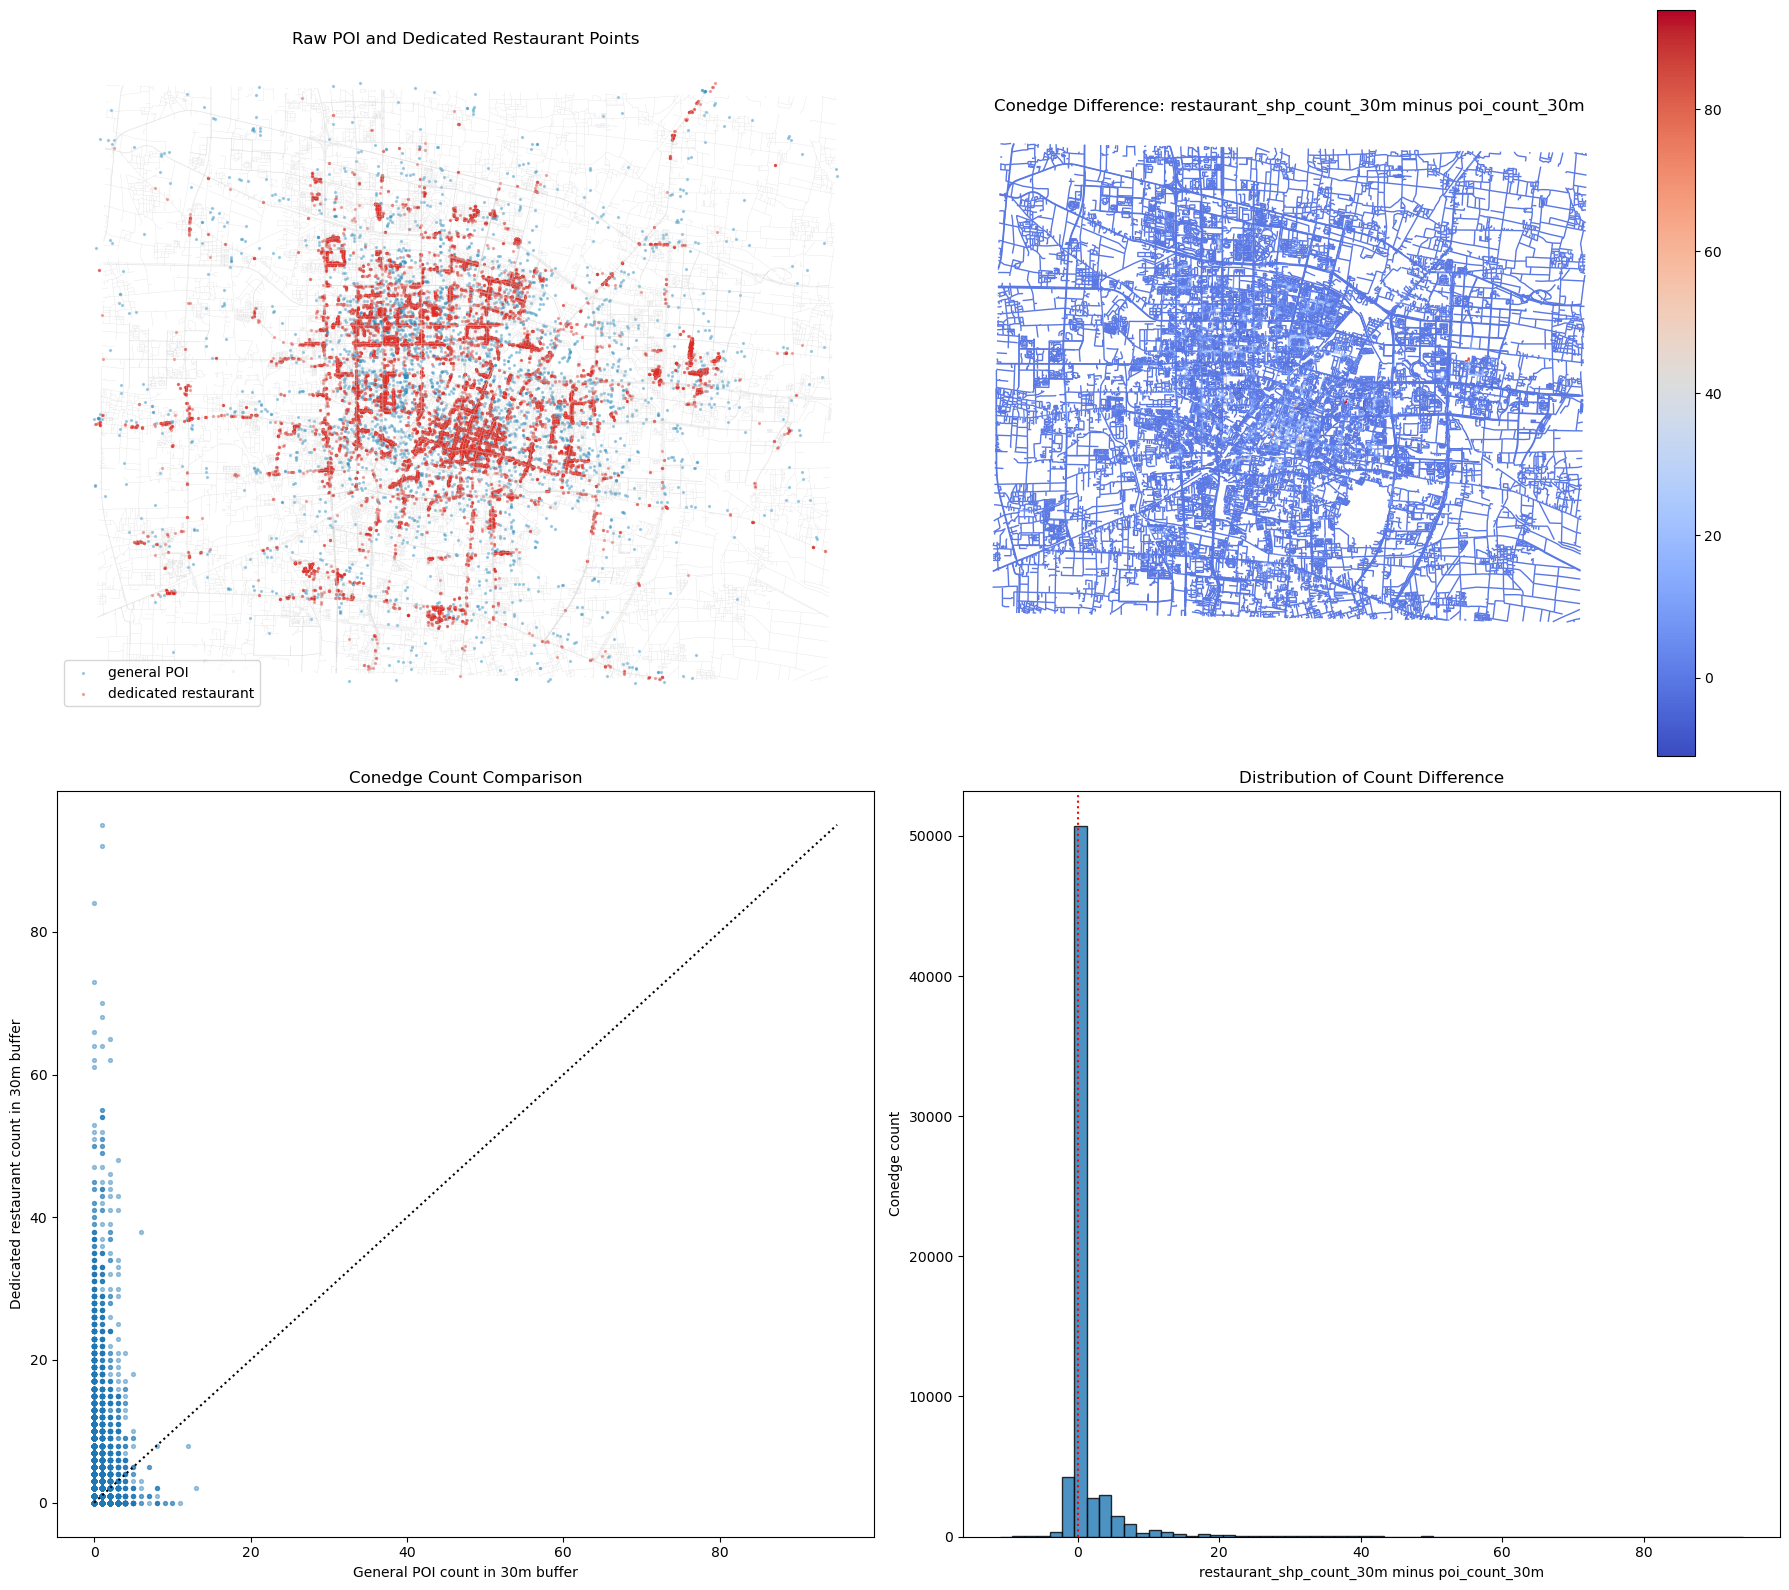

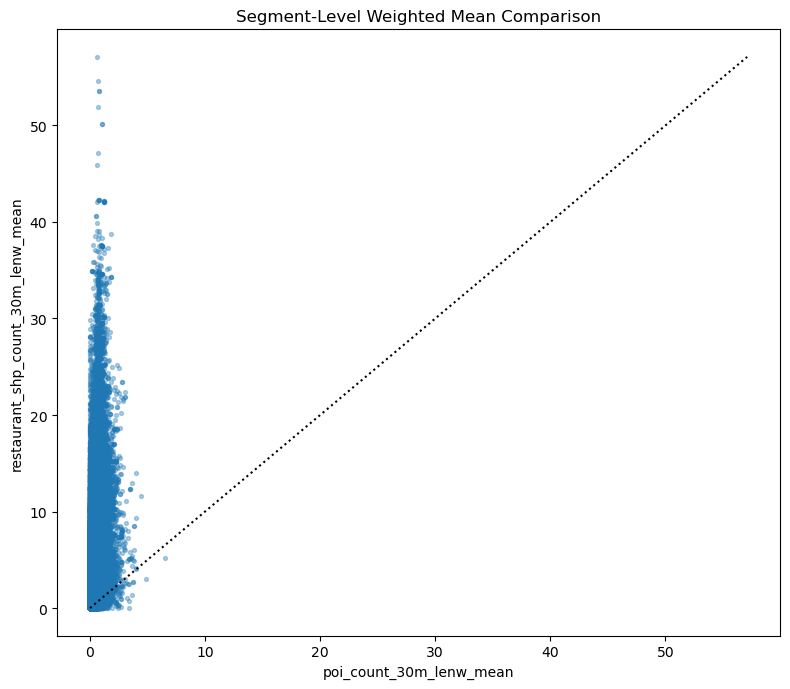

In [ ]:
# =========================================================
# POI and restaurant 30m buffer diagnostics
# Check why restaurant_shp_count_30m can exceed poi_count_30m
# Python 3.8 compatible
# =========================================================

import os
import re
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point, box


# =========================================================
# 0. Config
# =========================================================

RUN_POI_RESTAURANT_DIAGNOSTIC = True

POI_DIAG_BUFFER_M = LANDUSE_BUFFER_M if "LANDUSE_BUFFER_M" in globals() else 30
POI_DIAG_SAMPLE_POINTS = 20000
POI_DIAG_SAMPLE_SEGMENTS = 100000
POI_DIAG_RANDOM_SEED = 42

# If the map is too slow, set this to False.
DRAW_POI_DIAG_MAPS = True

# These are the key variables we want to compare.
CONEDGE_POI_TOTAL_COL = "poi_count_30m"
CONEDGE_POI_RESTAURANT_FROM_GENERAL_COL = "poi_count_restaurant_30m"
CONEDGE_RESTAURANT_SHP_COL = "restaurant_shp_count_30m"

SEG_POI_TOTAL_COL = "poi_count_30m_lenw_mean"
SEG_POI_RESTAURANT_FROM_GENERAL_COL = "poi_count_restaurant_30m_lenw_mean"
SEG_RESTAURANT_SHP_COL = "restaurant_shp_count_30m_lenw_mean"

RESTAURANT_KEYWORDS_FOR_DIAG = [
    "餐饮", "美食", "餐馆", "饭店", "中餐", "快餐", "小吃",
    "restaurant", "food", "dining", "catering",
]


# =========================================================
# 1. Small helpers
# =========================================================

def diag_display(x, n=20):
    try:
        display(x.head(n))
    except Exception:
        print(x.head(n).to_string())


def clean_text_diag(x):
    if pd.isna(x):
        return ""
    s = str(x).strip()
    if s in {"", "nan", "NaN", "None", "<NA>", "[]"}:
        return ""
    return s


def first_existing_diag(candidates, label, required=True):
    checked = []
    for p in candidates:
        if p is None:
            continue
        p = Path(p)
        checked.append(str(p))
        if p.exists():
            return p

    if required:
        raise FileNotFoundError(
            "Cannot find %s. Checked: %s" % (label, checked)
        )

    return None


def gpd_sjoin_compat(left, right, how="inner", predicate="intersects"):
    try:
        return gpd.sjoin(left, right, how=how, predicate=predicate)
    except TypeError:
        return gpd.sjoin(left, right, how=how, op=predicate)


def infer_xy_cols_for_csv(df):
    lon_candidates = [
        "lng", "lon", "longitude", "x",
        "bd_lng", "gcj_lng", "wgs_lng",
        "经度",
    ]
    lat_candidates = [
        "lat", "latitude", "y",
        "bd_lat", "gcj_lat", "wgs_lat",
        "纬度",
    ]

    cols_lower = {str(c).lower(): c for c in df.columns}

    lon_col = None
    lat_col = None

    for c in lon_candidates:
        if c.lower() in cols_lower:
            lon_col = cols_lower[c.lower()]
            break

    for c in lat_candidates:
        if c.lower() in cols_lower:
            lat_col = cols_lower[c.lower()]
            break

    return lon_col, lat_col


def load_point_table_diag(path, target_crs, label):
    """
    Load a point table from shp, gpkg, geojson, csv, or xlsx.
    The output is projected to target_crs.
    """

    if path is None or not Path(path).exists():
        print("%s input missing." % label)
        return gpd.GeoDataFrame({"geometry": []}, geometry="geometry", crs=target_crs)

    path = Path(path)
    print("\nLoading %s:" % label, path)

    if path.suffix.lower() in {".shp", ".gpkg", ".geojson"}:
        gdf = gpd.read_file(path)

    elif path.suffix.lower() in {".csv"}:
        df = pd.read_csv(path)
        lon_col, lat_col = infer_xy_cols_for_csv(df)
        if lon_col is None or lat_col is None:
            raise ValueError(
                "Cannot infer lon and lat columns for %s: %s"
                % (label, path)
            )

        df[lon_col] = pd.to_numeric(df[lon_col], errors="coerce")
        df[lat_col] = pd.to_numeric(df[lat_col], errors="coerce")
        df = df[df[lon_col].notna() & df[lat_col].notna()].copy()

        gdf = gpd.GeoDataFrame(
            df,
            geometry=[Point(xy) for xy in zip(df[lon_col], df[lat_col])],
            crs="EPSG:4326",
        )

    elif path.suffix.lower() in {".xlsx", ".xls"}:
        df = pd.read_excel(path)
        lon_col, lat_col = infer_xy_cols_for_csv(df)
        if lon_col is None or lat_col is None:
            raise ValueError(
                "Cannot infer lon and lat columns for %s: %s"
                % (label, path)
            )

        df[lon_col] = pd.to_numeric(df[lon_col], errors="coerce")
        df[lat_col] = pd.to_numeric(df[lat_col], errors="coerce")
        df = df[df[lon_col].notna() & df[lat_col].notna()].copy()

        gdf = gpd.GeoDataFrame(
            df,
            geometry=[Point(xy) for xy in zip(df[lon_col], df[lat_col])],
            crs="EPSG:4326",
        )

    else:
        raise ValueError("Unsupported input type for %s: %s" % (label, path))

    if gdf.crs is None:
        print("%s CRS missing, assume EPSG:4326." % label)
        gdf = gdf.set_crs(epsg=4326)

    gdf = gdf[gdf.geometry.notna()].copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()

    # Keep only point-like geometry. If polygons exist, use centroids for diagnosis.
    if len(gdf) > 0 and not gdf.geom_type.isin(["Point", "MultiPoint"]).all():
        print("%s contains non-point geometries, using centroids for diagnosis." % label)
        gdf = gdf.copy()
        gdf["geometry"] = gdf.geometry.centroid

    if gdf.crs != target_crs:
        gdf = gdf.to_crs(target_crs)

    gdf = gdf.reset_index(drop=True)
    print("%s rows loaded:" % label, f"{len(gdf):,}")
    print("%s CRS:" % label, gdf.crs)

    return gdf


def infer_poi_type_col_diag(gdf):
    if len(gdf) == 0:
        return None

    candidates = [
        "poi_major",
        "type",
        "category",
        "class",
        "kind",
        "fclass",
        "Name",
        "name",
        "大类",
        "中类",
        "小类",
        "类别",
        "类型",
        "行业",
    ]

    best_col = None
    best_score = -1

    print("\nPOI category column candidates:")
    for c in candidates:
        if c not in gdf.columns:
            continue

        vals = gdf[c].apply(clean_text_diag)
        nonempty_share = float((vals != "").mean())
        unique_n = int(vals[vals != ""].nunique())

        score = nonempty_share * 1000 - abs(unique_n - 30)

        print(
            "  %s: non-empty share %.3f, unique %d"
            % (c, nonempty_share, unique_n)
        )

        if nonempty_share > 0 and score > best_score:
            best_score = score
            best_col = c

    print("Selected POI type column:", best_col)
    return best_col


def extract_major_type_diag(x):
    s = clean_text_diag(x)
    if s == "":
        return "unknown"

    for sep in [";", ",", "/", "|", ">", "-"]:
        if sep in s:
            s = s.split(sep)[0].strip()
            break

    if s == "":
        return "unknown"

    return s


def match_restaurant_keywords_diag(series):
    pat = "|".join([re.escape(k) for k in RESTAURANT_KEYWORDS_FOR_DIAG])
    return series.fillna("").astype(str).str.contains(pat, case=False, regex=True)


def clip_points_to_conedge_bbox_diag(points, conedge_gdf, label):
    if points is None or len(points) == 0:
        return points

    minx, miny, maxx, maxy = conedge_gdf.total_bounds
    bbox_geom = box(
        minx - POI_DIAG_BUFFER_M - 50,
        miny - POI_DIAG_BUFFER_M - 50,
        maxx + POI_DIAG_BUFFER_M + 50,
        maxy + POI_DIAG_BUFFER_M + 50,
    )

    before = len(points)
    out = points[points.geometry.intersects(bbox_geom)].copy().reset_index(drop=True)

    print(
        "%s rows after conedge bbox clip: %s of %s, %.2f%%"
        % (label, f"{len(out):,}", f"{before:,}", len(out) / max(before, 1) * 100)
    )

    return out


def point_buffer_coverage_diag(points, buffer_gdf, label):
    """
    Count unique points that fall inside any 30m conedge buffer.
    Also count point-buffer hits because one point can fall in multiple buffers.
    """

    if points is None or len(points) == 0:
        return {
            "label": label,
            "point_count": 0,
            "unique_points_in_any_buffer": 0,
            "unique_point_share_in_any_buffer": np.nan,
            "point_buffer_hit_count": 0,
            "mean_hits_per_covered_point": np.nan,
        }, pd.DataFrame({"conedge_id": buffer_gdf["conedge_id"].values, label: 0})

    pts = points[["geometry"]].copy().reset_index(drop=True)
    pts["point_id"] = np.arange(len(pts), dtype=int)

    buf = buffer_gdf[["conedge_id", "geometry"]].copy()

    joined = gpd_sjoin_compat(
        pts,
        buf,
        how="inner",
        predicate="intersects",
    )

    if len(joined) == 0:
        per_conedge = pd.DataFrame({
            "conedge_id": buffer_gdf["conedge_id"].values,
            label: np.zeros(len(buffer_gdf), dtype=int),
        })
        return {
            "label": label,
            "point_count": len(pts),
            "unique_points_in_any_buffer": 0,
            "unique_point_share_in_any_buffer": 0.0,
            "point_buffer_hit_count": 0,
            "mean_hits_per_covered_point": np.nan,
        }, per_conedge

    unique_points = int(joined["point_id"].nunique())
    hit_count = int(len(joined))

    per_conedge = (
        joined.groupby("conedge_id")
        .size()
        .reset_index(name=label)
    )

    per_conedge = (
        pd.DataFrame({"conedge_id": buffer_gdf["conedge_id"].values})
        .merge(per_conedge, on="conedge_id", how="left")
    )
    per_conedge[label] = per_conedge[label].fillna(0).astype(int)

    return {
        "label": label,
        "point_count": len(pts),
        "unique_points_in_any_buffer": unique_points,
        "unique_point_share_in_any_buffer": unique_points / max(len(pts), 1),
        "point_buffer_hit_count": hit_count,
        "mean_hits_per_covered_point": hit_count / max(unique_points, 1),
    }, per_conedge


def get_conedge_geometry_diag():
    if "cache" in globals() and isinstance(cache, dict) and "gdf_con" in cache:
        print("Using cache['gdf_con'].")
        return cache["gdf_con"].copy()

    if "gdf_con" in globals():
        print("Using in-memory gdf_con.")
        return gdf_con.copy()

    candidates = []
    if "CONEDGE_GPKG" in globals():
        candidates.append(CONEDGE_GPKG)
    if "GRAPH_CORE_CACHE_PKL" in globals():
        candidates.append(GRAPH_CORE_CACHE_PKL)

    for p in candidates:
        p = Path(p)
        if p.exists() and p.suffix.lower() == ".gpkg":
            print("Reading conedge GPKG:", p)
            return gpd.read_file(p)

    for p in candidates:
        p = Path(p)
        if p.exists() and p.suffix.lower() == ".pkl":
            print("Reading graph cache:", p)
            with open(p, "rb") as f:
                obj = pickle.load(f)
            if isinstance(obj, dict) and "gdf_con" in obj:
                return obj["gdf_con"].copy()

    raise FileNotFoundError("Cannot find conedge geometry from cache, gdf_con, or CONEDGE_GPKG.")


def get_landuse_table_diag():
    if "land" in globals() and isinstance(land, pd.DataFrame):
        print("Using in-memory land.")
        return land.copy()

    candidates = []
    if "LANDUSE_CONEDGE_CSV" in globals():
        candidates.append(LANDUSE_CONEDGE_CSV)

    candidates.extend([
        Path("./outputs_pipeline_aligned/02_variables/landuse/conedge_landuse_30m.csv.gz"),
        Path("./outputs_pipeline_aligned/02_variables/landuse/conedge_landuse_30m.csv"),
    ])

    p = first_existing_diag(candidates, "conedge landuse table", required=True)
    print("Reading landuse table:", p)
    return pd.read_csv(p)


def get_segment_model_diag():
    if "segment_model" in globals() and isinstance(segment_model, pd.DataFrame):
        print("Using in-memory segment_model.")
        return segment_model.copy()

    candidates = []
    if "SEGMENT_MODEL_CSV_GZ" in globals():
        candidates.append(SEGMENT_MODEL_CSV_GZ)
    if "SEGMENT_MODEL_CSV" in globals():
        candidates.append(SEGMENT_MODEL_CSV)

    candidates.extend([
        Path("./outputs_pipeline_aligned/02_variables/segments/segment_model_table.csv.gz"),
        Path("./outputs_pipeline_aligned/02_variables/segments/segment_model_table.csv"),
    ])

    p = first_existing_diag(candidates, "segment model table", required=False)
    if p is None:
        print("Segment model table not found. Segment-level diagnosis will be skipped.")
        return None

    print("Reading segment model table:", p)
    return pd.read_csv(p)


def get_effective_input_diag(global_name, fallback_candidates, label):
    if global_name in globals() and globals()[global_name] is not None:
        p = Path(globals()[global_name])
        if p.exists():
            return p

    return first_existing_diag(fallback_candidates, label, required=False)


def describe_cols_diag(df, cols, label):
    existing = [c for c in cols if c in df.columns]
    print("\n" + "=" * 70)
    print(label)
    print("=" * 70)

    if len(existing) == 0:
        print("No requested columns found.")
        return

    out = df[existing].apply(pd.to_numeric, errors="coerce")
    desc = out.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T
    print(desc.round(4).to_string())

    if len(existing) >= 2:
        print("\nCorrelation:")
        print(out.corr().round(4).to_string())


# =========================================================
# 2. Main diagnostic
# =========================================================

if RUN_POI_RESTAURANT_DIAGNOSTIC:

    np.random.seed(POI_DIAG_RANDOM_SEED)

    print("\n" + "=" * 80)
    print("POI and restaurant 30m buffer diagnostics")
    print("=" * 80)
    print("Buffer radius:", POI_DIAG_BUFFER_M, "m")

    conedge_gdf = get_conedge_geometry_diag()
    landuse_df = get_landuse_table_diag()
    seg_df = get_segment_model_diag()

    if "conedge_id" not in conedge_gdf.columns:
        raise ValueError("conedge_gdf has no conedge_id.")

    conedge_gdf = conedge_gdf[["conedge_id", "geometry"]].copy()
    conedge_gdf["conedge_id"] = pd.to_numeric(conedge_gdf["conedge_id"], errors="coerce")
    conedge_gdf = conedge_gdf[conedge_gdf["conedge_id"].notna()].copy()
    conedge_gdf["conedge_id"] = conedge_gdf["conedge_id"].astype(int)

    target_crs = conedge_gdf.crs
    print("Conedge rows:", f"{len(conedge_gdf):,}")
    print("Conedge CRS:", target_crs)

    if target_crs is None:
        raise ValueError("Conedge CRS is missing. Cannot do reliable 30m buffer diagnosis.")

    # -----------------------------------------------------
    # 2.1 Load raw POI and restaurant point datasets
    # -----------------------------------------------------

    try:
        base_dir_diag = BASE_DIR
    except NameError:
        base_dir_diag = Path.cwd()

    poi_input_diag = get_effective_input_diag(
        "POI_INPUT",
        [
            base_dir_diag / "baoding" / "保定数据" / "POI_保定.shp",
            base_dir_diag / "dataset" / "baoding" / "保定数据" / "POI_保定.shp",
            base_dir_diag / "POI_保定.shp",
            Path("./baoding/保定数据/POI_保定.shp"),
            Path("./dataset/baoding/保定数据/POI_保定.shp"),
            Path("./POI_保定.shp"),
        ],
        "general POI input",
    )

    rest_input_diag = get_effective_input_diag(
        "REST_INPUT",
        [
            base_dir_diag / "baoding" / "保定数据" / "大众点评餐馆_保定.shp",
            base_dir_diag / "dataset" / "baoding" / "保定数据" / "大众点评餐馆_保定.shp",
            base_dir_diag / "大众点评餐馆_保定.shp",
            Path("./baoding/保定数据/大众点评餐馆_保定.shp"),
            Path("./dataset/baoding/保定数据/大众点评餐馆_保定.shp"),
            Path("./大众点评餐馆_保定.shp"),
        ],
        "restaurant input",
    )

    poi_raw = load_point_table_diag(poi_input_diag, target_crs, "general POI")
    rest_raw = load_point_table_diag(rest_input_diag, target_crs, "dedicated restaurant POI")

    poi = clip_points_to_conedge_bbox_diag(poi_raw, conedge_gdf, "general POI")
    rest = clip_points_to_conedge_bbox_diag(rest_raw, conedge_gdf, "dedicated restaurant POI")

    # -----------------------------------------------------
    # 2.2 Infer restaurant category inside the general POI table
    # -----------------------------------------------------

    if len(poi) > 0:
        poi_type_col = infer_poi_type_col_diag(poi)

        if poi_type_col is None:
            poi["poi_major_diag"] = "unknown"
            poi["is_restaurant_keyword_diag"] = False
        else:
            poi["poi_major_diag"] = poi[poi_type_col].apply(extract_major_type_diag)
            poi["is_restaurant_keyword_diag"] = match_restaurant_keywords_diag(
                poi[poi_type_col]
            )

        print("\nTop general POI categories:")
        print(poi["poi_major_diag"].value_counts(dropna=False).head(30).to_string())

        print(
            "\nGeneral POI rows matched by restaurant keywords: %s, %.2f%%"
            % (
                f"{int(poi['is_restaurant_keyword_diag'].sum()):,}",
                poi["is_restaurant_keyword_diag"].mean() * 100,
            )
        )
    else:
        poi_type_col = None
        poi["poi_major_diag"] = []
        poi["is_restaurant_keyword_diag"] = []

    poi_rest_from_general = poi[poi["is_restaurant_keyword_diag"].fillna(False)].copy()

    # -----------------------------------------------------
    # 2.3 Build 30m buffers and count raw points inside buffers
    # -----------------------------------------------------

    buffer_gdf = conedge_gdf.copy()
    buffer_gdf["geometry"] = buffer_gdf.geometry.buffer(POI_DIAG_BUFFER_M)

    poi_coverage, poi_count_recomputed = point_buffer_coverage_diag(
        poi,
        buffer_gdf,
        "poi_count_30m_recomputed",
    )
    poi_rest_coverage, poi_rest_count_recomputed = point_buffer_coverage_diag(
        poi_rest_from_general,
        buffer_gdf,
        "poi_count_restaurant_30m_recomputed",
    )
    rest_coverage, rest_count_recomputed = point_buffer_coverage_diag(
        rest,
        buffer_gdf,
        "restaurant_shp_count_30m_recomputed",
    )

    coverage_summary = pd.DataFrame([
        poi_coverage,
        poi_rest_coverage,
        rest_coverage,
    ])

    print("\n" + "=" * 70)
    print("Raw point coverage inside any 30m conedge buffer")
    print("=" * 70)
    diag_display(coverage_summary, n=10)

    # -----------------------------------------------------
    # 2.4 Compare existing conedge landuse features with recomputed counts
    # -----------------------------------------------------

    land_check = landuse_df.copy()
    land_check["conedge_id"] = pd.to_numeric(land_check["conedge_id"], errors="coerce")
    land_check = land_check[land_check["conedge_id"].notna()].copy()
    land_check["conedge_id"] = land_check["conedge_id"].astype(int)

    recomputed = (
        pd.DataFrame({"conedge_id": conedge_gdf["conedge_id"].values})
        .merge(poi_count_recomputed, on="conedge_id", how="left")
        .merge(poi_rest_count_recomputed, on="conedge_id", how="left")
        .merge(rest_count_recomputed, on="conedge_id", how="left")
    )

    for c in [
        "poi_count_30m_recomputed",
        "poi_count_restaurant_30m_recomputed",
        "restaurant_shp_count_30m_recomputed",
    ]:
        recomputed[c] = recomputed[c].fillna(0).astype(int)

    land_check = land_check.merge(recomputed, on="conedge_id", how="left")

    for c in [
        "poi_count_30m_recomputed",
        "poi_count_restaurant_30m_recomputed",
        "restaurant_shp_count_30m_recomputed",
    ]:
        land_check[c] = land_check[c].fillna(0).astype(int)

    for c in [
        CONEDGE_POI_TOTAL_COL,
        CONEDGE_POI_RESTAURANT_FROM_GENERAL_COL,
        CONEDGE_RESTAURANT_SHP_COL,
    ]:
        if c in land_check.columns:
            land_check[c] = pd.to_numeric(land_check[c], errors="coerce").fillna(0).astype(int)

    print("\n" + "=" * 70)
    print("Conedge-level existing vs recomputed count checks")
    print("=" * 70)

    conedge_cols_to_describe = [
        CONEDGE_POI_TOTAL_COL,
        CONEDGE_POI_RESTAURANT_FROM_GENERAL_COL,
        CONEDGE_RESTAURANT_SHP_COL,
        "poi_count_30m_recomputed",
        "poi_count_restaurant_30m_recomputed",
        "restaurant_shp_count_30m_recomputed",
    ]
    describe_cols_diag(land_check, conedge_cols_to_describe, "Conedge landuse counts")

    compare_pairs = [
        (CONEDGE_POI_TOTAL_COL, "poi_count_30m_recomputed"),
        (CONEDGE_POI_RESTAURANT_FROM_GENERAL_COL, "poi_count_restaurant_30m_recomputed"),
        (CONEDGE_RESTAURANT_SHP_COL, "restaurant_shp_count_30m_recomputed"),
    ]

    for old_col, new_col in compare_pairs:
        if old_col in land_check.columns and new_col in land_check.columns:
            diff = land_check[old_col] - land_check[new_col]
            print(
                "\n%s vs %s: exact match share %.2f%%, max abs diff %.0f"
                % (
                    old_col,
                    new_col,
                    (diff == 0).mean() * 100,
                    diff.abs().max(),
                )
            )

    if CONEDGE_POI_TOTAL_COL in land_check.columns and CONEDGE_RESTAURANT_SHP_COL in land_check.columns:
        land_check["restaurant_minus_total_poi"] = (
            land_check[CONEDGE_RESTAURANT_SHP_COL] - land_check[CONEDGE_POI_TOTAL_COL]
        )
        land_check["restaurant_gt_total_poi"] = land_check["restaurant_minus_total_poi"] > 0

        print("\nConedge rows where dedicated restaurant count exceeds general POI total:")
        print(
            "Count: %s of %s, %.2f%%"
            % (
                f"{int(land_check['restaurant_gt_total_poi'].sum()):,}",
                f"{len(land_check):,}",
                land_check["restaurant_gt_total_poi"].mean() * 100,
            )
        )

        print("\nTop conedges by restaurant_shp_count_30m minus poi_count_30m:")
        top_bad = land_check.sort_values("restaurant_minus_total_poi", ascending=False)
        show_cols = [
            "conedge_id",
            CONEDGE_POI_TOTAL_COL,
            CONEDGE_POI_RESTAURANT_FROM_GENERAL_COL,
            CONEDGE_RESTAURANT_SHP_COL,
            "restaurant_minus_total_poi",
            "poi_count_30m_recomputed",
            "poi_count_restaurant_30m_recomputed",
            "restaurant_shp_count_30m_recomputed",
        ]
        show_cols = [c for c in show_cols if c in top_bad.columns]
        diag_display(top_bad[show_cols], n=20)

    # -----------------------------------------------------
    # 2.5 Segment-level diagnosis
    # -----------------------------------------------------

    if seg_df is not None:
        print("\n" + "=" * 70)
        print("Segment-level landuse diagnosis")
        print("=" * 70)

        seg_cols_to_describe = [
            SEG_POI_TOTAL_COL,
            SEG_POI_RESTAURANT_FROM_GENERAL_COL,
            SEG_RESTAURANT_SHP_COL,
        ]
        describe_cols_diag(seg_df, seg_cols_to_describe, "Segment-level weighted mean counts")

        if SEG_POI_TOTAL_COL in seg_df.columns and SEG_RESTAURANT_SHP_COL in seg_df.columns:
            tmp_seg = seg_df.copy()

            if len(tmp_seg) > POI_DIAG_SAMPLE_SEGMENTS:
                tmp_seg = tmp_seg.sample(
                    POI_DIAG_SAMPLE_SEGMENTS,
                    random_state=POI_DIAG_RANDOM_SEED,
                )

            tmp_seg[SEG_POI_TOTAL_COL] = pd.to_numeric(
                tmp_seg[SEG_POI_TOTAL_COL],
                errors="coerce",
            )
            tmp_seg[SEG_RESTAURANT_SHP_COL] = pd.to_numeric(
                tmp_seg[SEG_RESTAURANT_SHP_COL],
                errors="coerce",
            )

            tmp_seg["restaurant_minus_total_poi_lenw_mean"] = (
                tmp_seg[SEG_RESTAURANT_SHP_COL] - tmp_seg[SEG_POI_TOTAL_COL]
            )
            tmp_seg["restaurant_gt_total_poi_lenw_mean"] = (
                tmp_seg["restaurant_minus_total_poi_lenw_mean"] > 0
            )

            print("\nSegment rows where restaurant_shp_count_30m_lenw_mean exceeds poi_count_30m_lenw_mean:")
            print(
                "Count: %s of %s, %.2f%%"
                % (
                    f"{int(tmp_seg['restaurant_gt_total_poi_lenw_mean'].sum()):,}",
                    f"{len(tmp_seg):,}",
                    tmp_seg["restaurant_gt_total_poi_lenw_mean"].mean() * 100,
                )
            )

            print("\nTop segments by restaurant minus total POI:")
            seg_show_cols = [
                "seg_id",
                "action_pair",
                "final_distance_m",
                "duration",
                "speed_kmh",
                SEG_POI_TOTAL_COL,
                SEG_POI_RESTAURANT_FROM_GENERAL_COL,
                SEG_RESTAURANT_SHP_COL,
                "restaurant_minus_total_poi_lenw_mean",
            ]
            seg_show_cols = [c for c in seg_show_cols if c in tmp_seg.columns]
            diag_display(
                tmp_seg
                .sort_values("restaurant_minus_total_poi_lenw_mean", ascending=False)
                [seg_show_cols],
                n=20,
            )

    # -----------------------------------------------------
    # 2.6 Interpretation helper
    # -----------------------------------------------------

    print("\n" + "=" * 70)
    print("Interpretation checks")
    print("=" * 70)

    print(
        "1. poi_count_30m comes from the general POI table. "
        "restaurant_shp_count_30m comes from the dedicated restaurant table."
    )
    print(
        "2. If the dedicated restaurant table has many more raw points than the general POI table, "
        "restaurant_shp_count_30m can exceed poi_count_30m."
    )
    print(
        "3. If recomputed counts match existing counts, the spatial join code is behaving consistently."
    )
    print(
        "4. If recomputed counts do not match existing counts, inspect CRS, duplicate points, and whether the notebook reused old landuse cache."
    )
    print(
        "5. For modeling, avoid interpreting restaurant_shp_count_30m as a subset of poi_count_30m unless both are built from the same POI source."
    )

    # -----------------------------------------------------
    # 2.7 Maps and plots
    # -----------------------------------------------------

    if DRAW_POI_DIAG_MAPS:

        print("\nDrawing POI diagnostic plots...")

        plot_con = conedge_gdf.merge(
            land_check,
            on="conedge_id",
            how="left",
        )

        if "restaurant_minus_total_poi" not in plot_con.columns:
            if CONEDGE_POI_TOTAL_COL in plot_con.columns and CONEDGE_RESTAURANT_SHP_COL in plot_con.columns:
                plot_con["restaurant_minus_total_poi"] = (
                    pd.to_numeric(plot_con[CONEDGE_RESTAURANT_SHP_COL], errors="coerce").fillna(0)
                    - pd.to_numeric(plot_con[CONEDGE_POI_TOTAL_COL], errors="coerce").fillna(0)
                )
            else:
                plot_con["restaurant_minus_total_poi"] = 0

        plot_poi = poi.copy()
        plot_rest = rest.copy()

        if len(plot_poi) > POI_DIAG_SAMPLE_POINTS:
            plot_poi = plot_poi.sample(
                POI_DIAG_SAMPLE_POINTS,
                random_state=POI_DIAG_RANDOM_SEED,
            )
        if len(plot_rest) > POI_DIAG_SAMPLE_POINTS:
            plot_rest = plot_rest.sample(
                POI_DIAG_SAMPLE_POINTS,
                random_state=POI_DIAG_RANDOM_SEED,
            )

        fig, axes = plt.subplots(2, 2, figsize=(18, 16))

        # Map 1. Raw point locations over conedges.
        ax = axes[0, 0]
        conedge_gdf.plot(ax=ax, color="#cccccc", linewidth=0.25, alpha=0.6)
        if len(plot_poi) > 0:
            plot_poi.plot(ax=ax, color="#2b8cbe", markersize=2, alpha=0.35, label="general POI")
        if len(plot_rest) > 0:
            plot_rest.plot(ax=ax, color="#de2d26", markersize=2, alpha=0.35, label="dedicated restaurant")
        ax.set_title("Raw POI and Dedicated Restaurant Points")
        ax.axis("off")
        ax.legend(loc="lower left")

        # Map 2. Conedge difference.
        ax = axes[0, 1]
        plot_con.plot(
            ax=ax,
            column="restaurant_minus_total_poi",
            cmap="coolwarm",
            linewidth=1.0,
            legend=True,
        )
        ax.set_title("Conedge Difference: restaurant_shp_count_30m minus poi_count_30m")
        ax.axis("off")

        # Plot 3. Conedge scatter.
        ax = axes[1, 0]
        if CONEDGE_POI_TOTAL_COL in land_check.columns and CONEDGE_RESTAURANT_SHP_COL in land_check.columns:
            ax.scatter(
                land_check[CONEDGE_POI_TOTAL_COL],
                land_check[CONEDGE_RESTAURANT_SHP_COL],
                s=8,
                alpha=0.4,
            )
            max_val = max(
                pd.to_numeric(land_check[CONEDGE_POI_TOTAL_COL], errors="coerce").max(),
                pd.to_numeric(land_check[CONEDGE_RESTAURANT_SHP_COL], errors="coerce").max(),
            )
            if np.isfinite(max_val):
                ax.plot([0, max_val], [0, max_val], linestyle=":", color="black")
            ax.set_xlabel("General POI count in 30m buffer")
            ax.set_ylabel("Dedicated restaurant count in 30m buffer")
            ax.set_title("Conedge Count Comparison")
        else:
            ax.text(0.1, 0.5, "Missing conedge count columns")
            ax.axis("off")

        # Plot 4. Distribution of difference.
        ax = axes[1, 1]
        if "restaurant_minus_total_poi" in land_check.columns:
            x = land_check["restaurant_minus_total_poi"].replace([np.inf, -np.inf], np.nan).dropna()
            ax.hist(x, bins=60, edgecolor="black", alpha=0.8)
            ax.axvline(0, color="red", linestyle=":")
            ax.set_xlabel("restaurant_shp_count_30m minus poi_count_30m")
            ax.set_ylabel("Conedge count")
            ax.set_title("Distribution of Count Difference")
        else:
            ax.text(0.1, 0.5, "No difference column")
            ax.axis("off")

        plt.tight_layout()
        plt.show()

        # Optional segment-level scatter.
        if seg_df is not None and SEG_POI_TOTAL_COL in seg_df.columns and SEG_RESTAURANT_SHP_COL in seg_df.columns:
            plot_seg = seg_df[[SEG_POI_TOTAL_COL, SEG_RESTAURANT_SHP_COL]].copy()
            plot_seg[SEG_POI_TOTAL_COL] = pd.to_numeric(plot_seg[SEG_POI_TOTAL_COL], errors="coerce")
            plot_seg[SEG_RESTAURANT_SHP_COL] = pd.to_numeric(plot_seg[SEG_RESTAURANT_SHP_COL], errors="coerce")
            plot_seg = plot_seg.dropna()

            if len(plot_seg) > POI_DIAG_SAMPLE_SEGMENTS:
                plot_seg = plot_seg.sample(
                    POI_DIAG_SAMPLE_SEGMENTS,
                    random_state=POI_DIAG_RANDOM_SEED,
                )

            fig, ax = plt.subplots(figsize=(8, 7))
            ax.scatter(
                plot_seg[SEG_POI_TOTAL_COL],
                plot_seg[SEG_RESTAURANT_SHP_COL],
                s=8,
                alpha=0.35,
            )
            max_val = max(
                plot_seg[SEG_POI_TOTAL_COL].max(),
                plot_seg[SEG_RESTAURANT_SHP_COL].max(),
            )
            if np.isfinite(max_val):
                ax.plot([0, max_val], [0, max_val], linestyle=":", color="black")

            ax.set_xlabel(SEG_POI_TOTAL_COL)
            ax.set_ylabel(SEG_RESTAURANT_SHP_COL)
            ax.set_title("Segment-Level Weighted Mean Comparison")
            plt.tight_layout()
            plt.show()